# Box Office Movie Prediction Model Based on TMDb Millions of Movies Dataset

By: Tran Duy Khang - 22120153
    

## Introduction

The film industry has gained immense popularity in recent times and continues to grow every year. With the release of major blockbuster hits that earn hundreds of millions of dollars, and occasionally even over a billion, it is evident that some movies are more successful than others. However, alongside successful movies, there are also those that fail miserably at the box office. This project aims to analyze the factors that contribute to the success or failure of movies based on their worldwide box office revenue. By studying the data on these movies, the objective is to predict the revenue of future movies. Knowing the significant factors that contribute to success is valuable information for players in the industry.

## References

The dataset on Kaggle by Akshay Pawar is linked below, alongside valuable resources that provided direction and motivation for this project on multiple occasions.

https://www.kaggle.com/datasets/akshaypawar7/millions-of-movies

Praxitelisk's GitHub Repo was also used as guidance and inspiration for our work, which was based on a dataset that was more contained and had different values and columns. The dataset originated from a Kaggle Competition that has now concluded.

https://github.com/praxitelisk/TMDB-Box-Office-Prediction

## Import Libraries

In [ ]:
!pip install catboost xgboost lightgbm shap seaborn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import re
from datetime import datetime
from IPython.display import display
from collections import defaultdict

from sklearn.model_selection import train_test_split

from scipy.stats import pearsonr
import math
from statistics import median
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error, accuracy_score
import shap

import pickle
%matplotlib inline

## Loading Data

In [ ]:
import os

# Load all CSV files from the raw_data folder
raw_data_folder = "data/raw_data"
all_files = [os.path.join(raw_data_folder, f) for f in os.listdir(raw_data_folder) if f.endswith('.csv')]

# Combine all CSV files into a single DataFrame
df_list = [pd.read_csv(file) for file in all_files]
df = pd.concat(df_list, ignore_index=True)

df.head()

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,3.520565e+08,116.0,Released,Back for seconds.,7.079,1365.0,Jason Statham-Wu Jing-Shuya Sophia Cai-Sergio ...,based on novel or book-sequel-kaiju,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,/qlxy8yo5bcgUw2KAmmojUKp4rHd.jpg,1006462-298618-569094-1061181-346698-1076487-6...
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,6.567582e+07,103.0,Released,Inspired by the actual files of Father Gabriel...,7.433,545.0,Russell Crowe-Daniel Zovatto-Alex Essoe-Franco...,spain-rome italy-vatican-pope-pig-possession-c...,/9JBEPLTPSm0d1mbEcLxULjJq9Eh.jpg,/hiHGRbyTcbZoLsYYkO4QiCLYe34.jpg,713704-296271-502356-1076605-1084225-1008005-9...
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,Marvel Studios-Maximum Effort-21 Laps Entertai...,2024-07-24,200000000.0,1.326387e+09,128.0,Released,Come together.,7.765,3749.0,Ryan Reynolds-Hugh Jackman-Emma Corrin-Matthew...,hero-superhero-anti hero-mutant-breaking the f...,/8cdWjvZQUExUUTzyp4t6EDMubfO.jpg,/dvBCdCohwWbsP5qAaglOXagDMtk.jpg,573435-519182-957452-1022789-945961-718821-103...
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,4.070455e+08,127.0,Released,Unite or fall.,7.340,1007.0,Anthony Ramos-Dominique Fishback-Luna Lauren V...,peru-alien-end of the world-based on cartoon-b...,/gPbM0MK8CP8A174rmUwGsADNYKD.jpg,/woJbg7ZqidhpvqFGGMRhWQNoxwa.jpg,496450-569094-298618-385687-877100-598331-4628...
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,Legendary Pictures,2024-02-27,190000000.0,6.838137e+08,167.0,Released,Long live the fighters.,8.300,2770.0,Timothée Chalamet-Zendaya-Rebecca Ferguson-Jav...,epic-based on novel or book-fight-sandstorm-sa...,/czembW0Rk1Ke7lCJGahbOhdCuhV.jpg,/xOMo8BRK7PfcJv9JCnx7s5hj0PX.jpg,438631-763215-792307-1011985-467244-634492-359...


In [ ]:
# df = pd.read_csv("movies.csv")
# df.head()

## Data Understanding, Removing Outliers & Unreleased Movies

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722317 entries, 0 to 722316
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    722317 non-null  int64  
 1   title                 722311 non-null  object 
 2   genres                512000 non-null  object 
 3   original_language     722317 non-null  object 
 4   overview              604074 non-null  object 
 5   popularity            722317 non-null  float64
 6   production_companies  337391 non-null  object 
 7   release_date          670768 non-null  object 
 8   budget                722317 non-null  float64
 9   revenue               722317 non-null  float64
 10  runtime               687982 non-null  float64
 11  status                722317 non-null  object 
 12  tagline               108476 non-null  object 
 13  vote_average          722317 non-null  float64
 14  vote_count            722317 non-null  float64
 15  

In [ ]:
df.shape

(722317, 20)

In [ ]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_average,vote_count
count,722317.000000,722317.000000,7.223170e+05,7.223170e+05,6.879820e+05,722317.000000,722317.000000
mean,526920.121246,1.918179,4.043453e+05,1.007747e+06,1.990905e+02,2.446389,28.484715
std,253200.153542,23.692240,8.242868e+06,2.048321e+07,8.584257e+04,3.176491,396.575042
min,2.000000,0.000000,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000,0.000000
25%,328914.000000,0.600000,0.000000e+00,0.000000e+00,5.000000e+00,0.000000,0.000000
50%,533351.000000,0.600000,0.000000e+00,0.000000e+00,5.000000e+01,0.000000,0.000000
75%,737872.000000,1.303000,0.000000e+00,0.000000e+00,9.000000e+01,5.600000,2.000000
max,968161.000000,8763.998000,5.000000e+09,2.920357e+09,5.050505e+07,10.000000,34857.000000


By using the describe function, we obtain a comprehensive overview of the data. The output includes statistics such as count, mean, standard deviation, minimum and maximum values, as well as quartiles. These descriptive statistics help us understand the distribution, central tendency, and variability of the data, enabling us to gain insights into the movies' popularity, financial aspects (budget and revenue), duration (runtime), and audience ratings (vote average and count).

The dataset contains outliers where the budget and revenue values are recorded as 0 until around the 50th percentile, as well as instances where the runtime is recorded as 0. To prevent these outliers from affecting data analysis and modeling, it might be better to remove them later, as they likely represent errors or missing information. This will result in a cleaner dataset, leading to more accurate and reliable statistical analysis and decision-making.

<Axes: >

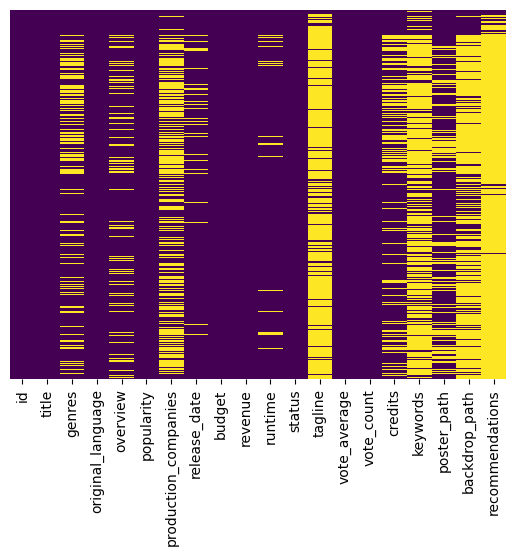

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [ ]:
def nans(df): return df[df.isnull().any(axis=1)]
nans(df)

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,runtime,status,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations
13,956101,The Eighth Clause,Thriller,la,Kat and Borja appear to be a perfect couple bu...,2259.303,SDB Films-El Hombre Orquesta,2022-04-29,0.0,0.0,0.0,Released,NaN,4.600,10.0,Maite Perroni-Manuel Vega-Óscar Jaenada-Jessic...,NaN,/8tc8eMFAX2SDC1TRu987qFQy8Cl.jpg,/kLnqNE9Af5QHyvUxw8cDGhF1ilv.jpg,NaN
14,572802,Aquaman and the Lost Kingdom,Action-Adventure-Fantasy,en,Black Manta still driven by the need to avenge...,2141.691,Warner Bros. Pictures-The Safran Company-Atomi...,2023-12-20,205000000.0,397860076.0,124.0,Released,The tide is turning.,6.786,756.0,Patrick Wilson-Yahya Abdul-Mateen II-Randall P...,superhero-secret society-half-brother-sequel-r...,/7lTnXOy0iNtBAdRP3TZvaKJ77F6.jpg,/jXJxMcVoEuXzym3vFnjqDW4ifo6.jpg,NaN
18,753342,Napoleon,History-War-Drama,en,An epic that details the checkered rise and fa...,1811.360,Scott Free Productions-Latina Pictures-Apple S...,2023-11-22,165000000.0,213400000.0,158.0,Released,He came from nothing. He conquered everything.,6.516,1282.0,Joaquin Phoenix-Vanessa Kirby-Rupert Everett-M...,empire-france-biography-napoleon bonaparte-bas...,/jE5o7y9K6pZtWNNMEw3IdpHuncR.jpg,/f1AQhx6ZfGhPZFTVKgxG91PhEYc.jpg,NaN
21,968051,The Nun II,Horror-Mystery-Thriller,en,In 1956 France a priest is violently murdered ...,1696.620,New Line Cinema-Atomic Monster-The Safran Company,2023-09-06,38500000.0,257010000.0,110.0,Released,Confess your sins.,7.004,1073.0,Taissa Farmiga-Jonas Bloquet-Storm Reid-Anna P...,france-bullying-sequel-religion-demon-gothic h...,/5gzzkR7y3hnY8AD1wXjCnVlHba5.jpg,/53z2fXEKfnNg2uSOPss2unPBGX1.jpg,NaN
22,965839,Lord of the Streets,Action,en,When Jason Dyson refuses to make his prized fi...,1691.825,Mutiny Films,2022-04-22,1000000.0,0.0,85.0,Released,NaN,4.900,29.0,Treach-Quinton Jackson-Khalil Rountree Jr.-And...,NaN,/n9YWVQRc0zw0nwrFcOkOpffZxjc.jpg,/g8Yytnby0hIPft5l56mgJtZyR1k.jpg,982467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722312,486848,The Orphans,NaN,zu,A moving tale involving two orphans a widower ...,0.600,NaN,1987-06-02,0.0,0.0,70.0,Released,NaN,0.000,0.0,Sizwe Dlamini-Innocent Gumede-Gugu Mhlanga,NaN,/6RQXu75sREj6qPlQuSawEnmZEcY.jpg,NaN,NaN
722313,495286,Das Cello,Drama,de,NaN,0.600,NaN,1966-04-25,0.0,0.0,NaN,Released,NaN,0.000,0.0,Nora Minor-Christian Doermer-Luitgard Im-Helga...,NaN,NaN,NaN,NaN
722314,657885,Esperança,War-Drama-History,pt,After being separated from his unit during the...,0.600,NaN,2014-09-07,0.0,0.0,20.0,Released,NaN,0.000,0.0,NaN,NaN,/bqoj1VQa0rpxQHdBMu9NYTrdSU4.jpg,NaN,NaN
722315,513496,HEAD SPACE,Comedy-Crime,en,Walt doesn't want to be a superhero. Although ...,0.600,SWTF,2018-03-23,0.0,0.0,7.0,Released,An apathetic man struggles with using his mind...,0.000,0.0,Nick Garza-Brad Weber-Jacky Li-Sarah Johnson-K...,head space,/vy4BO7BJsAin1dYptMWkJjD1xXo.jpg,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722317 entries, 0 to 722316
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    722317 non-null  int64  
 1   title                 722311 non-null  object 
 2   genres                512000 non-null  object 
 3   original_language     722317 non-null  object 
 4   overview              604074 non-null  object 
 5   popularity            722317 non-null  float64
 6   production_companies  337391 non-null  object 
 7   release_date          670768 non-null  object 
 8   budget                722317 non-null  float64
 9   revenue               722317 non-null  float64
 10  runtime               687982 non-null  float64
 11  status                722317 non-null  object 
 12  tagline               108476 non-null  object 
 13  vote_average          722317 non-null  float64
 14  vote_count            722317 non-null  float64
 15  

In [ ]:
print ('The data has {} rows and {} columns'.format(df.shape[0],df.shape[1]))

The data has 722317 rows and 20 columns


Given the extensive size of the dataset, it becomes imperative to implement techniques that can reduce the data size or limit the information being processed. This reduction in data will help alleviate the burden on the RAM, which has a finite capacity for storing and manipulating data.

In order to eliminate duplicate rows in a dataframe, the entries with identical IDs will be discarded, retaining only the first occurrence. This process ensures that the resulting dataframe contains unique records based on their IDs. By removing duplicates and preserving the original order, we maintain the integrity of the dataset.

In [ ]:
df = df.drop_duplicates(subset='id', keep='first')
print ('Currently, the data has {} rows and {} columns'.format(df.shape[0],df.shape[1]))

Currently, the data has 662083 rows and 20 columns


We will also remove all movies that have not been released yet from our dataset. This is because the target variable we are interested in predicting, which is the revenue, cannot be known for movies that have not yet hit the theaters or been made available to the public. Therefore, including unreleased movies would introduce bias and potentially skew our analysis and predictions.

In [ ]:
df = df[df['status'] == 'Released']
print ('Currently, the data has {} rows and {} columns'.format(df.shape[0],df.shape[1]))

Currently, the data has 657261 rows and 20 columns


As we have already excluded unreleased movies from our dataset, the 'status' column does not offer any valuable variation or insights for our analysis. Since the 'status' column only contains a single potential value, namely 'released', removing it will streamline our dataset and remove extraneous data that does not contribute to our predictive modeling.

In [ ]:
df = df.drop('status', axis=1)

We will also remove the movies which have no release date.

In [ ]:
df.dropna(subset=['release_date'], inplace=True)

In [ ]:
df = df[df['release_date'].notna()]

In [ ]:
df['release_date'].isna().sum()

0

The decision was made to condense the dataset by only including movies with a release date of at least the 2000s. This choice was driven by the need to focus on a more contemporary and relevant collection of films, excluding older titles that may have less relevance to current audiences. By limiting the dataset to movies released from the 2000s onwards, a more streamlined and targeted dataset can be obtained, facilitating analysis and research specific to the modern era of cinema.

In [ ]:
df = df[df['release_date'] >= '1900']
print ('Currently, the data has {} rows and {} columns'.format(df.shape[0],df.shape[1]))

Currently, the data has 609954 rows and 19 columns


In [ ]:
df = df[df.revenue > 0]
print ('Currently, the data has {} rows and {} columns'.format(df.shape[0],df.shape[1]))

Currently, the data has 16033 rows and 19 columns


In [ ]:
print("Dataset missing values:\n", df.isna().sum())

Dataset missing values:
 id                         0
title                      0
genres                   262
original_language          0
overview                 472
popularity                 0
production_companies    1256
release_date               0
budget                     0
revenue                    0
runtime                   50
tagline                 5009
vote_average               0
vote_count                 0
credits                  245
keywords                2764
poster_path              368
backdrop_path           1858
recommendations         6161
dtype: int64


## Exploratory Data Analysis and Feature Engineering

In [ ]:
df_features = []
log_features = []
cols_to_drop = []

To facilitate the analysis process, we begin by creating three separate lists. The first list contains the features that we intend to utilize, the second list comprises the features that we plan to log transform, while the third list consists of columns that we will exclude completely. As we analyze each variable, we will add relevant columns to these lists, which will enable us to select the appropriate columns more efficiently for modeling purposes.

### Revenue

To begin our analysis, we will focus on the revenue variable which serves as the target variable for our label. This column provides information on the worldwide box office earnings of the film.

#### Univariate Analysis

In [ ]:
print('Movies missing revenue:',df.revenue.isna().sum())

Movies missing revenue: 0


In [ ]:
print("Mean revenue: %.2f" % df.revenue.mean())
print("Median revenue: %.2f" % df.revenue.median())

Mean revenue: 44782428.95
Median revenue: 4500000.00


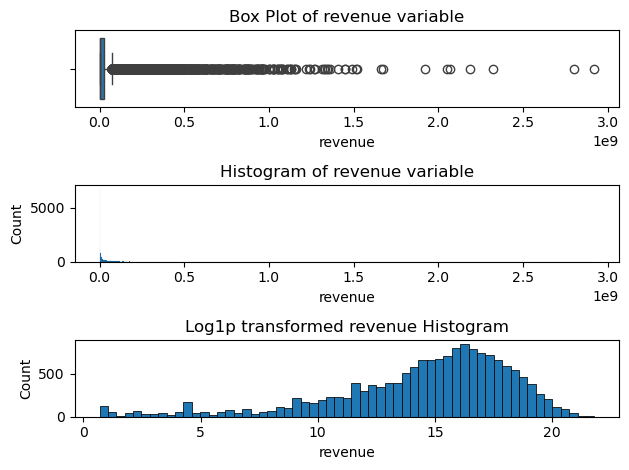

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.revenue, ax = ax[0])
ax[0].set_title("Box Plot of revenue variable")

sns.histplot(data=df, x='revenue', kde = False, ax = ax[1], alpha=1)
ax[1].set_title("Histogram of revenue variable")

log_revenue = np.log1p(df.revenue[df.revenue > 0])
sns.histplot(data=log_revenue, kde = False, ax = ax[2], alpha=1)
ax[2].set_title("Log1p transformed revenue Histogram")

f.tight_layout()
plt.show()

The revenue distribution is heavily skewed to the right due to the presence of major box office hits that make hundreds of millions of dollars, while the average movie earns only a few million dollars. To manage this skewness, the log transformation seems to be appropriate for the revenue column.

In [ ]:
df.revenue.nsmallest(20)

12387     1.0
13235     1.0
14065     1.0
28452     1.0
36909     1.0
41745     1.0
50403     1.0
51879     1.0
52386     1.0
56578     1.0
60776     1.0
66923     1.0
78538     1.0
84471     1.0
109118    1.0
110299    1.0
110581    1.0
111527    1.0
112664    1.0
113843    1.0
Name: revenue, dtype: float64

The revenue column exhibits a considerable amount of highly improbable and unrealistically low values. To simplify the analysis process, we will exclude the movie with a negative revenue, as it is an unusual outlier that would generate an invalid result when conducting bivariate analysis with log transformation. Apart from this, we may address the remaining outliers at a later stage, once we have thoroughly reviewed the remaining data.

In [ ]:
df.revenue.nsmallest(20)

12387     1.0
13235     1.0
14065     1.0
28452     1.0
36909     1.0
41745     1.0
50403     1.0
51879     1.0
52386     1.0
56578     1.0
60776     1.0
66923     1.0
78538     1.0
84471     1.0
109118    1.0
110299    1.0
110581    1.0
111527    1.0
112664    1.0
113843    1.0
Name: revenue, dtype: float64

In [ ]:
log_features.append("revenue")

### Title

The column has the movie title, and while it might be useful to study if certain words in the title relate to revenue, for this project, we will only look at the title's length. We want to see if shorter titles are easier to remember and draw more audiences, or if longer titles are more unique and attractive, leading to better performance.

#### Univariate Analysis

In [ ]:
print('Movies missing a title:',df.title.isna().sum())

Movies missing a title: 0


In [ ]:
df.title = df.title.fillna('')
print('Movies missing a title:',df.title.isna().sum())

Movies missing a title: 0


In [ ]:
df['title_length'] = df.title.apply(lambda x: len(str(x)))

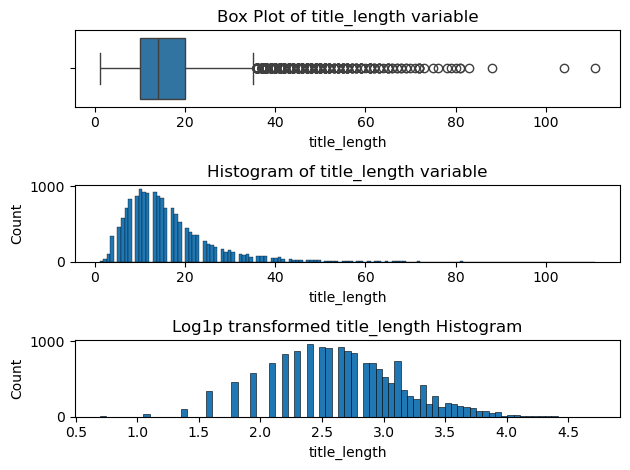

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.title_length, ax=ax[0])
ax[0].set_title("Box Plot of title_length variable")

sns.histplot(x=df.title_length, kde=False, ax=ax[1], alpha=1)
ax[1].set_title("Histogram of title_length variable")

sns.histplot(x=np.log1p(df.title_length), kde=False, ax=ax[2], alpha=1)
ax[2].set_title("Log1p transformed title_length Histogram")

f.tight_layout()

#### Bivariate Analysis

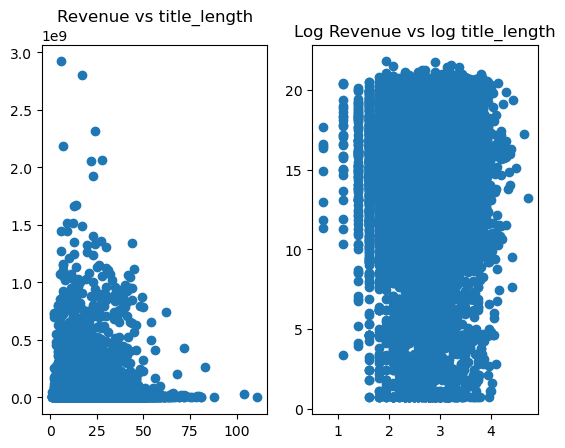

In [ ]:
plt.figure()
plt.subplot(1, 2, 1)
plt.scatter(df['title_length'], df['revenue'])
plt.title('Revenue vs title_length');
plt.subplot(1, 2, 2)
plt.scatter(np.log1p(df['title_length']), np.log1p(df['revenue']))
plt.title('Log Revenue vs log title_length');

In [ ]:
corr, _ = pearsonr(df['title_length'], df['revenue'])
print('Pearsons correlation between title_length and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['title_length']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed title_length and log transformed revenue: %.3f' % corr)

Pearsons correlation between title_length and revenue: 0.047
Pearsons correlation between log transformed title_length and log transformed revenue: -0.015


Even though it is minimal, there is still a correlation between the movie's revenue and the length of its title.

In [ ]:
log_features.append('title_length')

### Genres

In [ ]:
df['genres'].head()

0       Action-Science Fiction-Horror
1             Horror-Mystery-Thriller
2       Action-Comedy-Science Fiction
3    Action-Adventure-Science Fiction
4           Science Fiction-Adventure
Name: genres, dtype: object

In [ ]:
print("Movies misssing genres: ",df['genres'].isna().sum())

Movies misssing genres:  262


#### Pre-processing

In [ ]:
df['genres'] = df['genres'].fillna('N/A')
df['genres_processed'] = df['genres'].apply(lambda x: x.split("-"))

We will create a new dataframe by separating all genres for each film, to facilitate further data exploration.

In [ ]:
df.head(10)

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,...,tagline,vote_average,vote_count,credits,keywords,poster_path,backdrop_path,recommendations,title_length,genres_processed
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,3.520565e+08,...,Back for seconds.,7.079,1365.0,Jason Statham-Wu Jing-Shuya Sophia Cai-Sergio ...,based on novel or book-sequel-kaiju,/4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg,/qlxy8yo5bcgUw2KAmmojUKp4rHd.jpg,1006462-298618-569094-1061181-346698-1076487-6...,17,"[Action, Science Fiction, Horror]"
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,6.567582e+07,...,Inspired by the actual files of Father Gabriel...,7.433,545.0,Russell Crowe-Daniel Zovatto-Alex Essoe-Franco...,spain-rome italy-vatican-pope-pig-possession-c...,/9JBEPLTPSm0d1mbEcLxULjJq9Eh.jpg,/hiHGRbyTcbZoLsYYkO4QiCLYe34.jpg,713704-296271-502356-1076605-1084225-1008005-9...,19,"[Horror, Mystery, Thriller]"
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,Marvel Studios-Maximum Effort-21 Laps Entertai...,2024-07-24,200000000.0,1.326387e+09,...,Come together.,7.765,3749.0,Ryan Reynolds-Hugh Jackman-Emma Corrin-Matthew...,hero-superhero-anti hero-mutant-breaking the f...,/8cdWjvZQUExUUTzyp4t6EDMubfO.jpg,/dvBCdCohwWbsP5qAaglOXagDMtk.jpg,573435-519182-957452-1022789-945961-718821-103...,20,"[Action, Comedy, Science Fiction]"
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,4.070455e+08,...,Unite or fall.,7.340,1007.0,Anthony Ramos-Dominique Fishback-Luna Lauren V...,peru-alien-end of the world-based on cartoon-b...,/gPbM0MK8CP8A174rmUwGsADNYKD.jpg,/woJbg7ZqidhpvqFGGMRhWQNoxwa.jpg,496450-569094-298618-385687-877100-598331-4628...,32,"[Action, Adventure, Science Fiction]"
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,Legendary Pictures,2024-02-27,190000000.0,6.838137e+08,...,Long live the fighters.,8.300,2770.0,Timothée Chalamet-Zendaya-Rebecca Ferguson-Jav...,epic-based on novel or book-fight-sandstorm-sa...,/czembW0Rk1Ke7lCJGahbOhdCuhV.jpg,/xOMo8BRK7PfcJv9JCnx7s5hj0PX.jpg,438631-763215-792307-1011985-467244-634492-359...,14,"[Science Fiction, Adventure]"
5,912649,Venom: The Last Dance,Science Fiction-Action-Adventure,en,Eddie and Venom are on the run. Hunted by both...,4674.885,Columbia Pictures-Pascal Pictures-Matt Tolmach...,2024-10-22,120000000.0,3.100000e+08,...,'Til death do they part.,6.522,603.0,Tom Hardy-Chiwetel Ejiofor-Juno Temple-Clark B...,hero-superhero-anti hero-villain-alien life-fo...,/aosm8NMQ3UyoBVpSxyimorCQykC.jpg,/3V4kLQg0kSqPLctI5ziYWabAZYF.jpg,1236419-1141182-1034541-1184918-933260-976734-...,21,"[Science Fiction, Action, Adventure]"
6,640146,Ant-Man and the Wasp: Quantumania,Action-Adventure-Science Fiction,en,Super-Hero partners Scott Lang and Hope van Dy...,4425.387,Marvel Studios-Kevin Feige Productions,2023-02-15,200000000.0,4.757662e+08,...,Witness the beginning of a new dynasty.,6.507,2811.0,Paul Rudd-Evangeline Lilly-Jonathan Majors-Kat...,hero-ant-sequel-superhero-based on comic-famil...,/qnqGbB22YJ7dSs4o6M7exTpNxPz.jpg,/m8JTwHFwX7I7JY5fPe4SjqejWag.jpg,823999-676841-868759-734048-267805-965839-1033...,33,"[Action, Adventure, Science Fiction]"
7,677179,Creed III,Drama-Action,en,After dominating the boxing world Adonis Creed...,3994.342,Metro-Goldwyn-Mayer-Proximity Media-Balboa Pro...,2023-03-01,75000000.0,2.690000e+08,...,You can't run from your past.,7.262,1129.0,Michael B. Jordan-Tessa Thompson-Jonathan Ma

In [ ]:
def unpackColumn(column, df):
    df_names = column.str.get_dummies(sep='-')

    new_cols = df_names.columns.difference(df.columns)
    if not new_cols.empty:
        df[new_cols] = 0

    df.update(df_names)
    return df

In [ ]:
df = unpackColumn(df['genres'], df)

print(df.columns)

Index(['id', 'title', 'genres', 'original_language', 'overview', 'popularity',
       'production_companies', 'release_date', 'budget', 'revenue', 'runtime',
       'tagline', 'vote_average', 'vote_count', 'credits', 'keywords',
       'poster_path', 'backdrop_path', 'recommendations', 'title_length',
       'genres_processed', 'Action', 'Adventure', 'Animation', 'Comedy',
       'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
       'Horror', 'Music', 'Mystery', 'N/A', 'Romance', 'Science Fiction',
       'TV Movie', 'Thriller', 'War', 'Western'],
      dtype='object')


In [ ]:
df.genres.head(10)

0       Action-Science Fiction-Horror
1             Horror-Mystery-Thriller
2       Action-Comedy-Science Fiction
3    Action-Adventure-Science Fiction
4           Science Fiction-Adventure
5    Science Fiction-Action-Adventure
6    Action-Adventure-Science Fiction
7                        Drama-Action
8             Horror-Mystery-Thriller
9      Animation-Family-Comedy-Action
Name: genres, dtype: object

In [ ]:
df['genres_no'] = df.genres.apply(lambda x: len(list(filter(lambda y: y != 'N/A', x))))

df['genres_no'].value_counts()

genres_no
5     1464
6     1459
13    1415
12    1247
20    1068
      ... 
58       1
70       1
74       1
55       1
76       1
Name: count, Length: 62, dtype: int64

We introduce a new column that calculates the count of genres listed for each movie, which could be insightful in determining if there is any correlation with revenue.

#### Univariate Analysis

Text(0.5, 0, 'Genre')

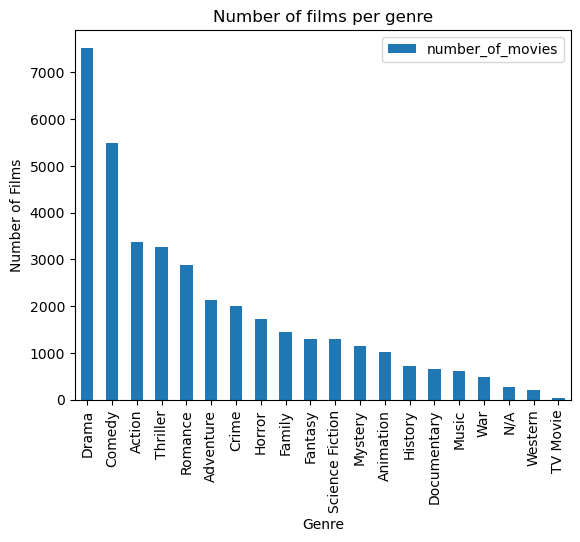

In [ ]:
genres_dict = dict()

for genre in df["genres_processed"]:
    for elem in genre:
        if elem not in genres_dict:
            genres_dict[elem] = 1
        else:
            genres_dict[elem] += 1

genres_df = pd.DataFrame.from_dict(genres_dict, orient='index')
genres_df.columns = ["number_of_movies"]
genres_df = genres_df.sort_values(by="number_of_movies", ascending=False)
genres_df.plot.bar()
plt.title("Number of films per genre")
plt.ylabel("Number of Films")
plt.xlabel("Genre")

In [ ]:
print(df['Drama'].sum())
print(df['Comedy'].sum())
print(df['Action'].sum())
print(df['Thriller'].sum())
print(df['Romance'].sum())
print(df['Adventure'].sum())
print(df['Crime'].sum())
print(df['Horror'].sum())
print(df['Family'].sum())
print(df['Fantasy'].sum())
print(df['Science Fiction'].sum())
print(df['Mystery'].sum())
print(df['Animation'].sum())
print(df['History'].sum())
print(df['Documentary'].sum())
print(df['Music'].sum())
print(df['War'].sum())
print(df['N/A'].sum())
print(df['Western'].sum())
print(df['TV Movie'].sum())

7523
5492
3365
3261
2872
2127
2010
1715
1447
1305
1296
1148
1024
717
654
618
493
262
213
37


When it comes to different types of movies, there is a pattern that resembles a logarithmic function in terms of their frequency. Drama is the most common genre with 7409 films, while TV Movies are the least common with only 37 films. This dataset is assumed to be a good representation of overall trends in filmmaking when making assumptions about the data. It is expected that more popular genres would also generate higher revenue due to their increased popularity. However, we should keep in mind the possibility of exceptions or even opposite hypotheses.

#### Bivariate Analysis

In [ ]:
genres_df.index.values

array(['Drama', 'Comedy', 'Action', 'Thriller', 'Romance', 'Adventure',
       'Crime', 'Horror', 'Family', 'Fantasy', 'Science Fiction',
       'Mystery', 'Animation', 'History', 'Documentary', 'Music', 'War',
       'N/A', 'Western', 'TV Movie'], dtype=object)

In [ ]:
dummy_genres = pd.get_dummies(df['genres_processed'].apply(pd.Series).stack()).groupby(level=0).sum()

pd.concat([df, dummy_genres], axis=1)
df

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,...,Music,Mystery,N/A,Romance,Science Fiction,TV Movie,Thriller,War,Western,genres_no
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,3.520565e+08,...,0,0,0,0,1,0,0,0,0,29
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,6.567582e+07,...,0,1,0,0,0,0,1,0,0,23
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,Marvel Studios-Maximum Effort-21 Laps Entertai...,2024-07-24,200000000.0,1.326387e+09,...,0,0,0,0,1,0,0,0,0,29
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,4.070455e+08,...,0,0,0,0,1,0,0,0,0,32
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,Legendary Pictures,2024-02-27,190000000.0,6.838137e+08,...,0,0,0,0,1,0,0,0,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721132,508713,Juna,Drama-Science Fiction,de,A dream shows Juna that she has only one last ...,0.600,NOT FROM L.A. PRODUTCION BERLIN,2018-03-20,200.0,2.000000e+02,...,0,0,0,0,1,0,0,0,0,21
721423,508882,Vaat Bahar Jai Nai,N/A,en,Romantic Drama of Old couple who divulges ther...,0.600,NaN,2005-08-05,20000.0,2.200000e+04,...,0,0,1,0,0,0,0,0,0,3
721664,525758,The Lost Land,Drama-Comedy,zh,At a small town in the west of China in 1935 t...,0.600,NaN,2018-05-18,0.0,2.028640e+05,...,0,0,0,0,0,0,0,0,0,12
721680,493180,Super Bheem Toota Khush Tara,N/A,en,NaN,0.600,NaN,2017-12-17,256982.0,1.253654e+06,...,0,0,1,0,0,0,0,0,0,3


In [ ]:
for i, g in enumerate(genres_df.index.values):
    genres_df.loc[g, "median_revenue"] = df[df[g]==1].revenue.median()

genres_df.sort_values(by=["number_of_movies", "median_revenue"], ascending=False).head(10)

,number_of_movies,median_revenue
Drama,7526,3547684.0
Comedy,5492,6981732.5
Action,3365,13851432.0
Thriller,3261,8249053.0
Romance,2872,5600000.0
Adventure,2127,24200000.0
Crime,2010,8391469.0
Horror,1715,3400000.0
Family,1447,16453258.0
Fantasy,1305,16589540.0


In [ ]:
for i, g in enumerate(genres_df.index.values):
    genres_df.loc[g, "mean_revenue"] = df[df[g]==1].revenue.mean()

genres_df.sort_values(by=["number_of_movies", "mean_revenue"], ascending=False)

,number_of_movies,median_revenue,mean_revenue
Drama,7526,3547684.0,2.920571e+07
Comedy,5492,6981732.5,4.465461e+07
Action,3365,13851432.0,8.967947e+07
Thriller,3261,8249053.0,4.755838e+07
Romance,2872,5600000.0,3.401012e+07
Adventure,2127,24200000.0,1.383243e+08
Crime,2010,8391469.0,4.116134e+07
Horror,1715,3400000.0,2.783531e+07
Family,1447,16453258.0,9.424226e+07
Fantasy,1305,16589540.0,1.106407e+08


Text(0.5, 0, 'Genre')

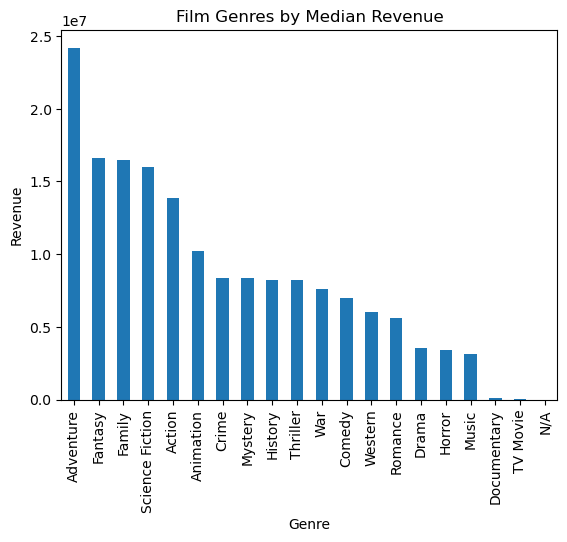

In [ ]:
genres_df.sort_values(by=["median_revenue"], ascending=False).median_revenue.plot.bar()
plt.title("Film Genres by Median Revenue")
plt.ylabel("Revenue")
plt.xlabel("Genre")

Text(0.5, 0, 'Genre')

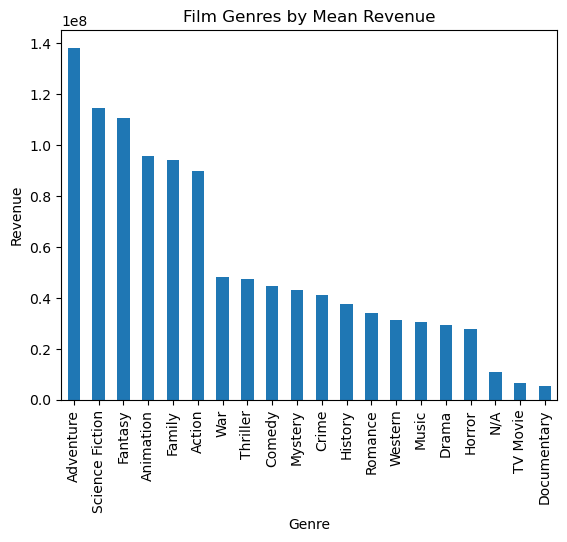

In [ ]:
genres_df.sort_values(by=["mean_revenue"], ascending=False).mean_revenue.plot.bar()
plt.title("Film Genres by Mean Revenue")
plt.ylabel("Revenue")
plt.xlabel("Genre")

In [ ]:
genres_df_sorted = genres_df.sort_values(by=["mean_revenue"], ascending=False)
genres_table = genres_df_sorted.style.set_caption("Mean Revenues by Genre")
display(genres_table)

,number_of_movies,median_revenue,mean_revenue
Adventure,2127,24200000.000000,138324281.928068
Science Fiction,1296,15973160.500000,114402856.190586
Fantasy,1305,16589540.000000,110640703.650575
Animation,1025,10218530.500000,95665476.122070
Family,1447,16453258.000000,94242258.510712
Action,3365,13851432.000000,89679470.614859
War,493,7630000.000000,48204808.346856
Thriller,3261,8249053.000000,47558379.074210
Comedy,5492,6981732.500000,44654611.796067
Mystery,1148,8335965.500000,42927373.964286


It is difficult to determine from this data whether the commonality of a film (i.e., the number of movies produced in a genre) correlates positively to revenue. While Adventure, Fantasy, Action and Science Fiction genres do have a high number of movies produced, it is possible that this is not the only factor contributing to their high mean revenues. Other factors such as the popularity of the genre, the quality of the movies, and the size of the target audience may also play a role in driving up the revenue. Therefore, it is not safe to assume that a high number of movies produced in a genre necessarily results in higher revenue.

One possible reason why Adventure, Fantasy, Action, and Science Fiction genres may have higher mean revenues compared to other genres is that they have a broad appeal and are popular across different age groups and demographics. Another reason could be that these genres often involve big-budget productions with special effects, which can attract a larger audience and generate more revenue. Additionally, these genres often have established fan bases from books, comics, or other media, which can contribute to their popularity and revenue.

It is possible that a high number of movies produced in a genre can lead to a saturated market and reduced demand for movies in that genre. Additionally, if the quality of the movies produced in a genre is not up to the mark, this can also reduce demand for that genre. Ultimately, the demand for a genre depends on various factors such as changing trends, audience preferences, and the overall quality of the movies produced in that genre.

<Axes: >

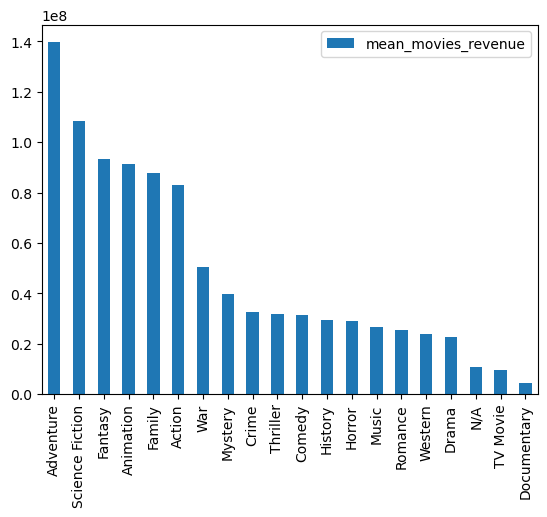

In [ ]:
top_genre_dict = {}
temp = float('inf')

for revenue, genres in df[['revenue', 'genres_processed']].values:
    temp = min(temp, len(genres))
    for i in range(temp):
        genre = genres[i]
        if genre not in top_genre_dict:
            top_genre_dict[genre] = [revenue, 1]
        else:
            top_genre_dict[genre][0] += revenue
            top_genre_dict[genre][1] += 1

for genre, (total_revenue, movie_count) in top_genre_dict.items():
    top_genre_dict[genre] = total_revenue / movie_count

genres_df = pd.DataFrame.from_dict(top_genre_dict, orient='index', columns=['mean_movies_revenue'])
genres_df.sort_values(by='mean_movies_revenue', ascending=False).head(25).plot.bar()

In [ ]:
top_genre_dict = dict(sorted(top_genre_dict.items(), key=lambda item: item[1], reverse=True))
genres_dict = dict(sorted(top_genre_dict.items(), key=lambda item: item[1], reverse=True))

print(top_genre_dict)
print(genres_dict)

{'Adventure': 139739517.04098362, 'Science Fiction': 108570761.3482428, 'Fantasy': 93336846.270903, 'Animation': 91354625.53160454, 'Family': 87769225.82018927, 'Action': 83191253.82537386, 'War': 50482794.057553954, 'Mystery': 39606314.57065217, 'Crime': 32432105.34670947, 'Thriller': 31789117.273570325, 'Comedy': 31385300.866021693, 'History': 29480532.94117647, 'Horror': 29038867.88374384, 'Music': 26623189.557788946, 'Romance': 25321114.93957115, 'Western': 24037698.505494505, 'Drama': 22686882.548813984, 'N/A': 10839405.580152672, 'TV Movie': 9476869.833333334, 'Documentary': 4348909.183520599}
{'Adventure': 139739517.04098362, 'Science Fiction': 108570761.3482428, 'Fantasy': 93336846.270903, 'Animation': 91354625.53160454, 'Family': 87769225.82018927, 'Action': 83191253.82537386, 'War': 50482794.057553954, 'Mystery': 39606314.57065217, 'Crime': 32432105.34670947, 'Thriller': 31789117.273570325, 'Comedy': 31385300.866021693, 'History': 29480532.94117647, 'Horror': 29038867.8837438

In [ ]:
def get_genre_rank(genres):
    total_sum = 0
    for genre in genres:
        total_sum += list(top_genre_dict.keys()).index(genre)
    return total_sum / len(genres)

In [ ]:
df['genre_rank'] = df['genres_processed'].apply(lambda x: get_genre_rank(x) if len(x) > 0 else 0)

df_genre_rank_counts = df['genre_rank'].value_counts()

In [ ]:
log_features.append('genre_rank')
log_features.append('genres_no')

In [ ]:
genre_rank = df['genre_rank']
revenue = df['revenue']

corr, _ = pearsonr(genre_rank, revenue)
print(f"Pearson's correlation between genre_rank and revenue: {corr:.3f}")

log_genre_rank = np.log1p(genre_rank)
log_revenue = np.log1p(revenue)

corr, _ = pearsonr(log_genre_rank, log_revenue)
print(f"Pearson's correlation between log transformed genre_rank and log transformed revenue: {corr:.3f}")

Pearson's correlation between genre_rank and revenue: -0.271
Pearson's correlation between log transformed genre_rank and log transformed revenue: -0.236


In [ ]:
corr, _ = pearsonr(df['genres_no'], df['revenue'])
print('Pearsons correlation between genres_no and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['genres_no']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed genres_no and log transformed revenue: %.3f' % corr)

Pearsons correlation between genres_no and revenue: 0.233
Pearsons correlation between log transformed genres_no and log transformed revenue: 0.289


Our analysis reveals a slight negative correlation between the ranking we assigned to genres and revenue, followed by a weak positive correlation between the number of genres and revenue.

### Original Language

This column represents the language in which the film was originally released.

#### Univariate Analysis

In [ ]:
print("Counts of each original language:")
print(df['original_language'].value_counts())

Counts of each original language:
original_language
en    10825
es      605
fr      577
ja      459
hi      408
      ...  
sw        1
hr        1
la        1
ga        1
bs        1
Name: count, Length: 86, dtype: int64


Text(0.5, 1.0, 'Revenue for a movie and its and original_language')

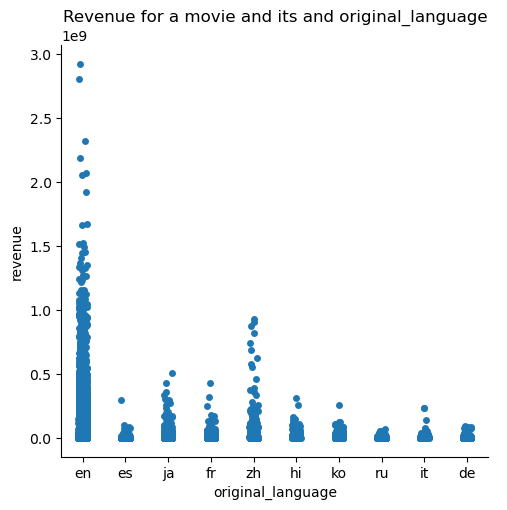

In [ ]:
sns.catplot(x='original_language', y='revenue', data=df.loc[df['original_language'].isin(df['original_language'].value_counts().head(10).index)])
plt.title('Revenue for a movie and its and original_language')

A majority of the movies within the dataset were premiered in the English language, whereas the proportion of films released in alternative languages is relatively diminutive. Consequently, in order to streamline our model, we shall establish a binary variable to discern whether a movie was released in English or in a different language. The specific non-English language does not appear to exert a significant influence; instead, the pivotal factor for our analysis lies in the determination of whether the movie is in English or not. Furthermore, it has been observed that films in the English language tend to yield higher revenues, thus incorporating this feature into our model could potentially confer benefits.

In [ ]:
df['originally_english'] = df.original_language.apply(lambda x: 1 if x == 'en' else 0)

df['originally_english'].value_counts()

originally_english
1    10825
0     5208
Name: count, dtype: int64

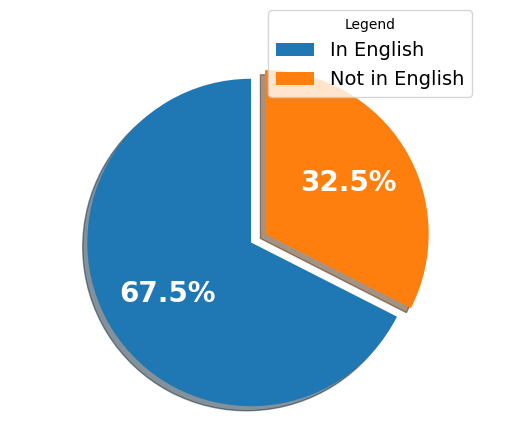

In [ ]:
labels = 'In English', 'Not in English'
btc_1 = [(df.originally_english == 1).sum(axis=0), (df.originally_english == 0).sum(axis=0)]
explode = (0.1, 0)

fig, ax = plt.subplots()
ax.pie(btc_1, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'color':"w", 'fontsize': 20, 'weight':"bold"})
ax.axis('equal')

ax.legend(labels, title="Legend", loc="center left", fontsize=14, bbox_to_anchor=(0.5, 0.5, 0.5, 1))

plt.show()

#### Bivariate Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\2415673173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.catplot(x='originally_english', y='revenue', data=df, palette=pal2);


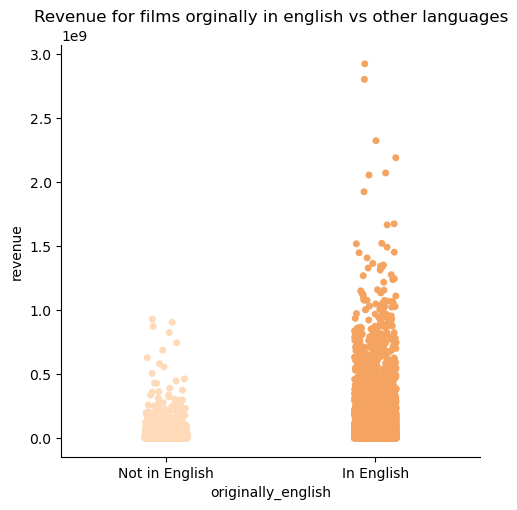

In [ ]:
pal2 = ['peachpuff', 'sandybrown']

ax = sns.catplot(x='originally_english', y='revenue', data=df, palette=pal2);
plt.title('Revenue for films orginally in english vs other languages');

labels = 'Not in English', 'In English'
ax.set_xticklabels(labels)

In [ ]:
df_features.append('originally_english')

In [ ]:
corr, _ = pearsonr(df['originally_english'], df['revenue'])
print('Pearsons correlation between in_english and revenue: %.3f' % corr)

Pearsons correlation between in_english and revenue: 0.175


The correlation between a movie being in English and its revenue is positive but weak, indicating that English-language movies tend to generate higher revenues overall. However, this could be due to the fact that a larger number of movies are released in English compared to other languages, so this correlation may not necessarily indicate a causal relationship between language and revenue.

### Overview
This column contains the overview for a film, which is simply a general summary of what the film is about. It is possible that a well-constructed overview will draw the attention of moviegoers who base what movies they see from reading overviews, but it is unlikely this is a large portion of motivations for movie attendance.

#### Univarate Analysis

In [ ]:
print('df movies missing an overview:',df.overview.isna().sum())

df movies missing an overview: 472


In [ ]:
df.overview = df.overview.fillna("")

In [ ]:
df['overview_len'] = df.overview.apply(len)

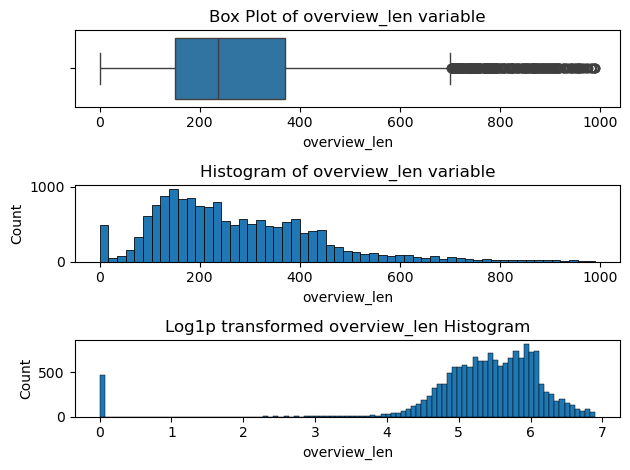

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.overview_len, ax = ax[0])
ax[0].set_title("Box Plot of overview_len variable")
sns.histplot(data=df.overview_len, kde=False, ax=ax[1], alpha=1)
ax[1].set_title("Histogram of overview_len variable")
sns.histplot(data=np.log1p(df.overview_len), kde=False, ax=ax[2], alpha=1)
ax[2].set_title("Log1p transformed overview_len Histogram")
f.tight_layout()

#### Bivariate Analysis

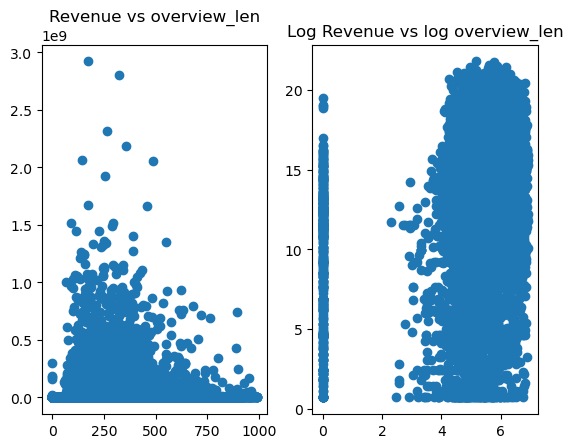

In [ ]:
plt.figure()
plt.subplot(1, 2, 1)
plt.scatter(df['overview_len'], df['revenue'])
plt.title('Revenue vs overview_len');
plt.subplot(1, 2, 2)
plt.scatter(np.log1p(df['overview_len']), np.log1p(df['revenue']))
plt.title('Log Revenue vs log overview_len');

In [ ]:
corr, _ = pearsonr(df['overview_len'], df['revenue'])
print('Pearsons correlation between overview_len and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['overview_len']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed  overview_len and log transformed revenue:: %.3f' % corr)

Pearsons correlation between overview_len and revenue: 0.026
Pearsons correlation between log transformed  overview_len and log transformed revenue:: 0.254


The above analysis shows that there is very little linear correlation between the length of movie overviews and the revenue generated by those movies. While we cannot completely rule out a relationship between these variables, we have decided not to include the overview length in our model since its impact on revenue appears to be insignificant.

In [ ]:
cols_to_drop.append('overview')

### Popularity
This column contains a metric for popularity of a movie, however it is very unclear what this number actually means as it does not follow a clear and obvious scale or rating system. We will further explore the variable to gain more insight.

#### Univariate Analysis

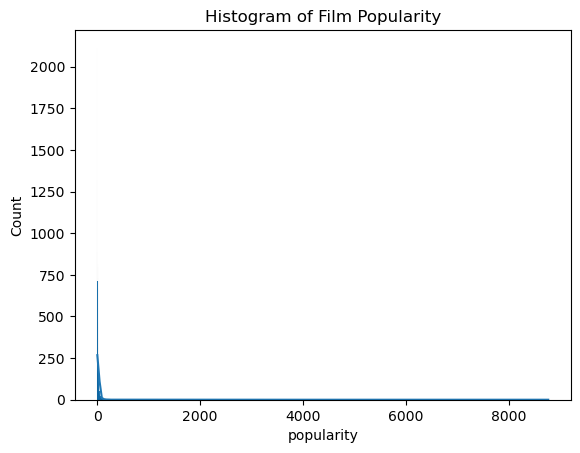

In [ ]:
sns.histplot(df['popularity'], kde=True, alpha=1)
plt.title('Histogram of Film Popularity')
plt.show()

In [ ]:
print(df['popularity'].describe())

count    16033.000000
mean        21.835303
std        147.587343
min          0.090000
25%          3.048000
50%          9.167000
75%         17.296000
max       8763.998000
Name: popularity, dtype: float64


#### Bivariate Analysis

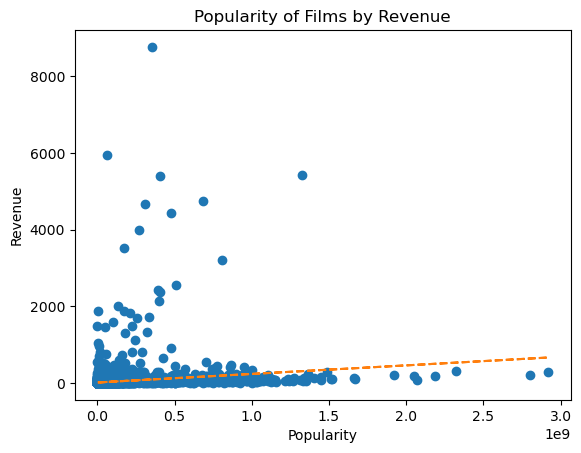

In [ ]:
cx = df['revenue']
pop = df['popularity']
plt.plot(cx, pop, 'o')
plt.ylabel("Revenue")
plt.xlabel("Popularity")
plt.title("Popularity of Films by Revenue")

z = np.polyfit(cx, pop, 1)
p = np.poly1d(z)
plt.plot(cx, p(cx), "--");

In [ ]:
corr, _ = pearsonr(df['popularity'], df['revenue'])
print('Pearsons correlation between popularity and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['popularity']), np.log1p(df['revenue']))
print('Pearsons correlation between log popularity and log revenue: %.3f' % corr)

Pearsons correlation between popularity and revenue: 0.195
Pearsons correlation between log popularity and log revenue: 0.663



The correlation between popularity and revenue in the movie industry was found to be positive, indicating that a film's popularity has a positive impact on its financial success. However, the extent to which popularity serves as an accurate predictor of a movie's revenue is uncertain, as the correlation may be affected by outliers. Some films with high popularity may not see a concurrent increase in revenue, suggesting that popularity may not be a reliable indicator of a movie's financial success.

Additionally, the correlation may not be useful to movie studios as a predictive metric, as popularity is typically only measured after a film has been released. As a result, it may be more practical to consider popularity as a label or factor in the overall assessment of a movie's success, rather than as a specific predictor of box office totals. Therefore, it may be more worthwhile to explore alternative metrics or factors that may offer greater clarity and accuracy in predicting a movie's revenue than popularity.

In [ ]:
cols_to_drop.append('popularity')

### Production Companies

This column contains all of the production companies that worked on each film. Since there are some incredibly popular studios that have reputations, this may play a role in predicting revenue.

In [ ]:
df['production_companies'].head(10)

0    Apelles Entertainment-Warner Bros. Pictures-di...
1    Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...
2    Marvel Studios-Maximum Effort-21 Laps Entertai...
3    Skydance-Paramount-di Bonaventura Pictures-Bay...
4                                   Legendary Pictures
5    Columbia Pictures-Pascal Pictures-Matt Tolmach...
6               Marvel Studios-Kevin Feige Productions
7    Metro-Goldwyn-Mayer-Proximity Media-Balboa Pro...
8    Blumhouse Productions-Stage 6 Films-Screen Gem...
9    Universal Pictures-Illumination-dentsu-Fuji Te...
Name: production_companies, dtype: object

#### Pre-processing

In [ ]:
print("Dataset production_companies missing values:\n", df['production_companies'].isna().sum())

Dataset production_companies missing values:
 1256


In [ ]:
df['production_companies'] = df['production_companies'].fillna('')


df['production_companies'] = df['production_companies'].str.replace('Metro-Goldwyn-Mayer', 'Metro Goldwyn Mayer')
df['production_companies'] = df['production_companies'].str.replace('T-Series', 'T Series')
df['production_companies'] = df['production_companies'].str.replace('Klagemann-Film GmbH', 'Klagemann Film GmbH')
df['production_companies'] = df['production_companies'].str.replace('History', 'History Film')
df['production_companies_processed'] = df['production_companies'].str.split(r"(?<!-)-(?!-)\s*\b")

The first thing we will look at after sorting out the data is the number of production studios on each film. This could be an interesting feature for our model.

In [ ]:
df['production_companies_processed']

0         [Apelles Entertainment, Warner Bros. Pictures,...
1         [Screen Gems, 2.0 Entertainment, Jesus & Mary,...
2         [Marvel Studios, Maximum Effort, 21 Laps Enter...
3         [Skydance, Paramount, di Bonaventura Pictures,...
4                                      [Legendary Pictures]
                                ...                        
721132                    [NOT FROM L.A. PRODUTCION BERLIN]
721423                                                   []
721664                                                   []
721680                                                   []
722122                               [Iranian Independents]
Name: production_companies_processed, Length: 16033, dtype: object

In [ ]:
df['num_studios'] = df.production_companies_processed.apply(lambda x: len(x))

df['num_studios'].value_counts()

num_studios
1     5680
2     3458
3     2602
4     1618
5     1002
6      628
7      349
8      222
9      156
10      80
11      71
12      41
13      33
14      25
15      15
18      11
16       9
19       6
17       6
20       5
22       3
31       2
28       2
26       1
30       1
27       1
32       1
21       1
24       1
23       1
33       1
34       1
Name: count, dtype: int64

#### Univariate Analysis

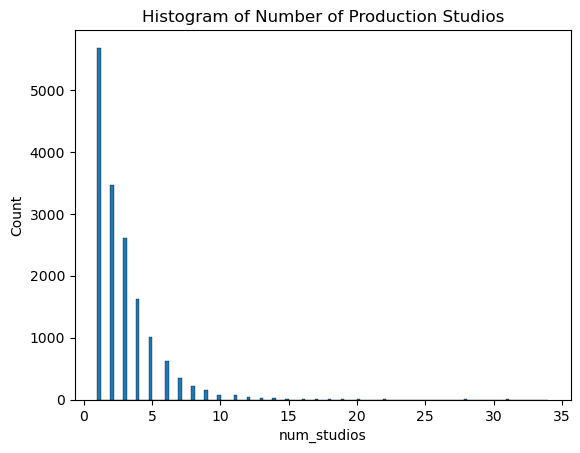

In [ ]:
sns.histplot(df['num_studios'], kde=False, alpha=1)
plt.title('Histogram of Number of Production Studios')
plt.show();

Generally, the fewer movies having more studios involved. Additionally, some independent films may have no production studios.

#### Bivariate Analysis

<Axes: >

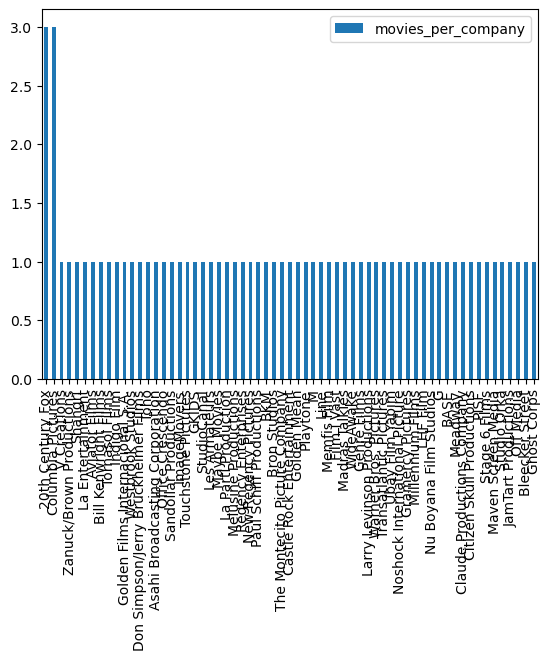

In [ ]:
companiesDict = {}
for element in df["production_companies_processed"].sample(25).values:
    if '' in element:
        element.remove('')
    for company in element:
        if company not in companiesDict:
            companiesDict[company] = 1
        else:
            companiesDict[company] += 1

companies_df = pd.DataFrame.from_dict(companiesDict, orient='index', columns=["movies_per_company"])
companies_df.sort_values(by="movies_per_company", ascending=False).plot.bar()

The number of movies produced by a studio could be a valuable metric for identifying the largest production companies and determining how their size influences the success of their films. This could be attributed to two potential factors: First, larger studios may have more financial resources and be capable of attracting high-profile cast and crew with extensive experience, ultimately resulting in a successful film project. Alternatively, it could be argued that the reliance on franchises by larger studios could lead to a pattern of producing average or mediocre-performing films, lacking in innovative concepts. While there is some likelihood of both scenarios occurring to some degree, machine learning could be utilized to measure the impact of studio size on predicted revenue. Additionally, identifying whether a major studio is involved in a film would be a valuable feature in examining the relationship between studio size and movie success.

Bivariate Analysis

In [ ]:
companiesDict2 = {}
for element in df["production_companies_processed"].values:
    if '' in element:
        element.remove('')
    for company in element:
        if company not in companiesDict2:
            companiesDict2[company] = 1
        else:
            companiesDict2[company] += 1

In [ ]:
companies_df = pd.DataFrame.from_dict(companiesDict2, orient='index', columns=["movies_per_company"])
del companiesDict2

In [ ]:
companies_df

,movies_per_company
Apelles Entertainment,2
Warner Bros. Pictures,713
di Bonaventura Pictures,10
CMC Pictures,2
Gravity Pictures,3
...,...
CCM Film Productions,1
Singing Fish,1
Camera Obskura,1
福建朱子影视文化发展有限公司、北京十月天文化传媒有限公司,1


Since there are a lot of production companies and limited RAM, in order to focus on the most prominent ones that might be impactful to the revenue, we will only add 500 companies as feature columns in our dataset in order to focus on those with a more consistent and established track record.

In [ ]:
companies_df = companies_df.sort_values('movies_per_company', ascending=False).head(500)

In [ ]:
columns_dict = {}

for studio in set(companies_df.index):
    columns_dict[studio] = df['production_companies_processed'].apply(lambda x: 1 if studio in x else 0)

In [ ]:
df = pd.concat([df, pd.DataFrame(columns_dict)], axis=1)
df

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,...,Silver Pictures,Les Films du Fleuve,Fine Line Features,VOO,TBS,Celluloid Dreams,Number 9 Films,Fuji Television Network,Rhône,Dimension Films
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,3.520565e+08,...,0,0,0,0,0,0,0,0,0,0
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,6.567582e+07,...,0,0,0,0,0,0,0,0,0,0
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,Marvel Studios-Maximum Effort-21 Laps Entertai...,2024-07-24,200000000.0,1.326387e+09,...,0,0,0,0,0,0,0,0,0,0
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,4.070455e+08,...,0,0,0,0,0,0,0,0,0,0
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,Legendary Pictures,2024-02-27,190000000.0,6.838137e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721132,508713,Juna,Drama-Science Fiction,de,A dream shows Juna that she has only one last ...,0.600,NOT FROM L.A. PRODUTCION BERLIN,2018-03-20,200.0,2.000000e+02,...,0,0,0,0,0,0,0,0,0,0
721423,508882,Vaat Bahar Jai Nai,N/A,en,Romantic Drama of Old couple who divulges ther...,0.600,,2005-08-05,20000.0,2.200000e+04,...,0,0,0,0,0,0,0,0,0,0
721664,525758,The Lost Land,Drama-Comedy,zh,At a small town in the west of China in 1935 t...,0.600,,2018-05-18,0.0,2.028640e+05,...,0,0,0,0,0,0,0,0,0,0
721680,493180,Super Bheem Toota Khush Tara,N/A,en,,0.600,,2017-12-17,256982.0,1.253654e+06,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
companies_df

,movies_per_company
Warner Bros. Pictures,713
Universal Pictures,675
Columbia Pictures,501
20th Century Fox,500
Paramount,499
...,...
Alphaville Films,12
Color Force,12
Riverstone Pictures,12
FilmDistrict,12


In [ ]:
for g in set(companies_df.index):
    median_revenue = df[df[g] == 1].revenue.median()
    companies_df.loc[g, "median_revenue"] = median_revenue

companies_df.sort_values(by=["movies_per_company", "median_revenue"], ascending=False).head(10)

,movies_per_company,median_revenue
Warner Bros. Pictures,713,38805380.0
Universal Pictures,675,48190704.0
Columbia Pictures,501,50363790.0
20th Century Fox,500,39729713.5
Paramount,499,38793283.0
Metro Goldwyn Mayer,386,11371650.5
Canal+,268,8752125.0
New Line Cinema,256,44800000.0
Walt Disney Pictures,214,125439513.0
Touchstone Pictures,184,49870285.0


In [ ]:
companies_df

,movies_per_company,median_revenue
Warner Bros. Pictures,713,38805380.0
Universal Pictures,675,48190704.0
Columbia Pictures,501,50363790.0
20th Century Fox,500,39729713.5
Paramount,499,38793283.0
...,...,...
Alphaville Films,12,72688089.5
Color Force,12,157367868.0
Riverstone Pictures,12,6890811.0
FilmDistrict,12,47065495.0


In [ ]:
for g in set(companies_df.index.values):
    mean_revenue = df[df[g] == 1].revenue.mean()
    companies_df.loc[g, "mean_revenue"] = mean_revenue

companies_df.sort_values(by=["movies_per_company", "mean_revenue"], ascending=False).head(10)

,movies_per_company,median_revenue,mean_revenue
Warner Bros. Pictures,713,38805380.0,1.138977e+08
Universal Pictures,675,48190704.0,1.155418e+08
Columbia Pictures,501,50363790.0,1.118328e+08
20th Century Fox,500,39729713.5,1.167266e+08
Paramount,499,38793283.0,9.931189e+07
Metro Goldwyn Mayer,386,11371650.5,5.585805e+07
Canal+,268,8752125.0,3.382789e+07
New Line Cinema,256,44800000.0,1.085957e+08
Walt Disney Pictures,214,125439513.0,2.497814e+08
Touchstone Pictures,184,49870285.0,8.299319e+07


In [ ]:
for i, g in enumerate(companies_df.index.values):
    sum_revenue = df[df[g] == 1].revenue.sum()
    companies_df.loc[g, "sum_revenue"] = sum_revenue

companies_df.sort_values(by=["movies_per_company", "sum_revenue"], ascending=False).head(10)

,movies_per_company,median_revenue,mean_revenue,sum_revenue
Warner Bros. Pictures,713,38805380.0,1.138977e+08,8.120903e+10
Universal Pictures,675,48190704.0,1.155418e+08,7.799069e+10
Columbia Pictures,501,50363790.0,1.118328e+08,5.602824e+10
20th Century Fox,500,39729713.5,1.167266e+08,5.836328e+10
Paramount,499,38793283.0,9.931189e+07,4.955663e+10
Metro Goldwyn Mayer,386,11371650.5,5.585805e+07,2.156121e+10
Canal+,268,8752125.0,3.382789e+07,9.065874e+09
New Line Cinema,256,44800000.0,1.085957e+08,2.769191e+10
Walt Disney Pictures,214,125439513.0,2.497814e+08,5.345323e+10
Touchstone Pictures,184,49870285.0,8.299319e+07,1.527075e+10


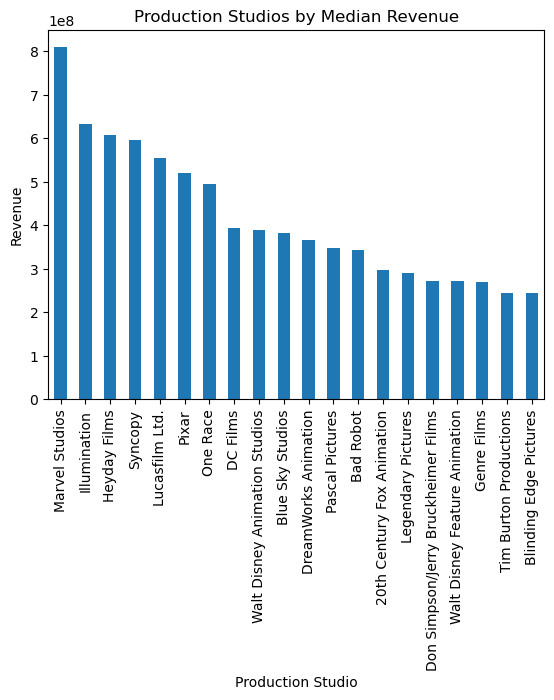

In [ ]:
companies_df.sort_values(by=["median_revenue"], ascending=False).median_revenue.head(20).plot.bar()
plt.title("Production Studios by Median Revenue")
plt.ylabel("Revenue")
plt.xlabel("Production Studio")

plt.show()

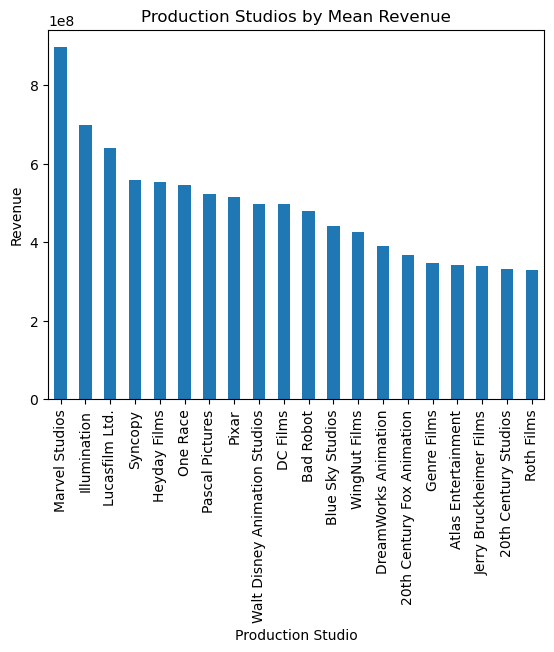

In [ ]:
companies_df.sort_values(by=["mean_revenue"], ascending=False).mean_revenue.head(20).plot.bar()
plt.title("Production Studios by Mean Revenue")
plt.ylabel("Revenue")
plt.xlabel("Production Studio")

plt.show()

Conclusion

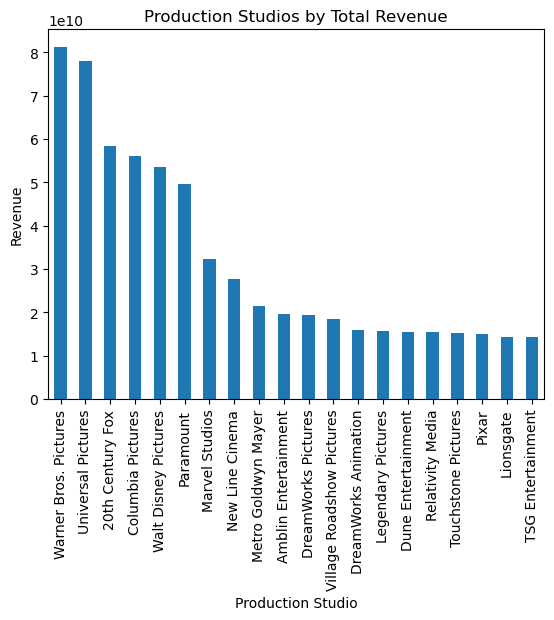

In [ ]:
companies_df.sort_values(by=["sum_revenue"], ascending=False).sum_revenue.head(20).plot.bar()
plt.title("Production Studios by Total Revenue")
plt.ylabel("Revenue")
plt.xlabel("Production Studio")

plt.show()

As anticipated, the production studios closely resemble the studios that have produced the highest number of films. Although some other studios may shift positions, it is also worth considering the primary studios as a focus.

Text(0.5, 0, 'Production Studio')

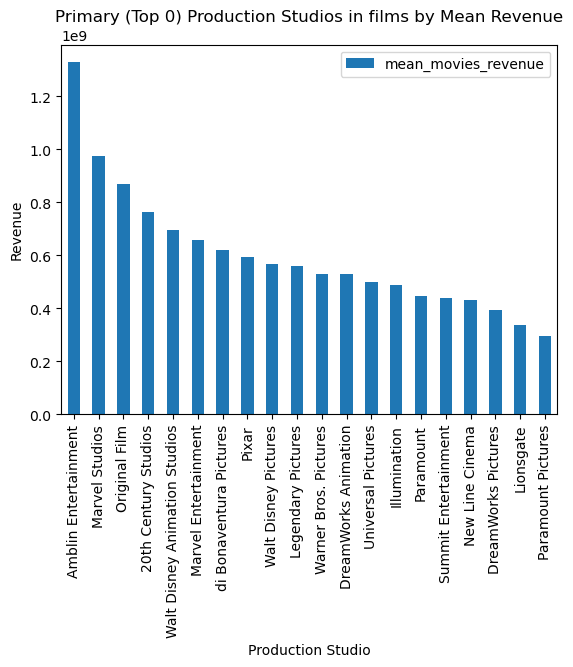

In [ ]:
studiosDict = {}

top_limit = 3
for element in df[["revenue", "production_companies_processed"]].values:
    if len(element[1]) < top_limit:
        top_limit = len(element[1])
    for i in range(top_limit):
        if element[1][i] not in studiosDict:
            studiosDict[element[1][i]] = [element[0], 1]
        else:
            studiosDict[element[1][i]][0] += element[0]
            studiosDict[element[1][i]][1] += 1

studiosDict = {k: v for k, v in studiosDict.items() if v[1] >= 3}

for company in studiosDict:
    studiosDict[company][0] = studiosDict[company][0]/studiosDict[company][1]
    studiosDict[company] = studiosDict[company][0]

studios_df = pd.DataFrame.from_dict(studiosDict, orient='index', columns=["mean_movies_revenue"])
studios_df.sort_values(by="mean_movies_revenue", ascending=False).head(20).plot.bar()
plt.title(f"Primary (Top {top_limit}) Production Studios in films by Mean Revenue")
plt.ylabel("Revenue")
plt.xlabel("Production Studio")

When examining the production_companies feature of an example, if we focus on the top three production studios, we obtain a different barplot for production studios based on average revenue. This approach eliminates film commissions related to specific films with high revenue, which are associated with one or a few production studios. By doing so, we can better utilize the average revenue metric for the primary studios and address the concern of studios with extensive filmographies, like Warner Bros., artificially inflating their 'total revenue' value.

<Axes: >

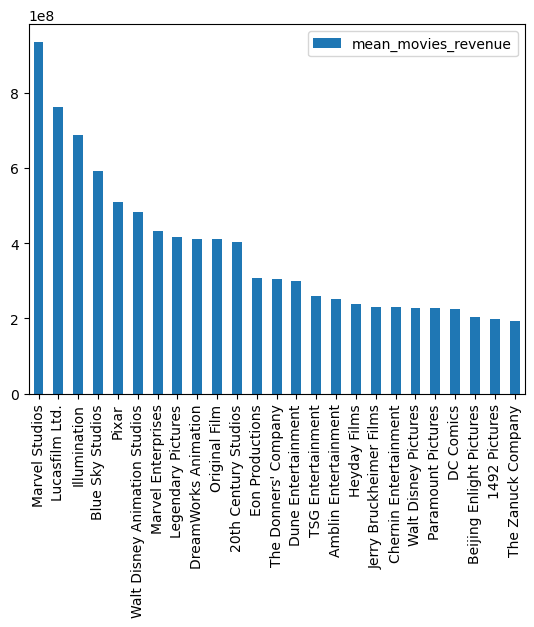

In [ ]:
topStudiosDict = {}
for element in df[["revenue", "production_companies_processed"]].values:
    temp = 1
    if len(element[1]) < temp:
        temp = len(element[1])
    for i in range(temp):
        if element[1][i] not in topStudiosDict:
            topStudiosDict[element[1][i]] = [element[0], 1]
        else:
            topStudiosDict[element[1][i]][0] += element[0]
            topStudiosDict[element[1][i]][1] += 1

topStudiosDict = {k: v for k, v in topStudiosDict.items() if v[1] >= 5}

for company in topStudiosDict:
    topStudiosDict[company][0] = topStudiosDict[company][0]/topStudiosDict[company][1]
    topStudiosDict[company] = topStudiosDict[company][0]

studios_df = pd.DataFrame.from_dict(topStudiosDict, orient='index', columns=["mean_movies_revenue"])
studios_df.sort_values(by="mean_movies_revenue", ascending=False).head(25).plot.bar()

In [ ]:
topStudiosDict = {k: v for k, v in sorted(topStudiosDict.items(), key=lambda item: item[1], reverse = True)}
studiosDict = {k: v for k, v in sorted(studiosDict.items(), key=lambda item: item[1], reverse = True)}

In [ ]:
def checkTopStudios(studio):
    if len(studio) < 1 or studio[0] not in list(topStudiosDict)[:50]:
        return 0
    else:
        return 1

In [ ]:
def checkStudios(studio):
    if len(studio) < 1:
        return 0
    count = 0
    for company in studio[:10]:
        if company in list(studiosDict)[:100]:
            count += 1
    return count

In [ ]:
def getStudioRanks(studios):
    if len(studios) < 1:
        return 400
    rank = 0
    for s in studios[:5]:
        if s in list(studiosDict):
            rank += list(studiosDict.keys()).index(s)
    if rank == 0:
        rank = 400
    return rank / len(studios)

In [ ]:
df['topStudio'] = df['production_companies_processed'].apply(lambda x: checkTopStudios(x))
df['numTopStudios'] = df['production_companies_processed'].apply(lambda x: checkStudios(x))

studiosDict = {k: v for k, v in sorted(studiosDict.items(), key=lambda item: item[1], reverse = True)}

df['studioRank'] = df['production_companies_processed'].apply(lambda x: getStudioRanks(x))

print(df['topStudio'].value_counts())
print()
print(df['numTopStudios'].value_counts())
print()
print(df['studioRank'].value_counts())

topStudio
0    14248
1     1785
Name: count, dtype: int64

numTopStudios
0    11400
1     4115
2      466
3       50
4        2
Name: count, dtype: int64

studioRank
400.000000    4815
200.000000    2272
133.333333    1641
100.000000     932
80.000000      587
              ... 
11.333333        1
33.000000        1
0.833333         1
19.500000        1
11.764706        1
Name: count, Length: 242, dtype: int64


In [ ]:
len(studiosDict)

34


To assess the influence of production studios, we compiled two dictionaries: one listing all studios and another listing the primary studios (the first one mentioned) sorted by average revenue. We added two new columns to gauge the studio's impact: "topStudio" indicates if the primary studio is among the top 25, while "numTopStudios" counts the number of top-revenue studios involved in the film.

In [ ]:
corr, _ = pearsonr(df['topStudio'], df['revenue'])
print('Pearsons correlation between topStudio and revenue: %.3f' % corr)
corr, _ = pearsonr(df['topStudio'], np.log1p(df['revenue']))
print('Pearsons correlation between topStudio and revenue: %.3f' % corr)

Pearsons correlation between topStudio and revenue: 0.359
Pearsons correlation between topStudio and revenue: 0.286


In [ ]:
corr, _ = pearsonr(df['numTopStudios'], df['revenue'])
print('Pearsons correlation between numTopStudios and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['numTopStudios']), np.log1p(df['revenue']))
print('Pearsons correlation between numTopStudios and revenue: %.3f' % corr)

Pearsons correlation between numTopStudios and revenue: 0.388
Pearsons correlation between numTopStudios and revenue: 0.451


In [ ]:
corr, _ = pearsonr(df['studioRank'], df['revenue'])
print('Pearsons correlation between studioRank and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['studioRank']), np.log1p(df['revenue']))
print('Pearsons correlation between studioRank and revenue: %.3f' % corr)
print()

Pearsons correlation between studioRank and revenue: -0.259
Pearsons correlation between studioRank and revenue: -0.519



In [ ]:
corr, _ = pearsonr(df['num_studios'], df['revenue'])
print('Pearsons correlation between num_studios and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['num_studios']), np.log1p(df['revenue']))
print('Pearsons correlation between num_studios and revenue: %.3f' % corr)

Pearsons correlation between num_studios and revenue: 0.077
Pearsons correlation between num_studios and revenue: 0.330


We have identified a moderate positive correlation between the created columns used to quantify the top studios. This finding is encouraging, as it suggests that these columns may possess some predictive ability for revenue. Additionally, there is a weaker positive correlation between the number of studios involved in a movie and its revenue.

In [ ]:
df_features.append('topStudio')
log_features.append('numTopStudios')
log_features.append('num_studios')
log_features.append('studioRank')

### Release date

In [ ]:
df['release_date'].head(10)

0    2023-08-02
1    2023-04-05
2    2024-07-24
3    2023-06-06
4    2024-02-27
5    2024-10-22
6    2023-02-15
7    2023-03-01
8    2023-07-05
9    2024-06-20
Name: release_date, dtype: object

#### Pre-processing

Initially, we will manipulate the release date data by creating a separate dataframe and converting it to a datetime format. We will use the ".dt" function to access specific quantities from the date, facilitating data organization and management.

In [ ]:
df_date = df['release_date']

df_date = pd.to_datetime(df_date)
df_date.dt
print(df_date)

0        2023-08-02
1        2023-04-05
2        2024-07-24
3        2023-06-06
4        2024-02-27
            ...    
721132   2018-03-20
721423   2005-08-05
721664   2018-05-18
721680   2017-12-17
722122   2017-02-02
Name: release_date, Length: 16033, dtype: datetime64[ns]


Let's observe the year, the day, the day of the year, and the week of the year, which will be analyzed later.

In [ ]:
print(df_date.dt.year)
print(df_date.dt.day)
print(df_date.dt.dayofyear)
print(df_date.dt.isocalendar().week)

0         2023
1         2023
2         2024
3         2023
4         2024
          ... 
721132    2018
721423    2005
721664    2018
721680    2017
722122    2017
Name: release_date, Length: 16033, dtype: int32
0          2
1          5
2         24
3          6
4         27
          ..
721132    20
721423     5
721664    18
721680    17
722122     2
Name: release_date, Length: 16033, dtype: int32
0         214
1          95
2         206
3         157
4          58
         ... 
721132     79
721423    217
721664    138
721680    351
722122     33
Name: release_date, Length: 16033, dtype: int32
0         31
1         14
2         30
3         23
4          9
          ..
721132    12
721423    31
721664    20
721680    50
722122     5
Name: week, Length: 16033, dtype: UInt32


Let's also observe the descriptive statistics of the release dates and the years extracted from the release date column

In [ ]:
print(df.release_date.describe())
print(df_date.dt.year.describe())

count          16033
unique          8146
top       2018-02-16
freq              12
Name: release_date, dtype: object
count    16033.000000
mean      2003.197468
std         17.766089
min       1914.000000
25%       1996.000000
50%       2008.000000
75%       2016.000000
max       2024.000000
Name: release_date, dtype: float64


#### Univariate Analysis

Text(0.5, 1.0, 'Year of Release Date by Number of Films')

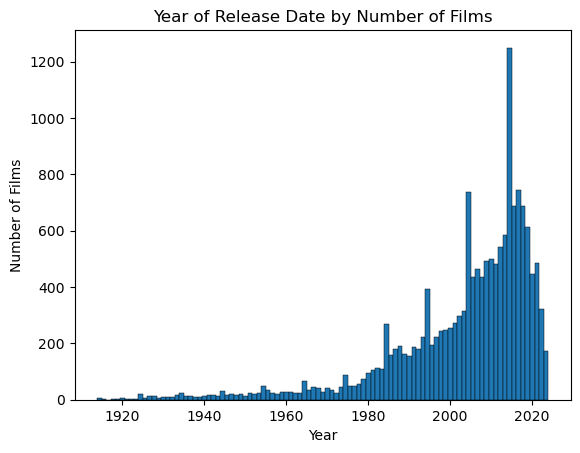

In [ ]:
fig, ax = plt.subplots()
sns.histplot(df_date.dt.year, bins=99, kde=False, alpha=1, ax=ax)

ax.set()
ax.set_xlabel("Year")
ax.set_ylabel("Number of Films")
ax.set_title("Year of Release Date by Number of Films")

The dataset's plot of film releases over the years demonstrates a consistent rise, which is expected in an evolving industry. Although generally following a linear pattern, there are occasional spikes. Exploring the connection between years with an above-average number of films and their corresponding revenues could be an intriguing avenue to explore.

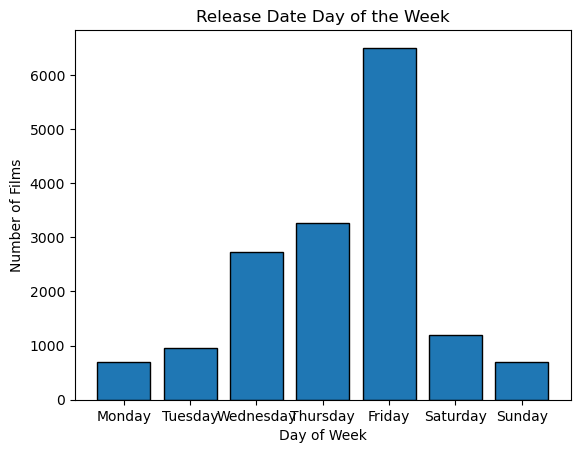

In [ ]:
fig, ex = plt.subplots()
sns.histplot(df_date.dt.dayofweek, kde=False, alpha=1, ax=ex, bins=7,
             binrange=[0,6], discrete=True, shrink=0.8, stat='count',
             label='Number of films per day of the week')

ex.set_xlabel("Day of Week")
ex.set_ylabel("Number of Films")
ex.set_title("Release Date Day of the Week")

ex.set_xticks(range(0, 7))
labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ex.set_xticklabels(labels)

plt.show()

The success of a movie at the box office can be affected by the day of its release. Fridays tend to be popular release days as people are more likely to attend a movie after work if they have fewer responsibilities the next day. This is linked to the common five-day workweek. Market patterns suggest that releasing a movie on Friday will have a positive impact on sales, and as a result, on box office totals. However, Saturdays do not perform as well as Fridays, and surprisingly, they perform even lower than Tuesdays, Wednesdays, and Thursdays. It was initially assumed that many movie-goers would attend a film on a Saturday, but unexpected factors could be contributing to lower attendance on this day.

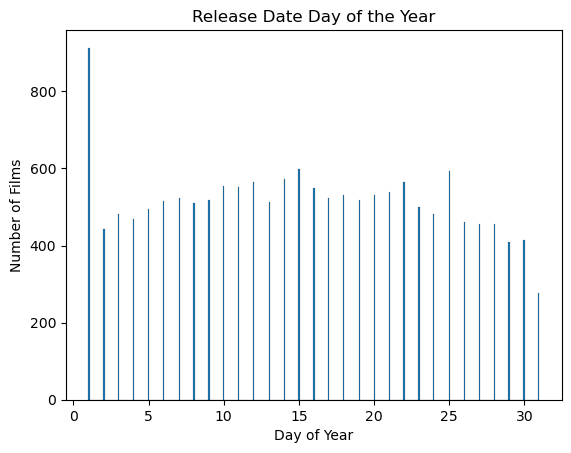

In [ ]:
fig, ax = plt.subplots()
sns.histplot(df_date.dt.day.astype(int), bins=365, kde=False, alpha=1)

ax.set_xlabel("Day of Year")
ax.set_ylabel("Number of Films")
ax.set_title("Release Date Day of the Year")

plt.show()

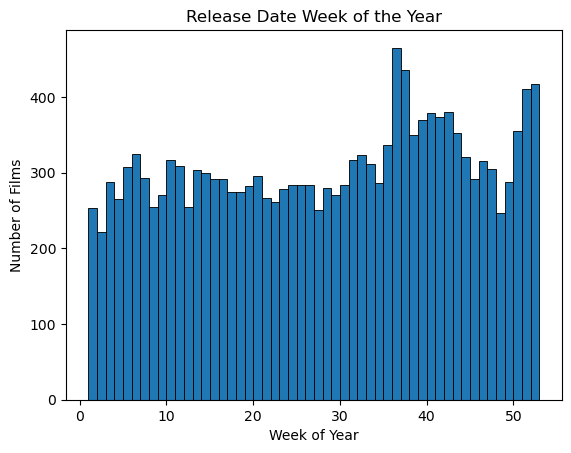

In [ ]:
fig, ax = plt.subplots()
sns.histplot(df_date.dt.isocalendar().week.astype(int), bins=52, kde=False, alpha=1)

ax.set_xlabel("Week of Year")
ax.set_ylabel("Number of Films")
ax.set_title("Release Date Week of the Year")

plt.show()

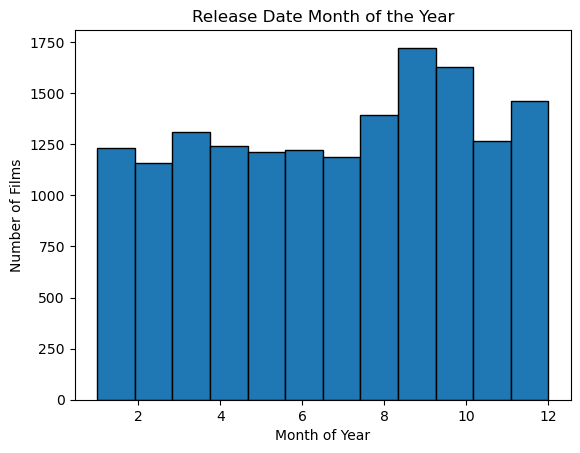

In [ ]:
fig, ax = plt.subplots()
sns.histplot(df_date.dt.month.astype(int), bins=12, kde=False, alpha=1)

ax.set_xlabel("Month of Year")
ax.set_ylabel("Number of Films")
ax.set_title("Release Date Month of the Year")

plt.show()

#### Bivariate Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\3580803343.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  dx.set_xticklabels(dx.get_xticklabels(), rotation=90)


[Text(0, 0, '1914'),
 Text(1, 0, '1915'),
 Text(2, 0, '1916'),
 Text(3, 0, '1918'),
 Text(4, 0, '1919'),
 Text(5, 0, '1920'),
 Text(6, 0, '1921'),
 Text(7, 0, '1922'),
 Text(8, 0, '1923'),
 Text(9, 0, '1924'),
 Text(10, 0, '1925'),
 Text(11, 0, '1926'),
 Text(12, 0, '1927'),
 Text(13, 0, '1928'),
 Text(14, 0, '1929'),
 Text(15, 0, '1930'),
 Text(16, 0, '1931'),
 Text(17, 0, '1932'),
 Text(18, 0, '1933'),
 Text(19, 0, '1934'),
 Text(20, 0, '1935'),
 Text(21, 0, '1936'),
 Text(22, 0, '1937'),
 Text(23, 0, '1938'),
 Text(24, 0, '1939'),
 Text(25, 0, '1940'),
 Text(26, 0, '1941'),
 Text(27, 0, '1942'),
 Text(28, 0, '1943'),
 Text(29, 0, '1944'),
 Text(30, 0, '1945'),
 Text(31, 0, '1946'),
 Text(32, 0, '1947'),
 Text(33, 0, '1948'),
 Text(34, 0, '1949'),
 Text(35, 0, '1950'),
 Text(36, 0, '1951'),
 Text(37, 0, '1952'),
 Text(38, 0, '1953'),
 Text(39, 0, '1954'),
 Text(40, 0, '1955'),
 Text(41, 0, '1956'),
 Text(42, 0, '1957'),
 Text(43, 0, '1958'),
 Text(44, 0, '1959'),
 Text(45, 0, '1960')

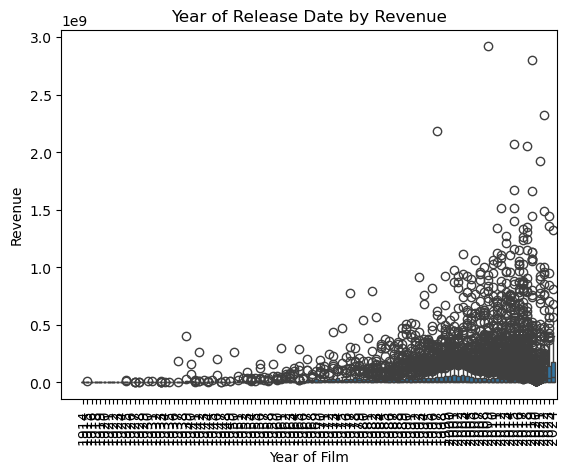

In [ ]:
fig, dx = plt.subplots()
sns.boxplot(x=df_date.dt.year, y=df['revenue'])

dx.set(xlim=(-5, 110))
dx.set_xlabel("Year of Film")
dx.set_ylabel("Revenue")
dx.set_title("Year of Release Date by Revenue")

dx.set_xticklabels(dx.get_xticklabels(), rotation=90)

In this scenario, the film revenues tend to rise steadily over time, with certain years standing out as exceptionally profitable.

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\3344392049.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ex.set_xticklabels(labels)


[Text(0, 0, 'Monday'),
 Text(1, 0, 'Tuesday'),
 Text(2, 0, 'Wednesday'),
 Text(3, 0, 'Thursday'),
 Text(4, 0, 'Friday'),
 Text(5, 0, 'Saturday'),
 Text(6, 0, 'Sunday')]

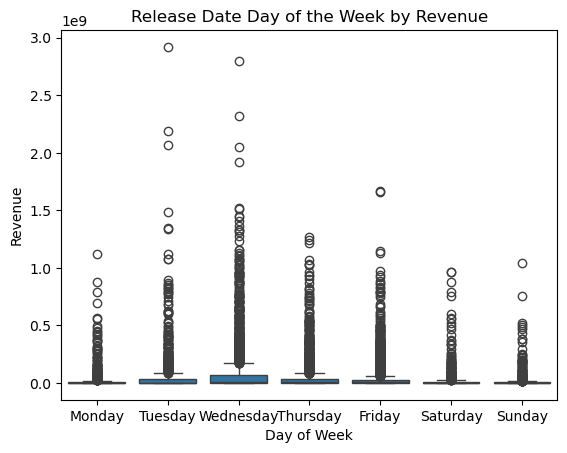

In [ ]:
fig, ex = plt.subplots()
sns.boxplot(x=df_date.dt.dayofweek, y=df['revenue'])

ex.set_xlabel("Day of Week")
ex.set_ylabel("Revenue")
ex.set_title("Release Date Day of the Week by Revenue")

labels = [item.get_text() for item in ex.get_xticklabels()]
labels[0] = 'Monday'
labels[1] = 'Tuesday'
labels[2] = 'Wednesday'
labels[3] = 'Thursday'
labels[4] = 'Friday'
labels[5] = 'Saturday'
labels[6] = 'Sunday'

ex.set_xticklabels(labels)

Surprisingly, despite the hypothesis that Friday was the most common release date because of some monetary benefit to sales, Wednesday (followed by Tuesday & Thursday) has the highest revenue. It would be interesting to investigate why this is the case, but regardless it will help inform the outcome of the model.

Text(0.5, 1.0, 'Release Date Day of the Year by Revenue')

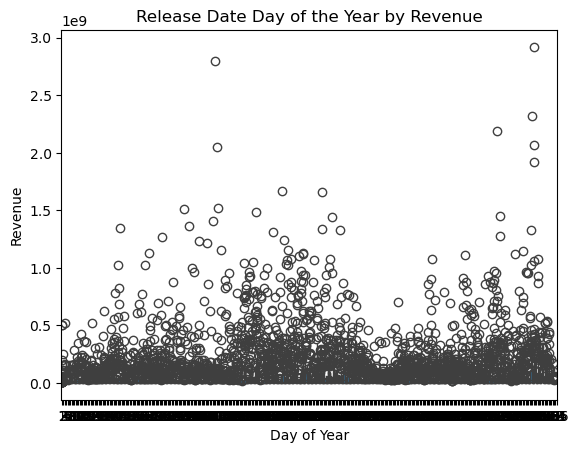

In [ ]:
fig, fx = plt.subplots()
sns.boxplot(x=df_date.dt.dayofyear, y=df['revenue'])

fx.set_xlabel("Day of Year")
fx.set_ylabel("Revenue")
fx.set_title("Release Date Day of the Year by Revenue")

Presenting the vast amount of data in the same format as the other bivariate analysis plots for release date and revenue poses a challenge.

Text(0.5, 1.0, 'Release Date Week of the Year by Revenue')

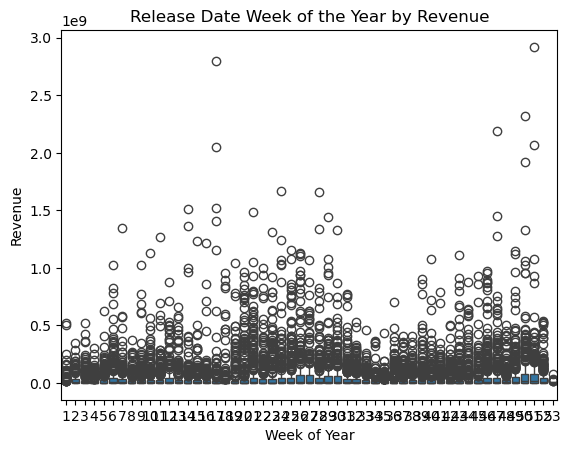

In [ ]:
fig, gx = plt.subplots()
sns.boxplot(x=df_date.dt.isocalendar().week, y=df['revenue'])

gx.set_xlabel("Week of Year")
gx.set_ylabel("Revenue")
gx.set_title("Release Date Week of the Year by Revenue")

The revenue for each week of the year aligns closely with the anticipated outcomes from the univariate analysis. Weeks leading up to the holiday season consistently demonstrate higher revenue. Additionally, there is a significant spike in revenue during the 17th week of April, which can be attributed to the release of blockbuster films like Avengers: Infinity War and Avengers: Endgame, albeit in different years. Another noteworthy peak occurs during the midsummer season in July, specifically during the 27th week of the year.

Text(0.5, 1.0, 'Release Date Month by Revenue')

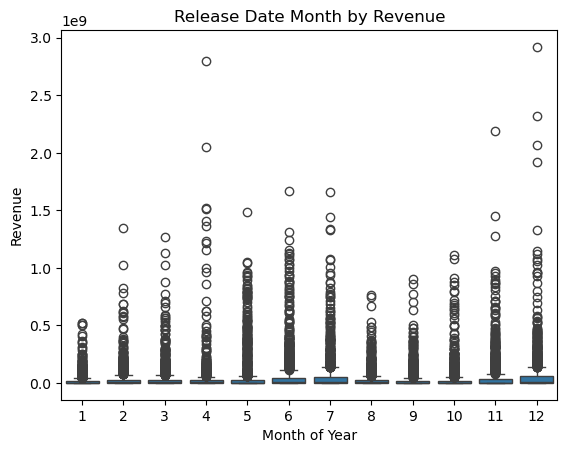

In [ ]:
fig, hx = plt.subplots()
sns.boxplot(x=df_date.dt.month, y=df['revenue'])

hx.set_xlabel("Month of Year")
hx.set_ylabel("Revenue")
hx.set_title("Release Date Month by Revenue")

Similarly to above, the month of the year follows a similar trend. The midsummer months are successful, although not numerous in terms of release, while the 'dump months' during the start of the school year have a higher number of films and significantly lower revenue. The holiday season in December shows a higher number of releases and a concurrently higher revenue.

Next, we will fill the NA values with statistical mode

In [ ]:
df["release_date"] = df["release_date"].fillna(df["release_date"].mode()[0])

df['temp'] = df.release_date.apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))

df["month"] = df.temp.apply(lambda x: x.month)

df["year"] = df.temp.apply(lambda x: x.year)

df["day_of_week"] = df.temp.apply(lambda x: x.weekday()+1)

df["week_of_year"] = df.temp.apply(lambda x: x.isocalendar()[1])

df = df.drop(['temp'], axis=1)

df["day_of_week"] = df["day_of_week"].fillna(df["day_of_week"].mode()[0])

df["year"] = df["year"].fillna(df["year"].mode()[0])

df["month"] = df["month"].fillna(df["month"].mode()[0])

df["week_of_year"] = df["week_of_year"].fillna(df["week_of_year"].mode()[0])

df[["release_date", "month", "year", "day_of_week", "week_of_year"]].head()

,release_date,month,year,day_of_week,week_of_year
0,2023-08-02,8,2023,3,31
1,2023-04-05,4,2023,3,14
2,2024-07-24,7,2024,3,30
3,2023-06-06,6,2023,2,23
4,2024-02-27,2,2024,2,9


In [ ]:
corr, _ = pearsonr(df['year'], df['revenue'])
print('Pearsons correlation between year and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['year']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed year and log transformed revenue: %.3f' % corr)

Pearsons correlation between year and revenue: 0.078
Pearsons correlation between log transformed year and log transformed revenue: -0.110


In [ ]:
corr, _ = pearsonr(df['month'], df['revenue'])
print('Pearsons correlation between month and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['month']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed month and log transformed revenue: %.3f' % corr)

Pearsons correlation between month and revenue: 0.033
Pearsons correlation between log transformed month and log transformed revenue: 0.050


In [ ]:
corr, _ = pearsonr(df['week_of_year'], df['revenue'])
print('Pearsons correlation between week_of_year and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['week_of_year']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed week_of_year and log transformed revenue: %.3f' % corr)

Pearsons correlation between week_of_year and revenue: 0.030
Pearsons correlation between log transformed week_of_year and log transformed revenue: 0.041


The extracted variables from the release date show little correlation with revenue. However, to account for any potential relationships, all these variables will be included in the model. Instead of using them as metrics, dummy variables will be created to better represent relevant aspects of the release date. The year will be categorized rather than treated as a continuous variable and log-transformed. Similarly, season and day of the week will also be captured categorically.

In [ ]:
df.loc[df['year'].idxmin(), ['title', 'year', 'revenue']]

title      Neptune's Daughter
year                     1914
revenue             5773000.0
Name: 90007, dtype: object

The years in the dataset will be categorized by decade, starting from the 1910s since the earliest movie in the trimmed dataset dates back to 1914, and no predictions will be made for earlier years.

In [ ]:
df['1910s'] = df.year.map(lambda x: 1 if (x >= 1910 and x <= 1919) else 0)

df['1920s'] = df.year.map(lambda x: 1 if (x >= 1920 and x <= 1929) else 0)

df['1930s'] = df.year.map(lambda x: 1 if (x >= 1930 and x <= 1939) else 0)

df['1940s'] = df.year.map(lambda x: 1 if (x >= 1940 and x <= 1949) else 0)

df['1950s'] = df.year.map(lambda x: 1 if (x >= 1950 and x <= 1959) else 0)

df['1960s'] = df.year.map(lambda x: 1 if (x >= 1960 and x <= 1969) else 0)

df['1970s'] = df.year.map(lambda x: 1 if (x >= 1970 and x <= 1979) else 0)

df['1980s'] = df.year.map(lambda x: 1 if (x >= 1980 and x <= 1989) else 0)

df['1990s'] = df.year.map(lambda x: 1 if (x >= 1990 and x <= 1999) else 0)

df['2000s'] = df.year.map(lambda x: 1 if (x >= 2000 and x <= 2009) else 0)

df['2010s'] = df.year.map(lambda x: 1 if (x >= 2010 and x <= 2019) else 0)

df['2020s'] = df.year.map(lambda x: 1 if (x >= 2020 and x <= 2023) else 0)

In [ ]:
df['day_of_week'].value_counts()

day_of_week
5    6501
4    3265
3    2726
6    1196
2     948
1     700
7     697
Name: count, dtype: int64

As observed previously, Fridays are the most common day for movie releases, but it is not necessarily the day with the highest average revenue. Therefore, it would be beneficial to include a feature for each day of the week in the model since each day may contribute in distinct ways.

In [ ]:
df['mondayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 1) else 0)

df['tuesdayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 2) else 0)

df['wednesdayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 3) else 0)

df['thursdayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 4) else 0)

df['fridayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 5) else 0)

df['saturdayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 6) else 0)

df['sundayRelease'] = df.day_of_week.map(lambda x: 1 if (x == 7) else 0)

Seasons also have a significant impact on the movie industry, with many major blockbuster hits being released during the summer. Therefore, this factor could hold significance, and we will categorize movies based on the season in which they are released as one of our features.

In [ ]:
df['Winter'] = df.month.map(lambda x: 1 if (x == 12 or x <= 2) else 0)

df['Fall'] = df.month.map(lambda x: 1 if (x >= 9 and x <= 11) else 0)

df['Spring'] = df.month.map(lambda x: 1 if (x >= 3 and x <= 5) else 0)

df['Summer'] = df.month.map(lambda x: 1 if (x >= 6 and x <= 8) else 0)

In [ ]:
df_features.append('1910s')
df_features.append('1920s')
df_features.append('1930s')
df_features.append('1940s')
df_features.append('1950s')
df_features.append('1960s')
df_features.append('1970s')
df_features.append('1980s')
df_features.append('1990s')
df_features.append('2000s')
df_features.append('2010s')
df_features.append('2020s')
df_features.append('mondayRelease')
df_features.append('tuesdayRelease')
df_features.append('wednesdayRelease')
df_features.append('thursdayRelease')
df_features.append('fridayRelease')
df_features.append('saturdayRelease')
df_features.append('sundayRelease')
df_features.append('Winter')
df_features.append('Fall')
df_features.append('Spring')
df_features.append('Summer')

### Budget

This column represents the budget of the film, meaning an estimate of income and expenditure determined for the movie. Intuitively, this seems like it could be an important variable for predicting revenue, because a higher budget and higher production movies will likely see greater success, but this is certainly not always the case and worth further exploration.

#### Univariate Analysis

In [ ]:
print('Movies missing a budget:',df.budget.isna().sum())

Movies missing a budget: 0


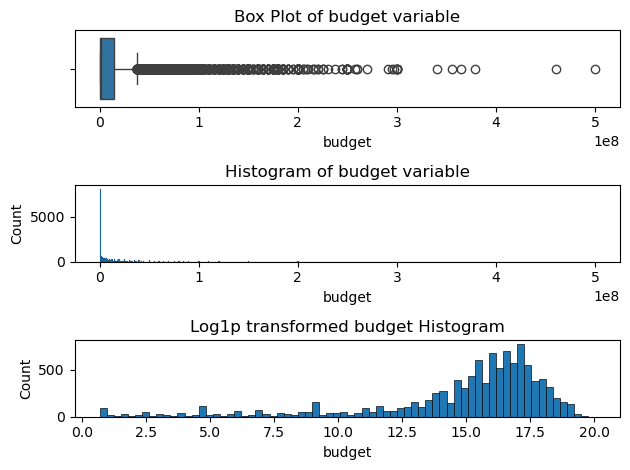

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.budget, ax = ax[0])
ax[0].set_title("Box Plot of budget variable")
sns.histplot(data=df, x='budget', kde = False, ax = ax[1], alpha=1)
ax[1].set_title("Histogram of budget variable")
log_budget = np.log1p(df.budget[df.budget > 0])
sns.histplot(data=log_budget, kde = False, ax = ax[2], alpha=1)
ax[2].set_title("Log1p transformed budget Histogram")
f.tight_layout()

We will take a look at the movies that have too high of a budget

In [ ]:
rslt_tr = df.loc[df['budget'] >= 500000000]
rslt_tr

,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,...,tuesdayRelease,wednesdayRelease,thursdayRelease,fridayRelease,saturdayRelease,sundayRelease,Winter,Fall,Spring,Summer
371930,168626,DeAD,Comedy-Drama-Thriller,en,Patrick feels absolutely lonely when he decide...,1.96,Skalar Film,2013-02-10,500000000.0,201103001.0,...,0,0,0,0,0,1,1,0,0,0


 As the results are considered unusual, the movies that have excessively large budgets will be removed from the dataframe.

In [ ]:
df = df[df['budget'] < 500000000]

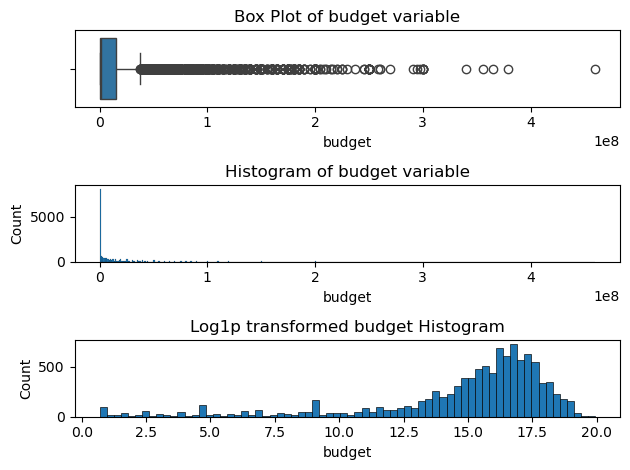

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.budget, ax = ax[0])
ax[0].set_title("Box Plot of budget variable")
sns.histplot(data=df, x='budget', kde = False, ax = ax[1], alpha=1)
ax[1].set_title("Histogram of budget variable")
log_budget = np.log1p(df.budget[df.budget > 0])
sns.histplot(data=log_budget, kde = False, ax = ax[2], alpha=1)
ax[2].set_title("Log1p transformed budget Histogram")
f.tight_layout()

In [ ]:
print('Movies with budget listed as 0: ',(df.budget == 0).sum())

Movies with budget listed as 0:  5547


The budget distribution in the training set is skewed towards higher values, similar to revenue. We also consider the log transformed distribution. Although there are no movies with missing budgets, there are many films in the training set with a budget of 0. This is highly unlikely and probably indicates missing data. To address this, we will replace these 0 values with the median budget to reduce the skew.

In [ ]:
median = df.loc[df['budget'] > 0, 'budget'].median()
df["budget_processed"] = df["budget"].mask(df["budget"] == 0, median)

In [ ]:
df.nsmallest(10, 'budget_processed')['budget_processed']

43274     1.0
50403     1.0
51879     1.0
52386     1.0
56578     1.0
60776     1.0
78538     1.0
84471     1.0
109118    1.0
110299    1.0
Name: budget_processed, dtype: float64

In addition to the values equal to 0, there are other invalid entries in the budget column. To handle this issue, we will replace all budget values below 10,000 USD, as this is considered a reasonable minimum value. It is rare for significant feature films to be made with budgets below 10,000 USD. An example of a successful low-budget film is "Paranormal Activity," which was produced with a budget of approximately 15,000 USD.

In [ ]:
median = df.loc[df['budget'] >= 10000, 'budget'].median()
df["budget_processed"] = df["budget"].mask(df["budget"] < 10000, median)

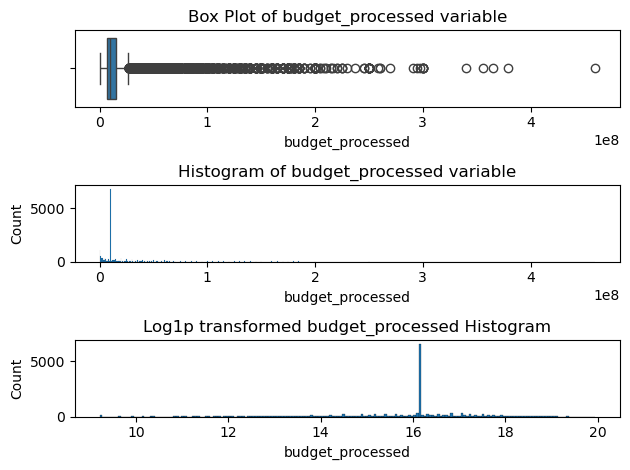

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.budget_processed, ax = ax[0])
ax[0].set_title("Box Plot of budget_processed variable")
sns.histplot(data=df, x='budget_processed', kde = False, ax = ax[1], alpha=1)
ax[1].set_title("Histogram of budget_processed variable")
sns.histplot(data=np.log1p(df.budget_processed), kde = False, ax = ax[2], alpha=1)
ax[2].set_title("Log1p transformed budget_processed Histogram")
f.tight_layout()

#### Bivariate Analysis

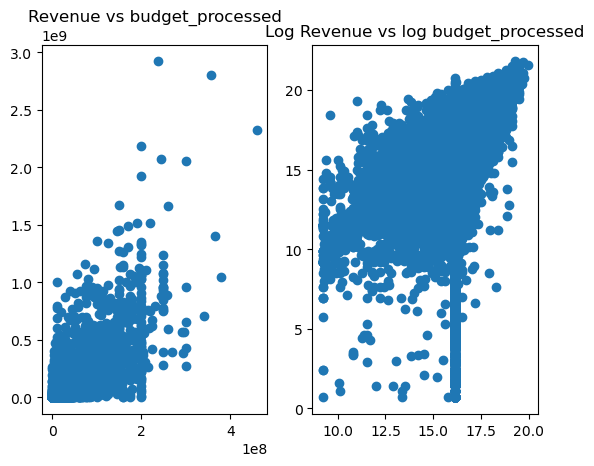

In [ ]:
plt.figure()
plt.subplot(1, 2, 1)
plt.scatter(df['budget_processed'], df['revenue'])
plt.title('Revenue vs budget_processed');
plt.subplot(1, 2, 2)
plt.scatter(np.log1p(df['budget_processed']), np.log1p(df['revenue']))
plt.title('Log Revenue vs log budget_processed');

In [ ]:
corr, _ = pearsonr(df['budget_processed'], df['revenue'])
print('Pearsons correlation between budget_processed and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['budget_processed']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed transformed budget_processed and log transformed revenue: %.3f' % corr)

Pearsons correlation between budget_processed and revenue: 0.747
Pearsons correlation between log transformed transformed budget_processed and log transformed revenue: 0.319


We can see there is a fairly strong correlation between the budget and the revenue variables.

In [ ]:
log_features.append('budget_processed')

### Runtime

The column represents the runtime of the movie, indicating its duration or length in minutes. The runtime of a movie may influence its revenue, as films that are considered either too short or too long could potentially receive less viewership. Although this aspect could spark a discussion on viewers' attention spans when watching a movie, it is not within the scope of the current report.

#### Pre-processing

In [ ]:
print('Movies missing a runtime:', df.runtime.isna().sum())

Movies missing a runtime: 50


In [ ]:
df.runtime = df.runtime.fillna(df.runtime.median())

#### Univariate Analysis

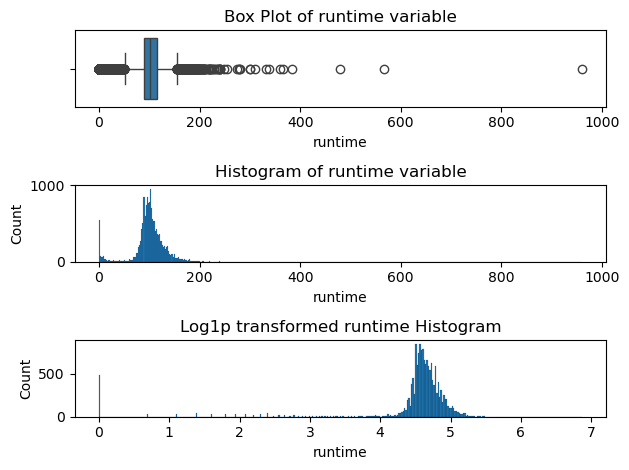

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.runtime, ax = ax[0])
ax[0].set_title("Box Plot of runtime variable")
sns.histplot(data=df, x="runtime", kde=False, ax = ax[1], alpha=1)
ax[1].set_title("Histogram of runtime variable")
sns.histplot(data=df, x=np.log1p(df.runtime), kde=False, ax = ax[2], alpha=1)
ax[2].set_title("Log1p transformed runtime Histogram")
f.tight_layout()

The runtime distribution appears satisfactory, but there are several outliers on the higher end. To handle these outliers, we can apply log transformation. However, it's worth noting that there are movies with a runtime longer than 400 minutes. Therefore, we will examine these particular outliers separately.

In [ ]:
df.loc[df['runtime'] > 400, ['title', 'runtime', 'revenue']]

,title,runtime,revenue
26084,Shoah,566.0,20175.0
38001,Live Aid,960.0,150000000.0
302124,2019: A Cinematic Odyssey,480.0,100000.0


All of the excessively long movies did not perform well in the box office with the exception Live Aid, which has an outlandishly high revenue instead. Therefore, they will be removed from the dataset as they do not contribute positively to our model.

In [ ]:
df = df[df['runtime'] <= 400]

In [ ]:
print('Movies with runtime listed as 0: ',(df.runtime == 0).sum())

Movies with runtime listed as 0:  484


Since it is incorrect for movies to have a runtime listed as 0, we will replace these values with the median of the non-zero runtimes in the dataset.

In [ ]:
median = df.loc[df['runtime'] > 0, 'runtime'].median()
df["runtime_processed"] = df["runtime"].mask(df["runtime"] == 0, median)

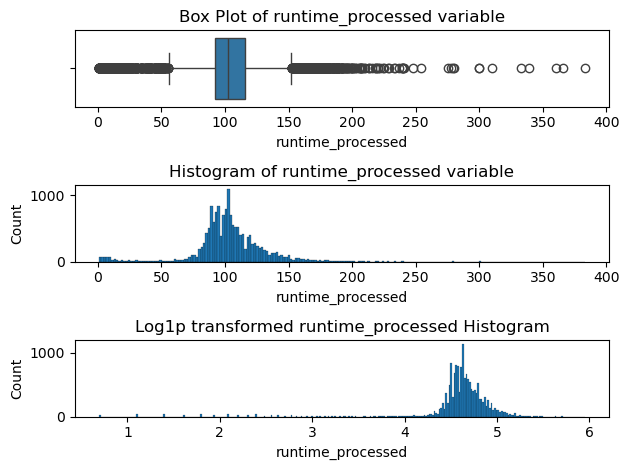

In [ ]:
f, ax = plt.subplots(3)

sns.boxplot(x=df.runtime_processed, ax = ax[0])
ax[0].set_title("Box Plot of runtime_processed variable")
sns.histplot(data=df, x="runtime_processed", kde=False, ax = ax[1], alpha=1)
ax[1].set_title("Histogram of runtime_processed variable")
sns.histplot(data=df, x=np.log1p(df.runtime_processed), kde=False, ax = ax[2], alpha=1)
ax[2].set_title("Log1p transformed runtime_processed Histogram")
f.tight_layout()

The distribution appears to be significantly improved, particularly after applying the log transformation, which will make it easier to work with.

#### Bivariate Analysis

Text(0.5, 1.0, 'Log Revenue vs log runtime_processed')

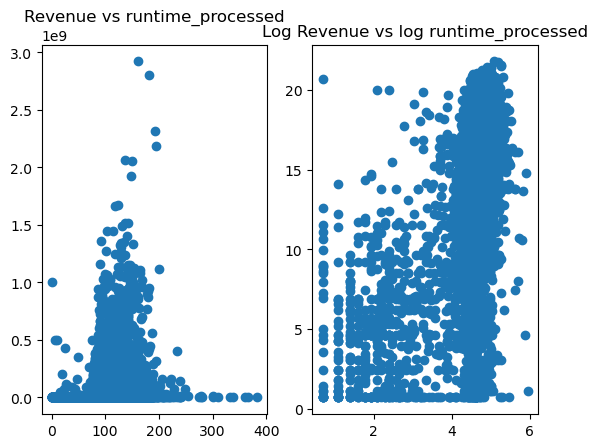

In [ ]:
plt.figure()
plt.subplot(1, 2, 1)
plt.scatter(df['runtime_processed'], df['revenue'])
plt.title('Revenue vs runtime_processed');
plt.subplot(1, 2, 2)
plt.scatter(np.log1p(df['runtime_processed']), np.log1p(df['revenue']))
plt.title('Log Revenue vs log runtime_processed')

In [ ]:
corr, _ = pearsonr(df['runtime_processed'], df['revenue'])
print('Pearsons correlation between runtime and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['runtime_processed']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed runtime and log transformed revenue: %.3f' % corr)

Pearsons correlation between runtime and revenue: 0.179
Pearsons correlation between log transformed runtime and log transformed revenue: 0.470


Given that we have observed a slight positive correlation between the duration of a film and its revenue, it would be beneficial to incorporate this relationship into our model.

In [ ]:
log_features.append('runtime_processed')

### Tagline

The tagline column in our dataset consists of a brief, catchy phrase that encapsulates the essence of each movie. Although the tagline content may be intriguing for specific types of analyses, it falls beyond the scope of our current project.

In [ ]:
df.tagline.head(10)

0                                    Back for seconds.
1    Inspired by the actual files of Father Gabriel...
2                                       Come together.
3                                       Unite or fall.
4                              Long live the fighters.
5                             'Til death do they part.
6              Witness the beginning of a new dynasty.
7                        You can't run from your past.
8                          It ends where it all began.
9            Things just got a little more despicable.
Name: tagline, dtype: object

#### Univariate Analysis

In [ ]:
print('Movies missing a tagline:', df.tagline.isna().sum())

Movies missing a tagline: 5007



Instead of analyzing the content of the tagline, our focus will be on determining whether a movie has a tagline or not.

In [ ]:
df['has_tagline'] = df.tagline.apply(lambda x: 1 if type(x) == str else 0)

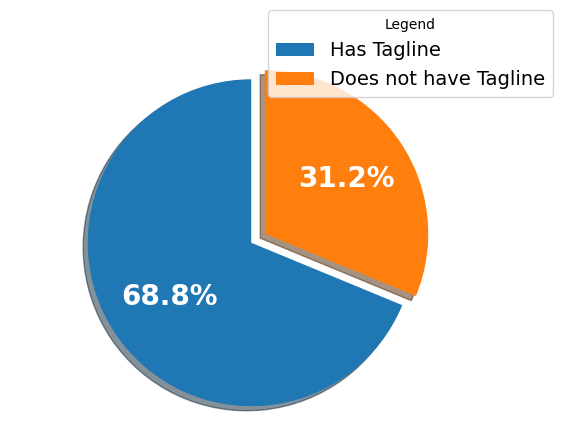

In [ ]:
labels = 'Has Tagline', 'Does not have Tagline'
btc_1 = [(df.has_tagline == 1).sum(axis=0), (df.has_tagline == 0).sum(axis=0)]
explode = (0.1, 0)

fig, ax = plt.subplots()
ax.pie(btc_1, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'color':"w", 'fontsize': 20, 'weight':"bold"})
ax.axis('equal')

ax.legend(labels, title="Legend", loc="center left", fontsize=14, bbox_to_anchor=(0.5, 0.5, 0.5, 1))

#### Bivariate Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\1998232651.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, 'Does not have tagline'), Text(1, 0, 'Has tagline')]

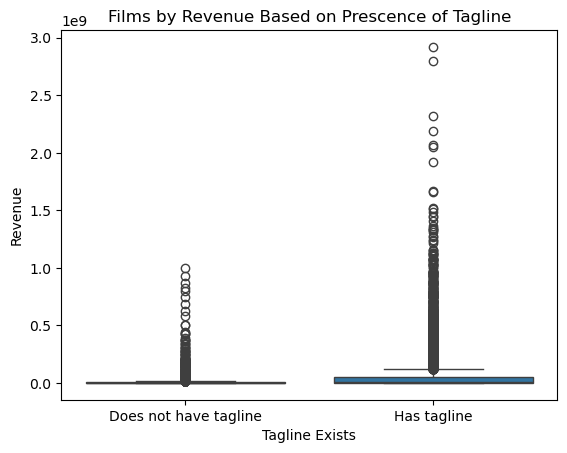

In [ ]:
ax = sns.boxplot(x='has_tagline', y='revenue', data=df)
plt.title('Films by Revenue Based on Prescence of Tagline')
plt.ylabel("Revenue")
plt.xlabel("Tagline Exists")
labels = 'Does not have tagline', 'Has tagline'
ax.set_xticklabels(labels)

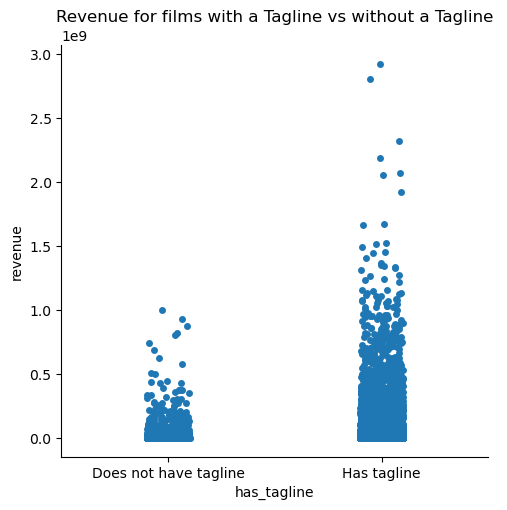

In [ ]:
ax = sns.catplot(x='has_tagline', y='revenue', data=df);
plt.title('Revenue for films with a Tagline vs without a Tagline');

labels = 'Does not have tagline', 'Has tagline'
ax.set_xticklabels(labels)

In [ ]:
corr, _ = pearsonr(df['has_tagline'], df['revenue'])
print('Pearsons correlation between has_tagline and revenue: %.3f' % corr)
corr, _ = pearsonr(df['has_tagline'], np.log1p(df['revenue']))
print('Pearsons correlation between has_tagline and log transformed revenue: %.3f' % corr)

Pearsons correlation between has_tagline and revenue: 0.178
Pearsons correlation between has_tagline and log transformed revenue: 0.308


We have observed a positive correlation between the presence of a tagline and the revenue generated by a film.

In [ ]:
df_features.append('has_tagline')

### Vote Average

In [ ]:
df['vote_average'].head()

0    7.079
1    7.433
2    7.765
3    7.340
4    8.300
Name: vote_average, dtype: float64

In [ ]:
print("Movies misssing average vote: ",df['vote_average'].isna().sum())

Movies misssing average vote:  0


#### Univariate Analysis

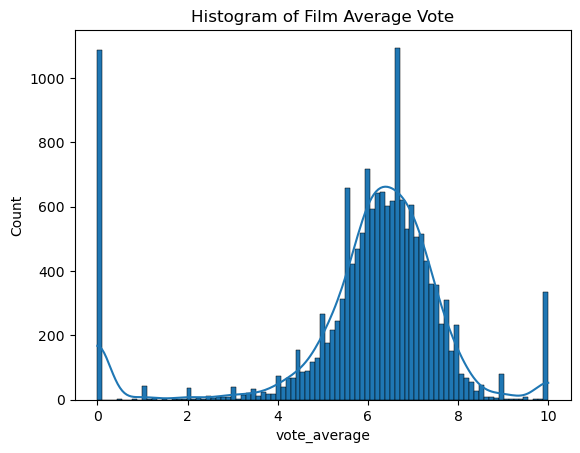

In [ ]:
sns.histplot(df['vote_average'], kde=True, alpha=1)
plt.title('Histogram of Film Average Vote')
plt.show()

In [ ]:
print(df['vote_average'].describe())

count    16029.000000
mean         5.978412
std          1.975969
min          0.000000
25%          5.600000
50%          6.300000
75%          7.000000
max         10.000000
Name: vote_average, dtype: float64


#### Bivariate Analysis

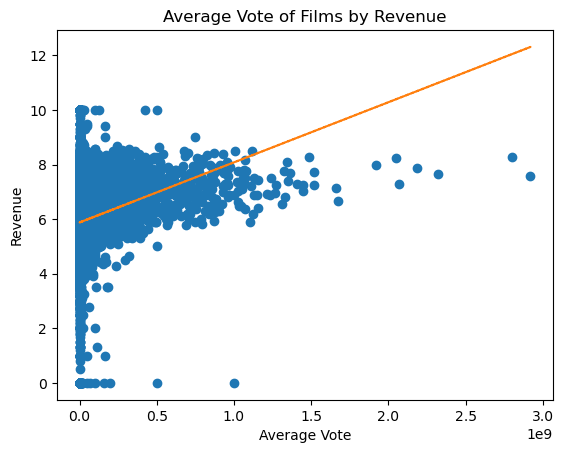

In [ ]:
cx = df['revenue']
pop = df['vote_average']
plt.plot(cx, pop, 'o')
plt.ylabel("Revenue")
plt.xlabel("Average Vote")
plt.title("Average Vote of Films by Revenue")

z = np.polyfit(cx, pop, 1)
p = np.poly1d(z)
plt.plot(cx, p(cx), "--");

In [ ]:
corr, _ = pearsonr(df['vote_average'], df['revenue'])
print('Pearsons correlation between average vote and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['vote_average']), np.log1p(df['revenue']))
print('Pearsons correlation between log average vote and log revenue: %.3f' % corr)

Pearsons correlation between average vote and revenue: 0.144
Pearsons correlation between log average vote and log revenue: 0.407


Considering that we have identified a modest positive correlation between the average vote and the revenue of a film, it would be advantageous to include this relationship in our model.

In [ ]:
log_features.append('vote_average')

### Vote Count

In [ ]:
df['vote_count'].head()

0    1365.0
1     545.0
2    3749.0
3    1007.0
4    2770.0
Name: vote_count, dtype: float64

In [ ]:
print("Movies misssing count vote: ",df['vote_count'].isna().sum())

Movies misssing count vote:  0


#### Univariate Analysis

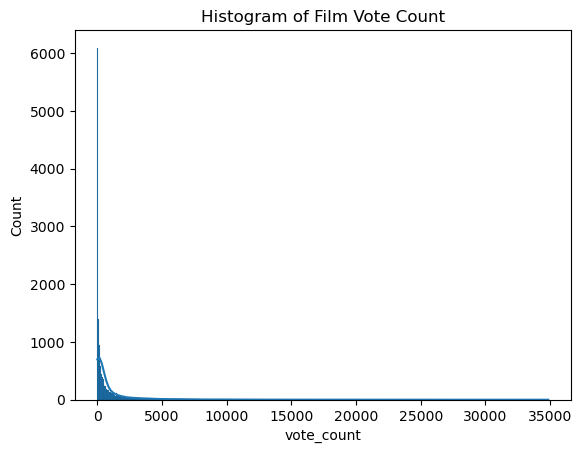

In [ ]:
sns.histplot(df['vote_count'], kde=True, alpha=1)

plt.title('Histogram of Film Vote Count')
plt.show()

In [ ]:
print(df['vote_count'].describe())

count    16029.000000
mean       991.793749
std       2448.369543
min          0.000000
25%         17.000000
50%        150.000000
75%        775.000000
max      34857.000000
Name: vote_count, dtype: float64


#### Bivariate Analysis

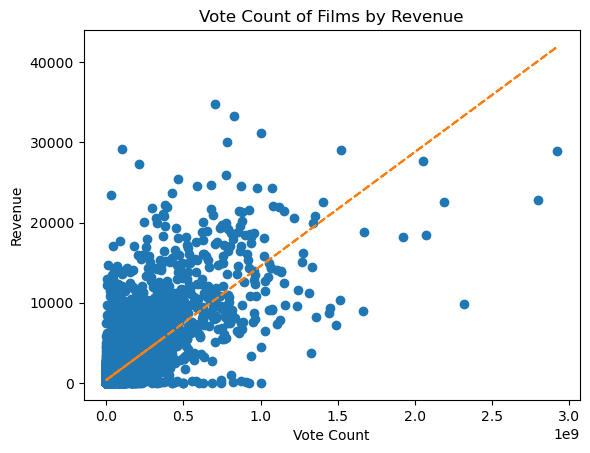

In [ ]:
cx = df['revenue']
pop = df['vote_count']
plt.plot(cx, pop, 'o')
plt.ylabel("Revenue")
plt.xlabel("Vote Count")
plt.title("Vote Count of Films by Revenue")

z = np.polyfit(cx, pop, 1)
p = np.poly1d(z)
plt.plot(cx, p(cx), "--");

In [ ]:
corr, _ = pearsonr(df['vote_count'], df['revenue'])
print('Pearsons correlation between vote count and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['vote_count']), np.log1p(df['revenue']))
print('Pearsons correlation between log vote count and log revenue: %.3f' % corr)

Pearsons correlation between vote count and revenue: 0.750
Pearsons correlation between log vote count and log revenue: 0.720


Since we have observed a positive correlation between the number of votes a film receives and its revenue, it would be advantageous to incorporate this relationship into our model.

In [ ]:
df_features.append('vote_count')

### Credits

The credits column contains information about the entire cast of the movie, including all the characters that appear in the film. This variable holds significant importance because certain actors/actresses have strong reputations, and their mere presence can attract a large audience. We will investigate this variable and develop a method to quantify the star power or name recognition associated with the credits.

In [ ]:
df.credits.head(10)

0    Jason Statham-Wu Jing-Shuya Sophia Cai-Sergio ...
1    Russell Crowe-Daniel Zovatto-Alex Essoe-Franco...
2    Ryan Reynolds-Hugh Jackman-Emma Corrin-Matthew...
3    Anthony Ramos-Dominique Fishback-Luna Lauren V...
4    Timothée Chalamet-Zendaya-Rebecca Ferguson-Jav...
5    Tom Hardy-Chiwetel Ejiofor-Juno Temple-Clark B...
6    Paul Rudd-Evangeline Lilly-Jonathan Majors-Kat...
7    Michael B. Jordan-Tessa Thompson-Jonathan Majo...
8    Ty Simpkins-Patrick Wilson-Sinclair Daniel-Ros...
9    Steve Carell-Kristen Wiig-Will Ferrell-Sofía V...
Name: credits, dtype: object

In order to work with this data, we will utilize a regular expression to extract the names of the actors/actresses in the credits.

#### Pre-processing

In [ ]:
print('Movies missing credits:', df.credits.isna().sum())

Movies missing credits: 245


In [ ]:
df['credits'] = df['credits'].fillna("")
df['credits_processed'] = df['credits'].str.split('-')

In [ ]:
df['num_credits'] = df['credits_processed'].apply(lambda x: len(x))
df['num_credits'].value_counts()

num_credits
15     497
1      471
14     469
16     461
18     461
      ... 
159      1
179      1
129      1
189      1
132      1
Name: count, Length: 178, dtype: int64

In [ ]:
median = df.loc[df['num_credits']> 0, 'num_credits'].median()
df["num_credits"] = df["num_credits"].mask(df["num_credits"] == 0, median)

#### Univariate Analysis

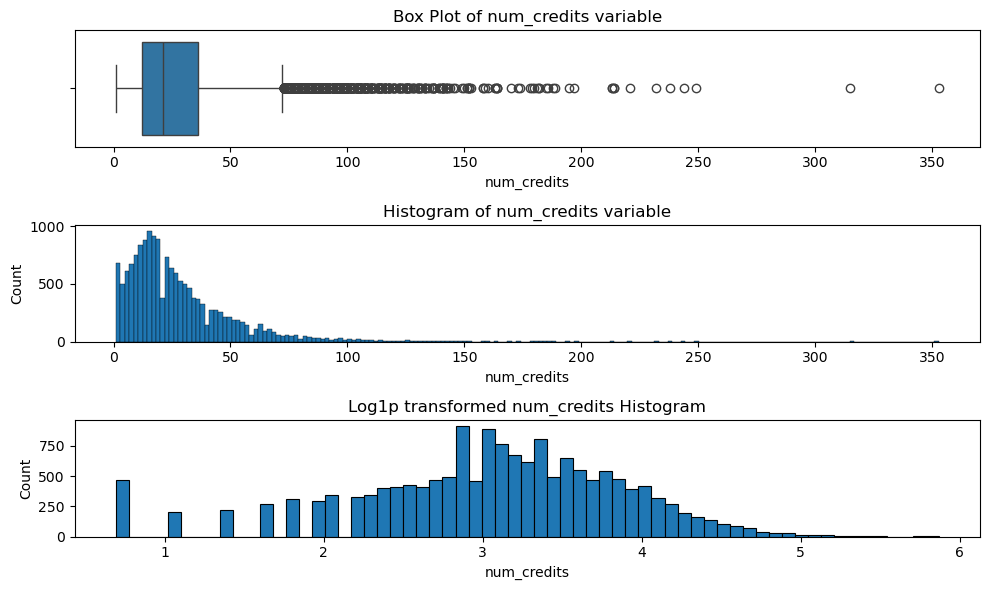

In [ ]:
f, ax = plt.subplots(3, figsize=(10,6))

sns.boxplot(x=df.num_credits, ax = ax[0])
ax[0].set_title("Box Plot of num_credits variable")

sns.histplot(data=df, x='num_credits', kde=False, ax=ax[1], alpha=1)
ax[1].set_title("Histogram of num_credits variable")

sns.histplot(data=df, x=np.log1p(df.num_credits), kde=False, ax=ax[2], alpha=1)
ax[2].set_title("Log1p transformed num_credits Histogram")

f.tight_layout()

The distribution of the number of credited actors/actresses in a film appears to be satisfactory and even improves further after applying a logarithmic transformation. This prompts us to delve deeper into the various aspects associated with the cast variable for further exploration and analysis.

<Axes: >

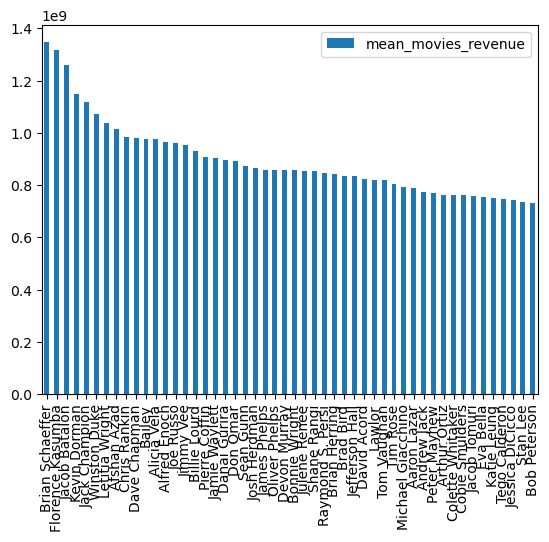

In [ ]:
actorsDict = {}
for element in df[["revenue", "credits_processed"]].values:

    for actor in element[1]:
        if actor not in actorsDict:
            actorsDict[actor] = [element[0], 1]
        else:
            actorsDict[actor][0] += element[0]
            actorsDict[actor][1] += 1

actorsDict = {k: v for k, v in actorsDict.items() if v[1] >= 5}

for actor in actorsDict:
    actorsDict[actor][0] = actorsDict[actor][0]/actorsDict[actor][1]
    actorsDict[actor] = actorsDict[actor][0]




actors_df = pd.DataFrame.from_dict(actorsDict, orient='index', columns=["mean_movies_revenue"])
actors_df.sort_values(by="mean_movies_revenue", ascending=False).head(50).plot.bar()

This plot represents the top 50 credited actors/actresses based on their average box office revenue. However, it is important to note that this list may not be entirely reliable as it includes all actors/actresses in the cast, including those with cameo appearances. As evident from the plot, Jacob Batalon ranks at the top of the list despite never having a leading role in any movie, surpassing more prominent actors/actresses. To ensure a more accurate reflection of the top actors, we need to apply filtering techniques to refine the list.

In [ ]:
actorsDict = {}
for element in df[["revenue", "credits_processed"]].values:
    temp = 5
    if len(element[1]) < temp:
        temp = len(element[1])
    for i in range(temp):
        if element[1][i] not in actorsDict:
            actorsDict[element[1][i]] = [element[0], 1]
        else:
            actorsDict[element[1][i]][0] += element[0]
            actorsDict[element[1][i]][1] += 1

actorsDict = {k: v for k, v in actorsDict.items() if v[1] >= 5}


for actor in actorsDict:
    actorsDict[actor][0] = actorsDict[actor][0]/actorsDict[actor][1]
    actorsDict[actor] = actorsDict[actor][0]

actors_df = pd.DataFrame.from_dict(actorsDict, orient='index', columns=["mean_movies_revenue"])
actors_df.sort_values(by="mean_movies_revenue", ascending=False).head(50)

,mean_movies_revenue
Daisy Ridley,7.508299e+08
Miranda Cosgrove,6.855991e+08
Zendaya,6.693518e+08
Rupert Grint,6.425913e+08
Richard Armitage,6.197610e+08
Chris Hemsworth,5.766814e+08
Evangeline Lilly,5.746081e+08
Emma Watson,5.737431e+08
Benedict Cumberbatch,5.508172e+08
Carrie Fisher,5.441060e+08


<Axes: >

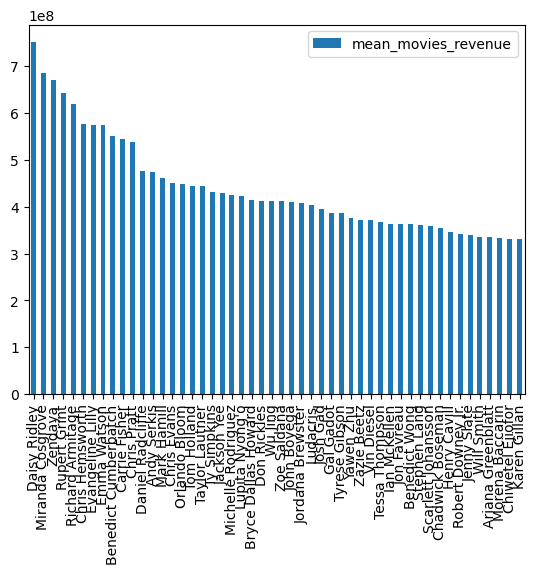

In [ ]:
actors_df.sort_values(by="mean_movies_revenue", ascending=False).head(50).plot.bar()

By limiting the list to actors who have appeared in 5 or more films, we obtain more accurate results. However, this approach still raises concerns regarding the ranking of certain actors. For instance, Rupert Grint is listed as one of the highest-earning actors, but his fame and recognition may not be on par with more prominent actors he has co-starred with, like Daniel Radcliffe in the Harry Potter movie saga. Daniel Radcliffe has a more substantial presence in the film industry and is widely acknowledged as a top actor. Consequently, there is a valid argument as to whether Grint deserves such a high ranking in terms of box office revenue for that specific movie. To address this issue, we will create an additional list that considers only the top actors mentioned for each film, particularly those in lead roles.

<Axes: >

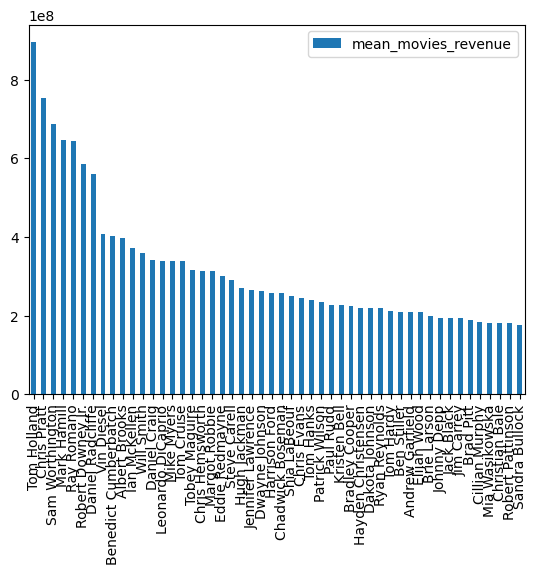

In [ ]:
leadActorsDict = {}
for element in df[["revenue", "credits_processed"]].values:
    temp = 1
    if len(element[1]) < temp:
        temp = len(element[1])
    for i in range(temp):
        if element[1][i] not in leadActorsDict:
            leadActorsDict[element[1][i]] = [element[0], 1]
        else:
            leadActorsDict[element[1][i]][0] += element[0]
            leadActorsDict[element[1][i]][1] += 1

leadActorsDict = {k: v for k, v in leadActorsDict.items() if v[1] >= 5}

for actor in leadActorsDict:
    leadActorsDict[actor][0] = leadActorsDict[actor][0]/leadActorsDict[actor][1]
    leadActorsDict[actor] = leadActorsDict[actor][0]

actors_df = pd.DataFrame.from_dict(leadActorsDict, orient='index', columns=["mean_movies_revenue"])
actors_df.sort_values(by="mean_movies_revenue", ascending=False).head(50).plot.bar()

The plot exhibits the top 50 lead actors, well-known for starring in successful films, particularly major action hits. This information serves as a valuable feature, quantifying an actor's reputation based on their association with prosperous movies. We will create two features: a binary variable indicating whether the lead actor is among the "top lead actors," and a count of "top actors" within the movie's cast, considering the top 5 actors based on significant roles, not cameos. To classify a "top actor," we consider actors ranked within the top 50 for lead roles and top 100 overall, based on their average box office revenue from previous films.

In [ ]:
leadActorsDict = {k: v for k, v in sorted(leadActorsDict.items(), key=lambda item: item[1], reverse = True)}
actorsDict = {k: v for k, v in sorted(actorsDict.items(), key=lambda item: item[1], reverse = True)}

In [ ]:
def checkLeadActor(credits):
    if len(credits) < 1 or credits[0] not in list(leadActorsDict)[:50]:
        return 0
    else:
        return 1

df['topLeadActor'] = df['credits_processed'].apply(lambda x: checkLeadActor(x))
print(df['topLeadActor'].value_counts())

topLeadActor
0    15305
1      724
Name: count, dtype: int64


In [ ]:
def checkTopActors(credits):
    if len(credits) < 1:
        return 0
    count = 0
    for actor in credits[:10]:
        if actor in list(actorsDict)[:100]:
            count += 1
    return count

df['numTopActors'] = df['credits_processed'].apply(lambda x: checkTopActors(x))
print(df['numTopActors'].value_counts())

numTopActors
0    14743
1     1049
2      151
3       44
4       20
5       11
6        6
7        3
9        1
8        1
Name: count, dtype: int64


In [ ]:
def getActorRanks(credits):
    if len(credits) < 1:
        return len(actorsDict)
    rank = 0
    for a in credits[:5]:
        if a in list(actorsDict):
            rank += list(actorsDict.keys()).index(a)
    if rank == 0:
        rank = len(actorsDict)
    return rank / len(credits)

df['actorRanks'] = df['credits_processed'].apply(lambda x: getActorRanks(x))
print(df['actorRanks'].value_counts())

actorRanks
2756.000000    245
631.200000     229
789.000000     203
450.857143     198
3156.000000    187
              ... 
130.285714       1
248.000000       1
184.433333       1
285.642857       1
307.300000       1
Name: count, Length: 11136, dtype: int64


In [ ]:
def getTopActorRank(credits):
    if len(credits) < 1:
        return len(leadActorsDict)
    if credits[0] in list(leadActorsDict):
        rank = list(leadActorsDict.keys()).index(credits[0])
    else:
        rank = len(leadActorsDict)
    return rank

df['topActorRank'] = df['credits_processed'].apply(lambda x: getTopActorRank(x))
print(df['topActorRank'].value_counts())

topActorRank
605    9521
524     245
169      60
225      44
28       42
       ... 
591       5
167       5
514       5
408       5
458       5
Name: count, Length: 606, dtype: int64


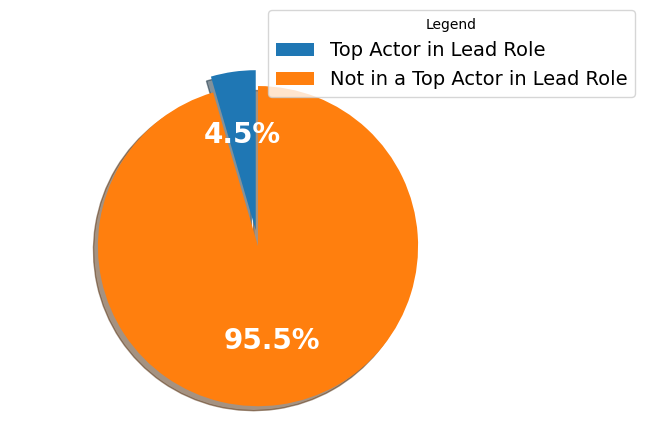

In [ ]:
labels = 'Top Actor in Lead Role', 'Not in a Top Actor in Lead Role'
btc_1 = [sum(df.topLeadActor), (df.topLeadActor == 0).sum(axis=0)]
explode = (0.1, 0)

fig, ax = plt.subplots()
plt.pie(btc_1, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'color':"w", 'fontsize': 20, 'weight':"bold"})
plt.axis('equal')

ax.legend(labels, title="Legend", loc="center left", fontsize=14, bbox_to_anchor=(0.5, 0.5, 0.5, 1))

plt.show()

<Axes: xlabel='numTopActors', ylabel='count'>

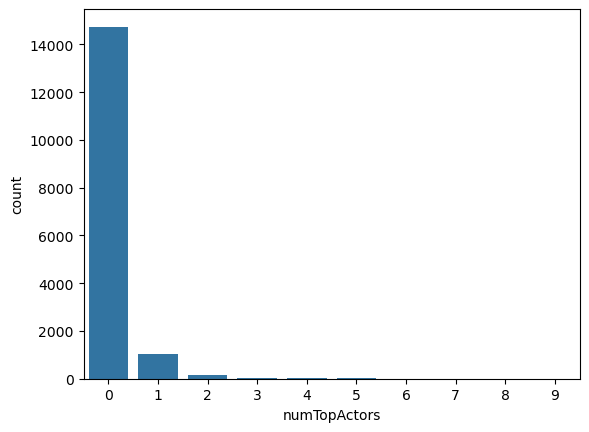

In [ ]:
sns.countplot(x=df.numTopActors)

Bivariate Analysis

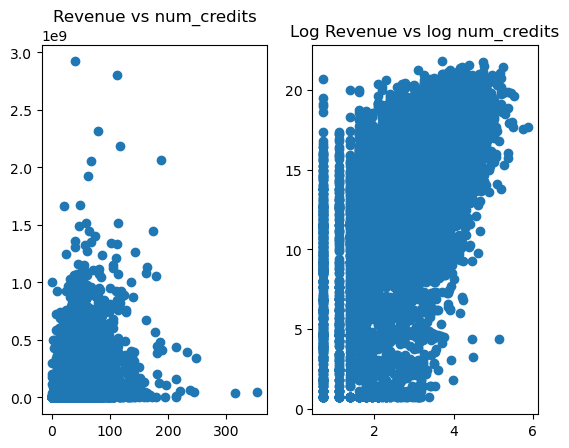

In [ ]:
plt.figure()
plt.subplot(1, 2, 1)
plt.scatter(df['num_credits'], df['revenue'])
plt.title('Revenue vs num_credits');
plt.subplot(1, 2, 2)
plt.scatter(np.log1p(df['num_credits']), np.log1p(df['revenue']))
plt.title('Log Revenue vs log num_credits');

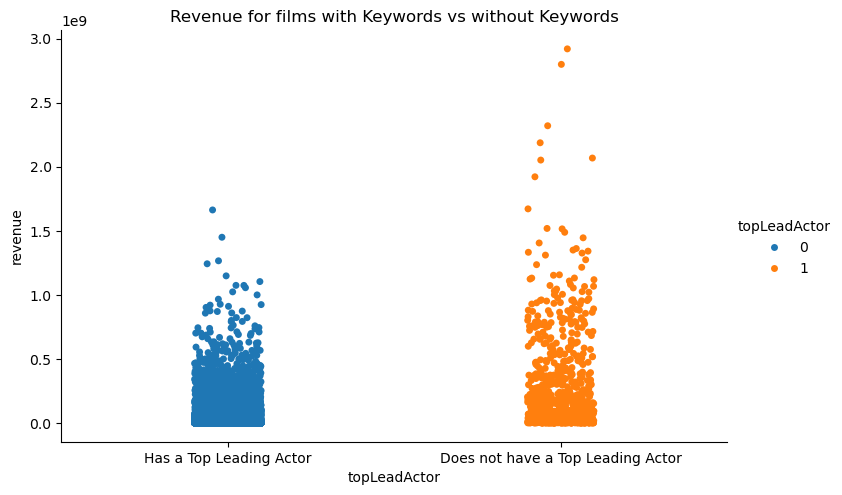

In [ ]:
ax = sns.catplot(x='topLeadActor', y='revenue', data=df, hue='topLeadActor', aspect=1.5);
plt.title('Revenue for films with Keywords vs without Keywords');

labels = 'Has a Top Leading Actor', 'Does not have a Top Leading Actor'
ax.set_xticklabels(labels)

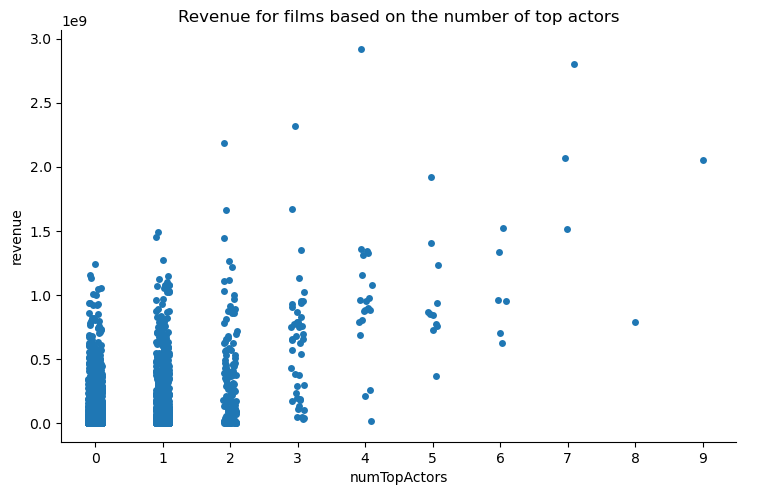

In [ ]:
sns.catplot(x='numTopActors', y='revenue', data=df, aspect=1.5);
plt.title('Revenue for films based on the number of top actors');

In [ ]:
corr, _ = pearsonr(df['num_credits'], df['revenue'])
print('Pearsons correlation between num_credits and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['num_credits']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed num_credits and  log transformed revenue: %.3f' % corr)

Pearsons correlation between num_credits and revenue: 0.370
Pearsons correlation between log transformed num_credits and  log transformed revenue: 0.600


In [ ]:
corr, _ = pearsonr(df['topLeadActor'], df['revenue'])
print('Pearsons correlation between topLeadActor and revenue: %.3f' % corr)
corr, _ = pearsonr(df['topLeadActor'], np.log1p((df['revenue'])))
print('Pearsons correlation between topLeadActor and log transformed revenue: %.3f' % corr)

Pearsons correlation between topLeadActor and revenue: 0.419
Pearsons correlation between topLeadActor and log transformed revenue: 0.203


In [ ]:
corr, _ = pearsonr(df['numTopActors'], df['revenue'])
print('Pearsons correlation between numTopActors and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['numTopActors']), np.log1p((df['revenue'])))
print('Pearsons correlation between log transformed numTopActors and log transformed revenue: %.3f' % corr)

Pearsons correlation between numTopActors and revenue: 0.561
Pearsons correlation between log transformed numTopActors and log transformed revenue: 0.244


In [ ]:
corr, _ = pearsonr(df['actorRanks'], df['revenue'])
print('Pearsons correlation between actorRanks and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['actorRanks']), np.log1p((df['revenue'])))
print('Pearsons correlation between log transformed actorRanks and log transformed revenue: %.3f' % corr)

Pearsons correlation between actorRanks and revenue: -0.156
Pearsons correlation between log transformed actorRanks and log transformed revenue: -0.541


In [ ]:
corr, _ = pearsonr(df['topActorRank'], df['revenue'])
print('Pearsons correlation between topActorRank and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['topActorRank']), np.log1p((df['revenue'])))
print('Pearsons correlation between log transformed topActorRank and log transformed revenue: %.3f' % corr)

Pearsons correlation between topActorRank and revenue: -0.386
Pearsons correlation between log transformed topActorRank and log transformed revenue: -0.395


After analyzing the data, we observed that there are some variables that have a positive correlation with the revenue of the movies, while others have a negative correlation. The number of top actors in a film had the strongest positive correlation, which makes sense because movies featuring several big-name stars tend to perform well based on the cast alone. Similarly, we found positive correlations between the number of credits and the revenue, as well as the presence of a top lead actor in the movie. However, we also observed negative correlations between the rank of actors and the revenue. Therefore, we will only include the variables with positive correlations in our model as they are more likely to have a significant impact on the movie's revenue.

In [ ]:
log_features.append('num_credits')
df_features.append('topLeadActor')
log_features.append('numTopActors')
cols_to_drop.append('actorRanks')
cols_to_drop.append('topActorRank')

### Keywords

The keywords column in our dataset contains relevant terms or concepts associated with each film, which are intended to aid in searchability and describe the movie. Although we won't analyze the specific keywords themselves, their presence could potentially enhance the discoverability of a movie, making it more accessible and increasing its revenue-generating potential.

In [ ]:
df.keywords.head(10)

0                  based on novel or book-sequel-kaiju
1    spain-rome italy-vatican-pope-pig-possession-c...
2    hero-superhero-anti hero-mutant-breaking the f...
3    peru-alien-end of the world-based on cartoon-b...
4    epic-based on novel or book-fight-sandstorm-sa...
5    hero-superhero-anti hero-villain-alien life-fo...
6    hero-ant-sequel-superhero-based on comic-famil...
7    philadelphia pennsylvania-husband wife relatio...
8    sequel-demon-franchise-insidious-supernatural ...
9    superhero-villain-sequel-super villain-illumin...
Name: keywords, dtype: object

#### Univariate Analysis

In [ ]:
print('Movies missing keywords:', df.keywords.isna().sum())

Movies missing keywords: 2763


In [ ]:
df['has_keywords'] = df.keywords.apply(lambda x: 1 if type(x) == str else 0)

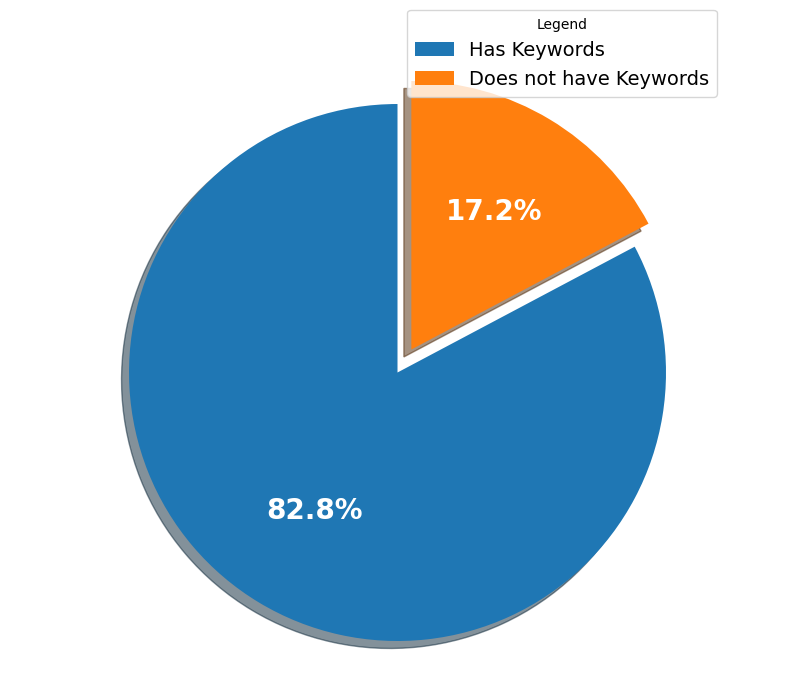

In [ ]:
labels = 'Has Keywords', 'Does not have Keywords'
btc_1 = [sum(df.has_keywords), (df.has_keywords == 0).sum(axis=0)]
explode = (0.1, 0)

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(btc_1, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'color':"w", 'fontsize': 20, 'weight':"bold"})
ax.axis('equal')

ax.legend(labels, title="Legend", loc="center left", fontsize=14, bbox_to_anchor=(0.5, 0.5, 0.5, 1))

#### Bivariate Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\719389944.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, 'Does not have keywords'), Text(1, 0, 'Has keywords')]

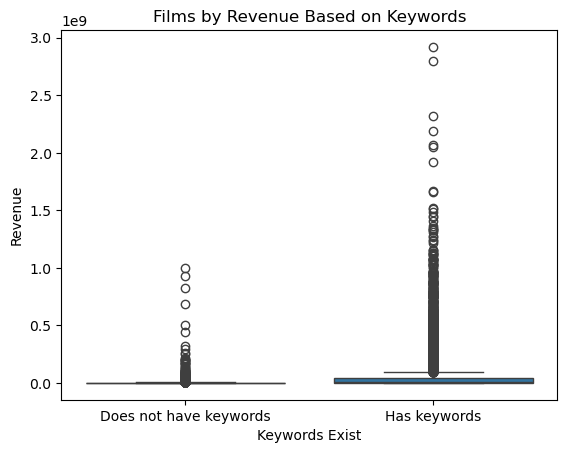

In [ ]:
ax = sns.boxplot(x='has_keywords', y='revenue', data=df)
plt.title('Films by Revenue Based on Keywords')
plt.ylabel("Revenue")
plt.xlabel("Keywords Exist")

labels = 'Does not have keywords', 'Has keywords'
ax.set_xticklabels(labels)

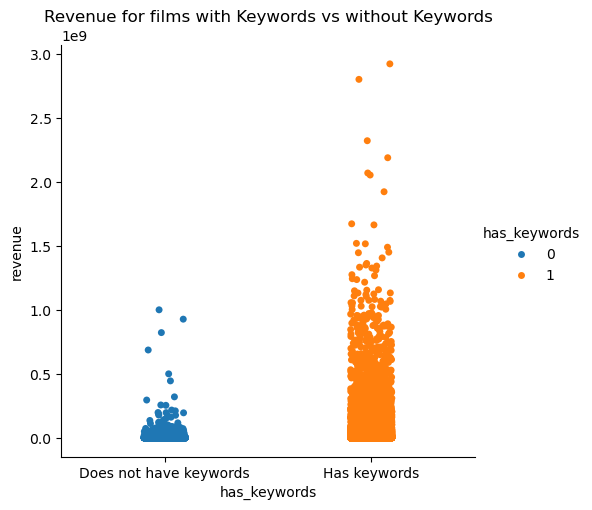

In [ ]:
ax = sns.catplot(x='has_keywords', y='revenue', data=df, hue='has_keywords')
plt.title('Revenue for films with Keywords vs without Keywords')

labels = ['Does not have keywords', 'Has keywords']
ax.set_xticklabels(labels)

In [ ]:
corr, _ = pearsonr(df['has_keywords'], df['revenue'])
print('Pearsons correlation between has_keywords and revenue: %.3f' % corr)
corr, _ = pearsonr(df['has_keywords'], np.log1p(df['revenue']))
print('Pearsons correlation between has_keywords and log_transformed revenue: %.3f' % corr)

Pearsons correlation between has_keywords and revenue: 0.134
Pearsons correlation between has_keywords and log_transformed revenue: 0.331


We have noticed a slight positive correlation between the presence of keywords and the revenue generated by a film.

In [ ]:
df_features.append('has_keywords')

### Poster Path

In [ ]:
df.poster_path.head(10)

0    /4m1Au3YkjqsxF8iwQy0fPYSxE0h.jpg
1    /9JBEPLTPSm0d1mbEcLxULjJq9Eh.jpg
2    /8cdWjvZQUExUUTzyp4t6EDMubfO.jpg
3    /gPbM0MK8CP8A174rmUwGsADNYKD.jpg
4    /czembW0Rk1Ke7lCJGahbOhdCuhV.jpg
5    /aosm8NMQ3UyoBVpSxyimorCQykC.jpg
6    /qnqGbB22YJ7dSs4o6M7exTpNxPz.jpg
7    /cvsXj3I9Q2iyyIo95AecSd1tad7.jpg
8    /azTC5osYiqei1ofw6Z3GmUrxQbi.jpg
9    /wWba3TaojhK7NdycRhoQpsG0FaH.jpg
Name: poster_path, dtype: object

#### Univariate Analysis

In [ ]:
print('Movies missing poster path:', df.poster_path.isna().sum())

Movies missing poster path: 367


In [ ]:
df['has_poster_path'] = df.poster_path.apply(lambda x: 1 if type(x) == str else 0)

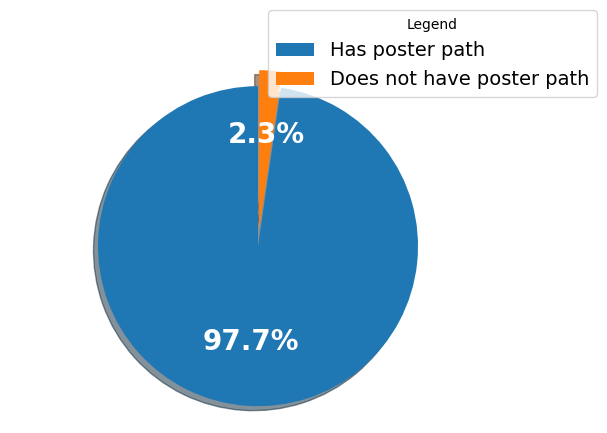

In [ ]:
labels = 'Has poster path', 'Does not have poster path'
btc_1 = [sum(df.has_poster_path), (df.has_poster_path == 0).sum(axis=0)]
explode = (0.1, 0)

fig, ax = plt.subplots()
ax.pie(btc_1, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'color':"w", 'fontsize': 20, 'weight':"bold"})
ax.axis('equal')

ax.legend(labels, title="Legend", loc="center left", fontsize=14, bbox_to_anchor=(0.5, 0.5, 0.5, 1))

#### Bivariate Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\4069017566.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, 'Does not have poster path'), Text(1, 0, 'Has poster path')]

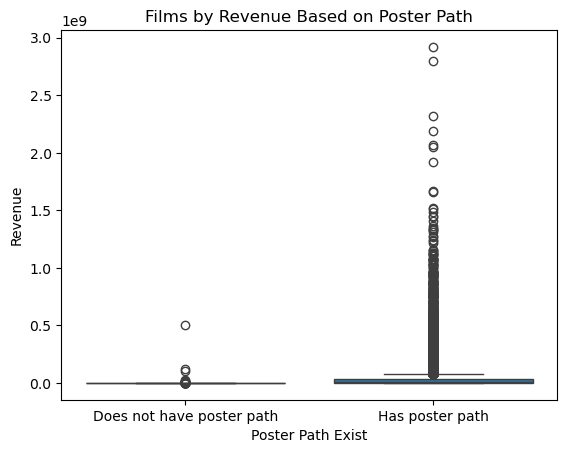

In [ ]:
ax = sns.boxplot(x='has_poster_path', y='revenue', data=df)
plt.title('Films by Revenue Based on Poster Path')
plt.ylabel("Revenue")
plt.xlabel("Poster Path Exist")

labels = 'Does not have poster path', 'Has poster path'
ax.set_xticklabels(labels)

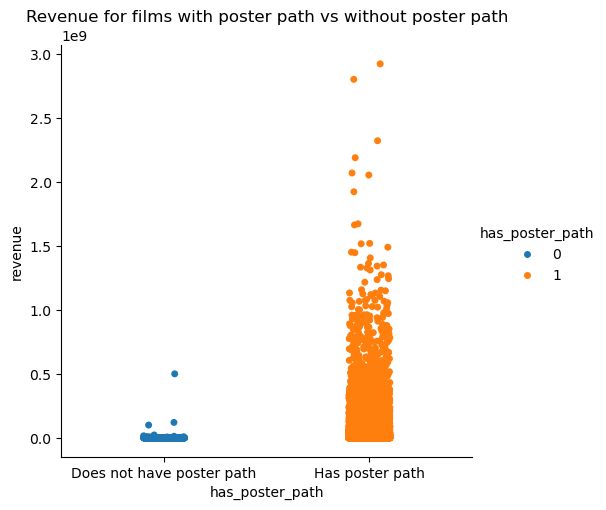

In [ ]:
ax = sns.catplot(x='has_poster_path', y='revenue', data=df, hue='has_poster_path')
plt.title('Revenue for films with poster path vs without poster path')

labels = ['Does not have poster path', 'Has poster path']
ax.set_xticklabels(labels)

In [ ]:
#analysis of correlation and create log feature
corr, _ = pearsonr(df['has_poster_path'], df['revenue'])
print('Pearsons correlation between poster path and revenue: %.3f' % corr)
corr, _ = pearsonr(df['has_poster_path'], np.log1p(df['revenue']))
print('Pearsons correlation between poster path and revenue: %.3f' % corr)

Pearsons correlation between poster path and revenue: 0.050
Pearsons correlation between poster path and revenue: 0.252


We have noticed a slight positive correlation between the presence of a poster path and the revenue generated by a film.

In [ ]:
df_features.append('has_poster_path')

### Backdrop Path

In [ ]:
df.backdrop_path.head(10)

0    /qlxy8yo5bcgUw2KAmmojUKp4rHd.jpg
1    /hiHGRbyTcbZoLsYYkO4QiCLYe34.jpg
2    /dvBCdCohwWbsP5qAaglOXagDMtk.jpg
3    /woJbg7ZqidhpvqFGGMRhWQNoxwa.jpg
4    /xOMo8BRK7PfcJv9JCnx7s5hj0PX.jpg
5    /3V4kLQg0kSqPLctI5ziYWabAZYF.jpg
6    /m8JTwHFwX7I7JY5fPe4SjqejWag.jpg
7    /5i6SjyDbDWqyun8klUuCxrlFbyw.jpg
8    /i2GVEvltEu3BXn5crBSxgKuTaca.jpg
9    /lgkPzcOSnTvjeMnuFzozRO5HHw1.jpg
Name: backdrop_path, dtype: object

#### Univariate Analysis

In [ ]:
print('Movies missing backdrop path:', df.backdrop_path.isna().sum())

Movies missing backdrop path: 1857


In [ ]:
df['has_backdrop_path'] = df.backdrop_path.apply(lambda x: 1 if type(x) == str else 0)

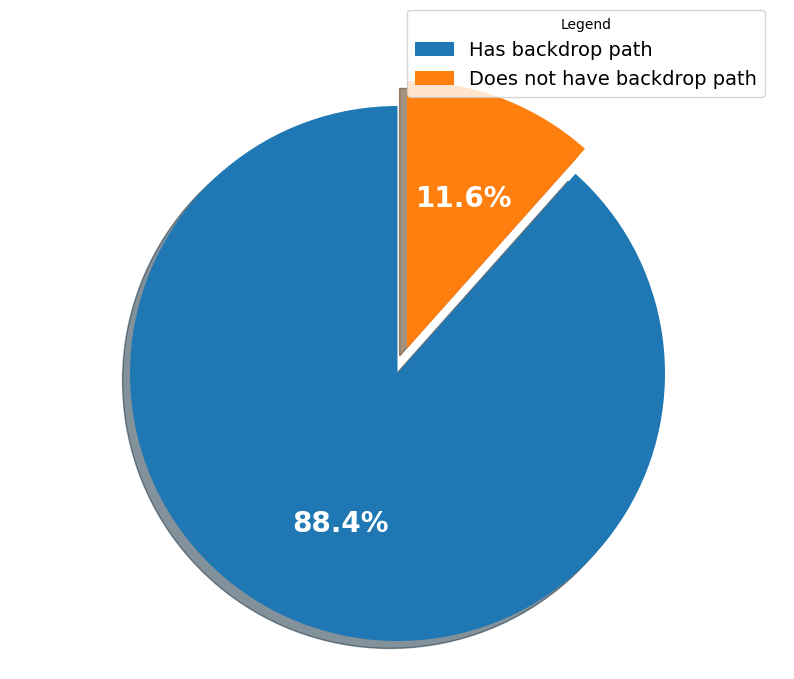

In [ ]:
labels = 'Has backdrop path', 'Does not have backdrop path'
btc_1 = [sum(df.has_backdrop_path), (df.has_backdrop_path == 0).sum(axis=0)]
explode = (0.1, 0)

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(btc_1, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90, textprops={'color':"w", 'fontsize': 20, 'weight':"bold"})
ax.axis('equal')

ax.legend(labels, title="Legend", loc="center left", fontsize=14, bbox_to_anchor=(0.5, 0.5, 0.5, 1))

#### Bivariate Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\3236818338.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, 'Does not have backdrop path'), Text(1, 0, 'Has backdrop path')]

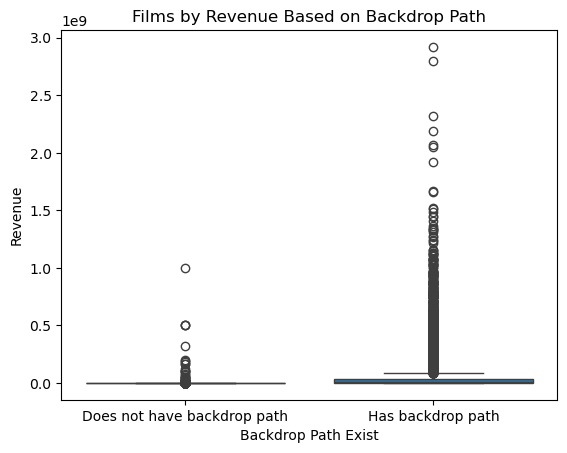

In [ ]:
ax = sns.boxplot(x='has_backdrop_path', y='revenue', data=df)
plt.title('Films by Revenue Based on Backdrop Path')
plt.ylabel("Revenue")
plt.xlabel("Backdrop Path Exist")

labels = 'Does not have backdrop path', 'Has backdrop path'
ax.set_xticklabels(labels)

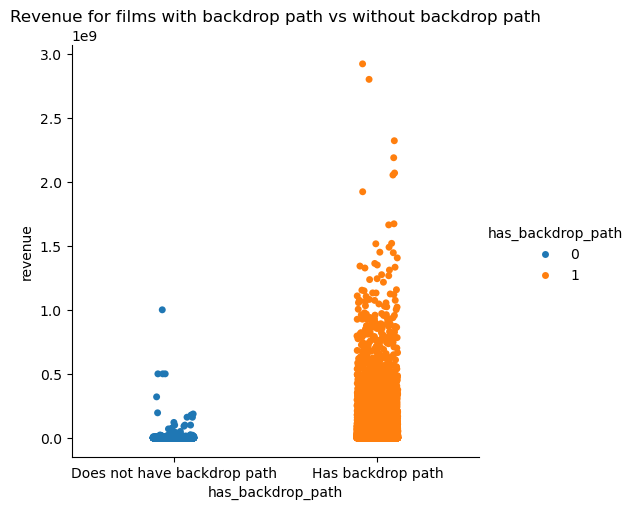

In [ ]:
ax = sns.catplot(x='has_backdrop_path', y='revenue', data=df, hue='has_backdrop_path')
plt.title('Revenue for films with backdrop path vs without backdrop path')

labels = ['Does not have backdrop path', 'Has backdrop path']
ax.set_xticklabels(labels)

In [ ]:
corr, _ = pearsonr(df['has_backdrop_path'], df['revenue'])
print('Pearsons correlation between backdrop path and revenue: %.3f' % corr)
corr, _ = pearsonr(df['has_backdrop_path'], np.log1p(df['revenue']))
print('Pearsons correlation between backdrop path and log transformed revenue: %.3f' % corr)

Pearsons correlation between backdrop path and revenue: 0.117
Pearsons correlation between backdrop path and log transformed revenue: 0.443



We have observed a modest positive correlation between the presence of a backdrop path and the revenue of a film.

In [ ]:
df_features.append('has_backdrop_path')

### Recommendations

The column contains a sequence of movie IDs separated by dashes, implying movie recommendations. However, the manner in which these recommendations are presented lacks clarity and does not adhere to a recognizable recommendation system. To gain a better understanding of this variable, further investigation is required.

In [ ]:
df['recommendations'].head()

0    1006462-298618-569094-1061181-346698-1076487-6...
1    713704-296271-502356-1076605-1084225-1008005-9...
2    573435-519182-957452-1022789-945961-718821-103...
3    496450-569094-298618-385687-877100-598331-4628...
4    438631-763215-792307-1011985-467244-634492-359...
Name: recommendations, dtype: object

In [ ]:
print("Movies misssing recommendations: ",df['recommendations'].isna().sum())

Movies misssing recommendations:  6159


In [ ]:
df['recommendations'] = df['recommendations'].fillna('')

In [ ]:
df['recommendations_processed'] = df['recommendations'].str.split('-')

To facilitate further data exploration, we will create a new dataframe that captures the frequency of a movie appearing in the recommendation column of other movies. This will enable us to analyze and investigate the relationships between movies based on their recommendations.

#### Univariate Analysis

In [ ]:
df["recommendations_processed"].sample(50)

33725                                                    []
3729      [12212, 10292, 3597, 3600, 11377, 10984, 12619...
4329                                                     []
5426      [1105014, 518158, 1045781, 892535, 736500, 69,...
67180                                                    []
11560     [918078, 42448, 91767, 27091, 51933, 11718, 10...
34392                                                    []
12796     [426426, 209274, 375262, 51110, 118669, 491472...
330650                                                   []
10422     [241257, 26481, 449985, 5876, 445571, 447332, ...
17699     [35588, 891, 1630, 11646, 820, 5902, 14534, 95...
2416      [440471, 138103, 480042, 225574, 76163, 146216...
3568      [13649, 13655, 10947, 16996, 2976, 60405, 5592...
28276     [203217, 620683, 303982, 322994, 337706, 34588...
12015     [11908, 167575, 472338, 71670, 9730, 11187, 97...
4926      [887645, 1124, 745, 186, 1954, 9654, 594, 4561...
962       [977897, 82675, 884361, 30762,

In [ ]:
recommendationsDict = {}
for element in df["recommendations_processed"].values:
    if '' in element:
        element.remove('')
    for recommendation in element:
        if recommendation not in recommendationsDict:
            recommendationsDict[recommendation] = 1
        else:
            recommendationsDict[recommendation] += 1

for key, value in list(recommendationsDict.items()):
    if int(key) not in df['id']:
        del recommendationsDict[key]

In [ ]:
number_of_times_recommended_df = pd.DataFrame.from_dict(recommendationsDict, orient='index', columns=["number_of_times_recommended"])
number_of_times_recommended_df

,number_of_times_recommended
462883,6
6264,1
13200,6
1257,16
3980,13
...,...
48653,2
42319,2
1616,1
9601,1


<Axes: >

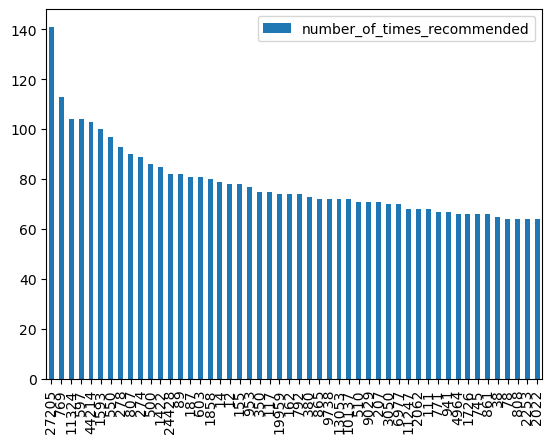

In [ ]:
number_of_times_recommended_df = number_of_times_recommended_df.sort_values(by="number_of_times_recommended", ascending=False)
number_of_times_recommended_df.head(50).plot.bar()

In [ ]:
new_df = pd.DataFrame(columns=number_of_times_recommended_df.index.values)

df = pd.concat([df, new_df], axis=1)

del new_df

for g in number_of_times_recommended_df.index.values:
    df[g] = df['recommendations_processed'].apply(lambda x: 1 if g in x else 0)

In [ ]:
numberOfRecommendationsDict = {}
i = 0
for numberOfRecommendation in number_of_times_recommended_df["number_of_times_recommended"]:
    if numberOfRecommendation not in numberOfRecommendationsDict:
        numberOfRecommendationsDict[numberOfRecommendation] = [number_of_times_recommended_df.index.values[i]]
    else:
        numberOfRecommendationsDict[numberOfRecommendation].append(number_of_times_recommended_df.index.values[i])
    i+=1

In [ ]:
number_of_times_recommended_df['id'] = number_of_times_recommended_df.index.astype(int)
df = df.merge(number_of_times_recommended_df, on='id', how='left')
df['number_of_times_recommended'].fillna(value=0, inplace=True)
df['number_of_times_recommended'] = df['number_of_times_recommended'].astype(np.int64)
df

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\3816582750.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['number_of_times_recommended'].fillna(value=0, inplace=True)


,id,title,genres,original_language,overview,popularity,production_companies,release_date,budget,revenue,...,20024,16023,5898,18019,17963,13841,14233,9583,9527,number_of_times_recommended
0,615656,Meg 2: The Trench,Action-Science Fiction-Horror,en,An exploratory dive into the deepest depths of...,8763.998,Apelles Entertainment-Warner Bros. Pictures-di...,2023-08-02,129000000.0,3.520565e+08,...,0,0,0,0,0,0,0,0,0,0
1,758323,The Pope's Exorcist,Horror-Mystery-Thriller,en,Father Gabriele Amorth Chief Exorcist of the V...,5953.227,Screen Gems-2.0 Entertainment-Jesus & Mary-Wor...,2023-04-05,18000000.0,6.567582e+07,...,0,0,0,0,0,0,0,0,0,0
2,533535,Deadpool & Wolverine,Action-Comedy-Science Fiction,en,A listless Wade Wilson toils away in civilian ...,5410.496,Marvel Studios-Maximum Effort-21 Laps Entertai...,2024-07-24,200000000.0,1.326387e+09,...,0,0,0,0,0,0,0,0,0,0
3,667538,Transformers: Rise of the Beasts,Action-Adventure-Science Fiction,en,When a new threat capable of destroying the en...,5409.104,Skydance-Paramount-di Bonaventura Pictures-Bay...,2023-06-06,200000000.0,4.070455e+08,...,0,0,0,0,0,0,0,0,0,0
4,693134,Dune: Part Two,Science Fiction-Adventure,en,Follow the mythic journey of Paul Atreides as ...,4742.163,Legendary Pictures,2024-02-27,190000000.0,6.838137e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16024,508713,Juna,Drama-Science Fiction,de,A dream shows Juna that she has only one last ...,0.600,NOT FROM L.A. PRODUTCION BERLIN,2018-03-20,200.0,2.000000e+02,...,0,0,0,0,0,0,0,0,0,0
16025,508882,Vaat Bahar Jai Nai,N/A,en,Romantic Drama of Old couple who divulges ther...,0.600,,2005-08-05,20000.0,2.200000e+04,...,0,0,0,0,0,0,0,0,0,0
16026,525758,The Lost Land,Drama-Comedy,zh,At a small town in the west of China in 1935 t...,0.600,,2018-05-18,0.0,2.028640e+05,...,0,0,0,0,0,0,0,0,0,0
16027,493180,Super Bheem Toota Khush Tara,N/A,en,,0.600,,2017-12-17,256982.0,1.253654e+06,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
column_names = []
for times, ids in numberOfRecommendationsDict.items():
    column_names.append('number of times recommended: '+str(times))

In [ ]:
new_df = pd.DataFrame(columns=column_names)
new_df_2 = df.copy()
df = pd.concat([new_df_2, new_df], axis=1)
del new_df
del new_df_2

In [ ]:
for times, ids in numberOfRecommendationsDict.items():
    column_name = 'number of times recommended: '+str(times)
    for i in ids:
        df.loc[df['id'] == int(i), column_name] = 1
    df[column_name].fillna(value=0, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\589052408.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column_name].fillna(value=0, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_2256\589052408.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column_name].fillna(value=0, inplace=True)


#### Bivariate Analysis

In [ ]:
recommendations_df = pd.DataFrame()
recommendations_df.loc[str(0), "median_revenue"] = df[df['number_of_times_recommended'] == 0]['revenue'].median()
for i in numberOfRecommendationsDict.keys():
    recommendations_df.loc[str(i), "median_revenue"] = df[df['number_of_times_recommended'] == i]['revenue'].median()


recommendations_df["median_revenue"].sort_values(ascending=False).head(5)

104    1.241132e+09
82     9.964937e+08
78     9.724470e+08
141    8.255328e+08
80     7.097098e+08
Name: median_revenue, dtype: float64

In [ ]:
recommendations_df.loc[str(0), "mean_revenue"] = df[df['number_of_times_recommended'] == 0]['revenue'].mean()
for i in numberOfRecommendationsDict.keys():
    recommendations_df.loc[str(i), "mean_revenue"] = df[df['number_of_times_recommended'] == i]['revenue'].mean()


recommendations_df['mean_revenue'].sort_values(ascending=False).head(5)

104    1.241132e+09
82     9.964937e+08
78     9.724470e+08
141    8.255328e+08
80     7.097098e+08
Name: mean_revenue, dtype: float64

In [ ]:
recommendations_df.loc[str(0), "total_revenue"] = df[df['number_of_times_recommended'] == 0]['revenue'].sum()
for i in numberOfRecommendationsDict.keys():
    recommendations_df.loc[str(i), "total_revenue"] = df[df['number_of_times_recommended'] == i]['revenue'].sum()


recommendations_df["total_revenue"].sort_values(ascending=False).head(5)

0     5.478864e+11
45    4.504196e+09
27    4.384273e+09
25    4.257442e+09
40    4.012375e+09
Name: total_revenue, dtype: float64

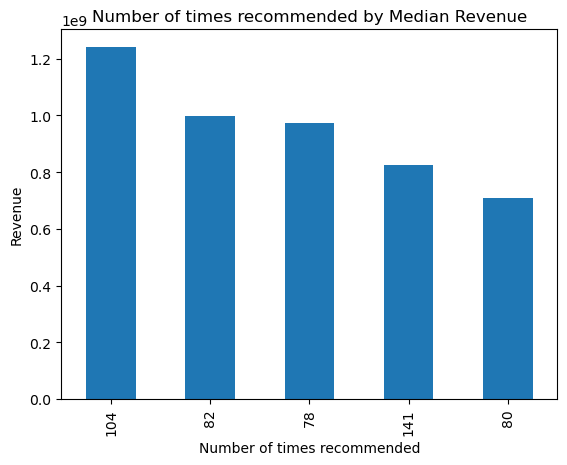

In [ ]:
recommendations_df.sort_values(by=["median_revenue"], ascending=False).head(5).median_revenue.plot.bar()
plt.title("Number of times recommended by Median Revenue")
plt.ylabel("Revenue")
plt.xlabel("Number of times recommended")

plt.show()

Text(0.5, 0, 'Number of times recommended')

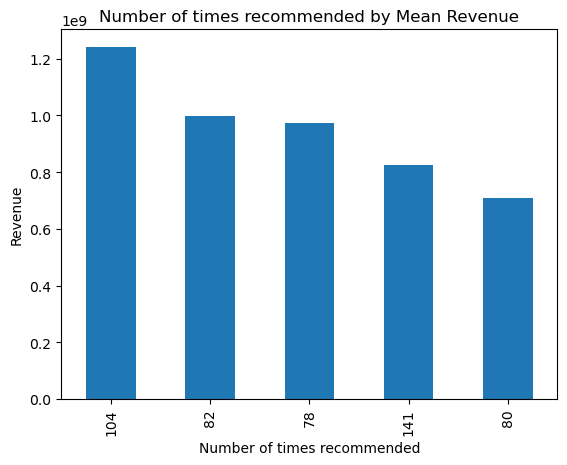

In [ ]:
recommendations_df.sort_values(by=["mean_revenue"], ascending=False).head(5).mean_revenue.plot.bar()
plt.title("Number of times recommended by Mean Revenue")
plt.ylabel("Revenue")
plt.xlabel("Number of times recommended")

Text(0.5, 0, 'Number of times recommended')

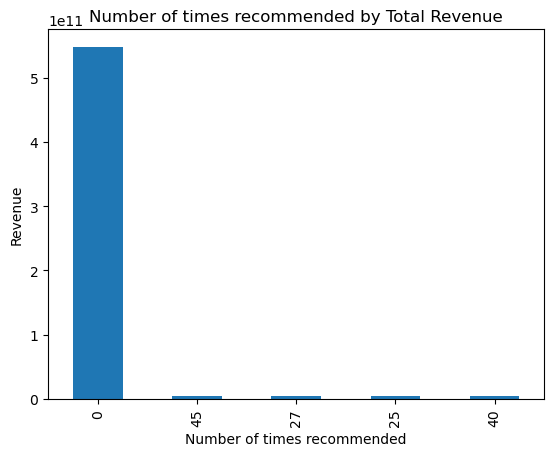

In [ ]:
recommendations_df.sort_values(by=["total_revenue"], ascending=False).head(5).total_revenue.plot.bar()
plt.title("Number of times recommended by Total Revenue")
plt.ylabel("Revenue")
plt.xlabel("Number of times recommended")

The number of times a movie is recommended could be a valuable metric for identifying how it influences the success of the film

In [ ]:
corr, _ = pearsonr(df['number_of_times_recommended'], df['revenue'])
print('Pearsons correlation between number of times recommended and revenue: %.3f' % corr)
corr, _ = pearsonr(np.log1p(df['number_of_times_recommended']), np.log1p(df['revenue']))
print('Pearsons correlation between log transformed number of times recommended and log transformed revenue: %.3f' % corr)

Pearsons correlation between number of times recommended and revenue: 0.254
Pearsons correlation between log transformed number of times recommended and log transformed revenue: 0.262


Based on the analysis provided, there is minimal linear correlation observed between the frequency of recommendations and the resulting revenue of the movies. Although the possibility of a relationship between recommendations and revenue cannot entirely be dismissed, the recommendations column will be excluded from our model as it seems to have a negligible impact on revenue.

In [ ]:
cols_to_drop.append("recommendations")

## Additional Feature Engineering and Creation

After conducting a thorough analysis of all the variables, we have identified that the budget and revenue columns contain numerous values that appear to be invalid or irrelevant. These two factors are crucial for the success of our model. Previously, we resorted to replacing the problematic values with the median budget. However, due to the sheer number of such values, we now require a more effective solution. Our plan is to calculate the average budget and revenue based on the studios involved in each film. This approach is expected to provide a more accurate estimation of the budget or revenue for movies with missing or unreliable values. We will apply a function that replaces all budget and revenue values below $10,000 in our df set with the calculated averages.

In [ ]:
def getAverageStudioRevenue(movie):
    if movie.budget < 10000:
        if len(movie.production_companies_processed) > 0:
            studios = movie.production_companies_processed
            median_revs = []
            for studio in studios:
                if studio in companies_df.index:
                     median_revs.append(float(companies_df.loc[studio]['median_revenue']))
            if(len(median_revs) > 0) and np.mean(median_revs) > 10000:
                movie.budget_processed = np.mean(median_revs)
            else:
                movie.budget_processed = df.budget.median()
        else:
            movie.budget_processed = df.budget.median()



    if 'revenue' in movie and movie.revenue < 10000 and len(movie.production_companies_processed) > 0:
        studios = movie.production_companies_processed
        median_revs = []
        for studio in studios:
            if studio in companies_df.index:
                 median_revs.append(float(companies_df.loc[studio]['median_revenue']))
        if(len(median_revs) > 0) and np.mean(median_revs) > 10000:
            movie.revenue = np.mean(median_revs)
        else:
            movie.revenue = df.revenue.median()
        return movie
    else:
        return movie

In [ ]:
df = df.apply(getAverageStudioRevenue, axis=1)

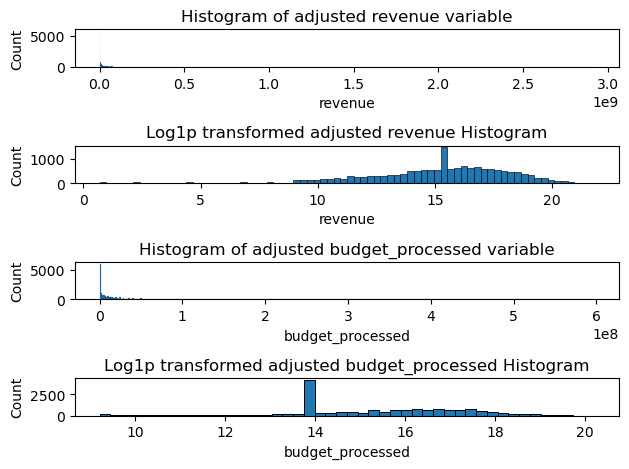

In [ ]:
f, ax = plt.subplots(4)

sns.histplot(data=df, x='revenue', kde=False, ax=ax[0], alpha=1)
ax[0].set_title("Histogram of adjusted revenue variable")

sns.histplot(data=np.log1p(df.revenue), kde=False, ax=ax[1], alpha=1)
ax[1].set_title("Log1p transformed adjusted revenue Histogram")

sns.histplot(data=df, x='budget_processed', kde=False, ax=ax[2], alpha=1)
ax[2].set_title("Histogram of adjusted budget_processed variable")

sns.histplot(data=np.log1p(df.budget_processed), kde=False, ax=ax[3], alpha=1)
ax[3].set_title("Log1p transformed adjusted budget_processed Histogram")

f.tight_layout()
plt.show()

After making the necessary adjustments, the distributions of the data appear to be more satisfactory. Although there are still some inaccuracies in the lower values, we prefer not to manipulate the data excessively. While it would be ideal to have access to the actual revenues and budgets, we will continue to work with the provided data.

To address the changes in the film industry over time and account for inflation, we intend to introduce two additional features. The first feature will be a ratio of the budget to the year of release, and the second feature will be a ratio of the runtime to the year of release. We believe that these two variables will be particularly beneficial since they are likely to have undergone significant changes over the past few decades in the film industry.

In [ ]:
df = df.copy()
df['budget_to_year_ratio'] = df['budget_processed'] / (df['year'] * df['year'])

In [ ]:
df['runtime_to_year_ratio'] = df['runtime'] / (df['year'])

In [ ]:
log_features.append('budget_to_year_ratio')
log_features.append('runtime_to_year_ratio')

## Feature Selection

Now that we have explored all of the data and created several new features for our model, let's look at the results and get our final set of features.

In [ ]:
print(cols_to_drop)

['overview', 'popularity', 'actorRanks', 'topActorRank', 'recommendations']


These columns have been ended up with, which were decided to be entirely dropped as they do not have any use to us. It is not necessary to actually drop them from the dataset, but it is still important to document the column that is completely unused and did not serve a purpose to our model. The justification for dropping this column can be found in the correlated sections previously throughout the analysis.

These dummy variables will be utilized in the model, and the numerical features need to undergo logarithmic transformation.

In [ ]:
for feat in log_features:
    df["log_" + feat] = np.log1p(df[feat])
    if feat != "revenue":
        df_features.append("log_" + feat)

Now that we have created log transformed features for all the ones we wanted to, this will be our final list of features for our model. Let's take a look at the list.

In [ ]:
print("Number of features: ", len(df_features))

Number of features:  44


That number of different features were included in the model, and now the correlation matrix of all the numerical features will be examined.

Text(0.5, 1.0, 'Correlation between numerical features')

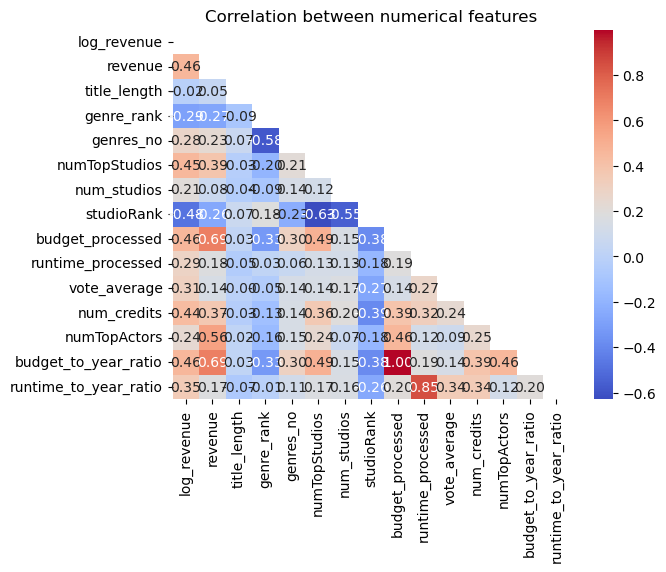

In [ ]:
corr = df[['log_revenue', *log_features]].corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Correlation between numerical features")

## Modeling

In [ ]:
X = df[df_features]
y = df['log_revenue']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.20)

In [ ]:
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (12823, 44) (12823,)
Test set: (3206, 44) (3206,)


In [ ]:
def algorithm_pipeline(X_train_data, X_test_data, y_train_data, y_test_data,
                       model, param_grid, cv=10, scoring_fit='neg_root_mean_squared_error',
                       do_probabilities = False):
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        n_jobs=-1,
        scoring=scoring_fit,
        verbose=2
    )
    fitted_model = gs.fit(X_train_data, y_train_data)

    if do_probabilities:
        pred = fitted_model.predict_proba(X_test_data)
    else:
        pred = fitted_model.predict(X_test_data)

    return fitted_model, pred

In [ ]:
def evaluate(model, test_features, test_labels):
    predictions = model.predict(test_features)
    errors = abs(predictions - test_labels)
    mape = 100 * np.mean(errors / test_labels)
    accuracy = 100 - mape
    print('Average Error: {:0.4f}'.format(np.mean(errors)))
    print('Accuracy = {:0.3f}%'.format(accuracy))

    return accuracy

In [ ]:
def metrics(y_pred, y_test):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    errors = abs(y_pred - y_test)
    mae = np.mean(errors)
    mape = 100 * (errors / y_test)
    print('Mean Squared Error: ', round(mse, 4))
    print('Root Mean Squared Error: ', round(rmse, 4))
    print('Mean Absolute Error: ', round(mae, 4))

    test_accuracy = 100 - np.mean(mape)
    print('Test Set Accuracy (from Mean Absolute Percentage Error):{:.3f}%'.format(test_accuracy))

### Random Forest

Random Forest is an algorithm that creates multiple decision trees and combines their predictions to make a more accurate and robust prediction. By averaging the predictions of these individual trees, Random Forest reduces errors and improves overall accuracy compared to a single decision tree.


#### Baseline

In [ ]:
rfr_base_model = RandomForestRegressor(random_state=42)
rfr_base_model.fit(X_train, y_train.values.ravel())

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rfr_base_model.predict(X_test)

In [ ]:
errors = abs(np.expm1(y_pred) - np.expm1(y_test.values))
print('Average Error:', round(np.mean(errors), 2))

Average Error: 24136002.64


In [ ]:
print('Random Forest Baseline Model Metrics:')
metrics(y_pred, y_test.values)

Random Forest Baseline Model Metrics:
Mean Squared Error:  4.019
Root Mean Squared Error:  2.0047
Mean Absolute Error:  1.378
Test Set Accuracy (from Mean Absolute Percentage Error):85.034%


In [ ]:
y_test

15556     9.660141
123      20.585575
2518     17.106803
5888     17.513251
5847     15.758701
           ...    
13605    15.575125
6081     16.475901
7018     13.676861
12735    10.962960
5923     15.875642
Name: log_revenue, Length: 3206, dtype: float64

#### Grid Search Hyperparameter Tuning

In [ ]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [10, 25, 30],
    'max_features': [.4, .6, 1],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [1, 3, 5],
    'n_estimators': [50, 100, 150]
}

rfr = RandomForestRegressor(random_state=42)
rfr, pred = algorithm_pipeline(X_train, X_test, y_train.values.ravel(), y_test.values, rfr, param_grid, cv=5)

print(np.sqrt(-rfr.best_score_))
print(rfr.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


In [ ]:
print('Base Model:')
base_accuracy = evaluate(rfr_base_model, X_test, y_test.values)

Base Model:
Average Error: 1.3780
Accuracy = 85.034%


In [ ]:
print('Model after Tuning:')
rfr_best_model = rfr.best_estimator_
best_accuracy = evaluate(rfr_best_model, X_test, y_test.values)

print('Improvement of {:0.2f}%.'.format( 100 * (best_accuracy - base_accuracy) / base_accuracy))

Model after Tuning:
Average Error: 1.3695
Accuracy = 84.919%
Improvement of -0.14%.


In [ ]:
y_pred = rfr_best_model.predict(X_test)
print('Random Forest Model Best Metrics:')
metrics(y_pred, y_test.values)

Random Forest Model Best Metrics:
Mean Squared Error:  3.9015
Root Mean Squared Error:  1.9752
Mean Absolute Error:  1.3695
Test Set Accuracy (from Mean Absolute Percentage Error):84.919%


#### Feature Importances

We had a pretty good accuracy and encouraging results with this first model. Let's now take a look at the importances of our features in the Random Forest model.

In [ ]:
feature_importances = rfr_best_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

for f in range(len(indices)):
    print("%d. %s (%f)" % (f + 1, X_train.columns[indices[f]], feature_importances[indices[f]]))

Feature ranking:
1. log_budget_to_year_ratio (0.252479)
2. vote_count (0.215668)
3. log_budget_processed (0.136636)
4. log_num_credits (0.055912)
5. log_runtime_to_year_ratio (0.040236)
6. log_genre_rank (0.033034)
7. log_studioRank (0.032767)
8. log_vote_average (0.031860)
9. log_runtime_processed (0.030433)
10. log_numTopStudios (0.030268)
11. log_title_length (0.026265)
12. log_genres_no (0.022848)
13. has_backdrop_path (0.014257)
14. log_num_studios (0.009989)
15. has_keywords (0.007878)
16. originally_english (0.006410)
17. 2010s (0.005814)
18. has_tagline (0.005584)
19. Fall (0.004615)
20. fridayRelease (0.004215)
21. Winter (0.003354)
22. 2020s (0.003217)
23. Spring (0.003073)
24. Summer (0.003065)
25. 2000s (0.002312)
26. saturdayRelease (0.002106)
27. thursdayRelease (0.002005)
28. has_poster_path (0.001955)
29. wednesdayRelease (0.001701)
30. tuesdayRelease (0.001626)
31. 1980s (0.001418)
32. 1990s (0.001243)
33. log_numTopActors (0.001241)
34. sundayRelease (0.001175)
35. mo

<Axes: >

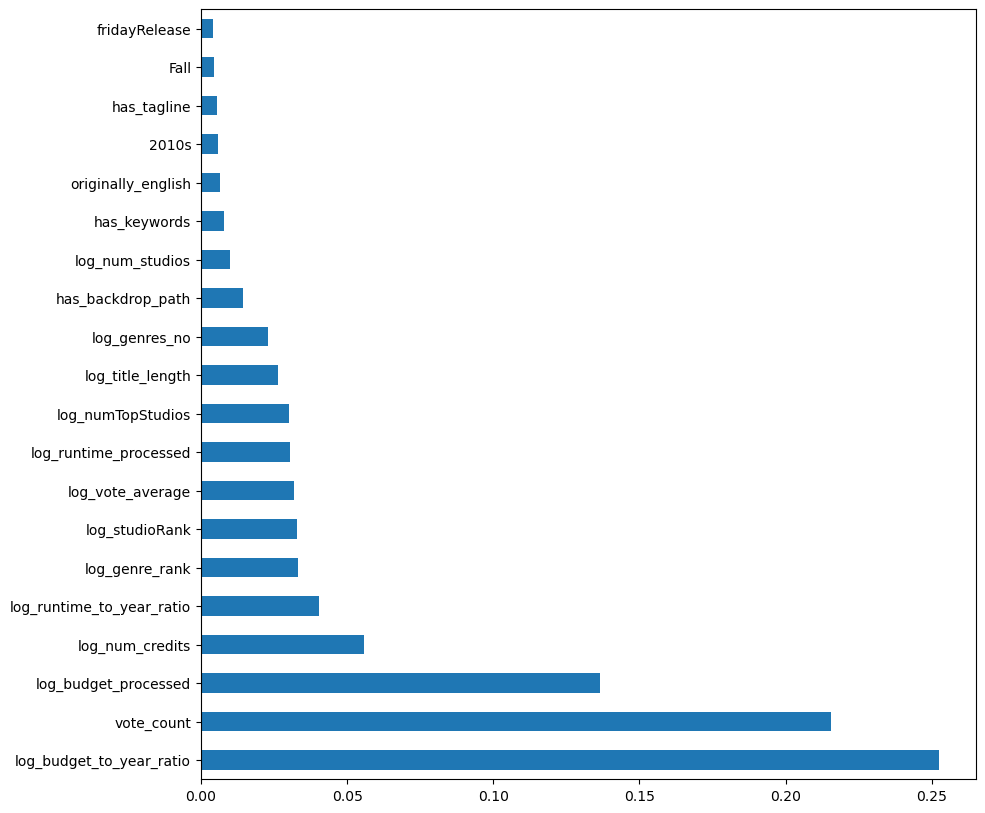

In [ ]:
feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=[10,10])

The results of our model indicate that the budget and budget-to-year ratio features were the most influential, which is not surprising. Additionally, the engineered features we created, such as studio and genre ranks, as well as the runtime to year ratio, demonstrated their potential usefulness. Unexpectedly, the number of credits and the length of the title also emerged as significant features in the top 10.

In [ ]:
# explainer = shap.TreeExplainer(rfr_best_model)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values, X_train)

Upon examining the SHAP values, we gain insights into how our model utilizes different features. For instance, we observe that high values of both variations of the budget variable are highly important predictors of revenue, while low values have less significance. Similarly, the number of credits feature proves to be crucial in our model, indicating that it is a strong indicator of higher revenue. Overall, the SHAP value plot provides fascinating insights into the internal mechanics of our model and how it makes predictions.

In [ ]:
# import pickle

# rfr_best_model.fit(X_train, y_train.values.ravel())
# filename = 'rfr_best_model.pkl'

# with open(filename, 'wb') as file:
#     pickle.dump(rfr_best_model, file)


### Extra Trees

Our upcoming implementation will center around the Extra Trees algorithm, which bears similarities to the Random Forest algorithm. Both algorithms employ multiple decision trees to make predictions. However, the key difference lies in the split selection process. While Random Forest calculates the locally optimal feature or split, the Extra Trees model randomly selects values for the split among the features under consideration.

#### Baseline

In [ ]:
et_base_model = ExtraTreesRegressor(random_state = 42)
et_base_model.fit(X_train, y_train.values.ravel())

ExtraTreesRegressor(random_state=42)

In [ ]:
y_pred = et_base_model.predict(X_test)

In [ ]:
print('Extra Trees Baseline Model Metrics:')
metrics(y_pred, y_test.values)

Extra Trees Baseline Model Metrics:
Mean Squared Error:  4.1211
Root Mean Squared Error:  2.03
Mean Absolute Error:  1.381
Test Set Accuracy (from Mean Absolute Percentage Error):84.956%


#### Grid Search Hyperparameter Tuning

In [ ]:
et_model = ExtraTreesRegressor(random_state = 42)
param_grid = {
    'bootstrap': [True],
    'max_depth': [35, 40, 45],
    'max_features': [.4, .6, 1],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [4, 5, 7],
    'n_estimators': [50, 100, 150]
}

et_model, pred = algorithm_pipeline(X_train, X_test, y_train.values.ravel(), y_test.values, et_model,
                                 param_grid, cv=5)

print(np.sqrt(-et_model.best_score_))
print(et_model.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
1.4336074606147422
{'bootstrap': True, 'max_depth': 40, 'max_features': 0.6, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}


In [ ]:
base_accuracy = evaluate(et_base_model, X_test, y_test.values)

Average Error: 1.3810
Accuracy = 84.956%


In [ ]:
print('Model after Tuning:')
et_best_model = et_model.best_estimator_
best_accuracy = evaluate(et_best_model, X_test, y_test.values)

print('Improvement of {:0.2f}%.'.format( 100 * (best_accuracy - base_accuracy) / base_accuracy))

Model after Tuning:
Average Error: 1.3789
Accuracy = 84.837%
Improvement of -0.14%.


In [ ]:
y_pred = et_base_model.predict(X_test)
print('Extra Trees Model Best Metrics:')
metrics(y_pred, y_test.values)

Extra Trees Model Best Metrics:
Mean Squared Error:  4.1211
Root Mean Squared Error:  2.03
Mean Absolute Error:  1.381
Test Set Accuracy (from Mean Absolute Percentage Error):84.956%


#### Feature Importances

The feature importances of the Extra Trees algorithm were quite comparable to those of the Random Forest algorithm, with only a slightly lower performance. Let's examine the feature importances and compare them to evaluate their similarities.

In [ ]:
feature_importances = et_best_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

for f in range(len(indices)):
    print("%d. %s (%f)" % (f + 1, X_train.columns[indices[f]], feature_importances[indices[f]]))

Feature ranking:
1. log_budget_to_year_ratio (0.166690)
2. log_budget_processed (0.124881)
3. vote_count (0.091557)
4. log_studioRank (0.067564)
5. has_backdrop_path (0.057408)
6. log_num_credits (0.056718)
7. log_numTopStudios (0.048719)
8. log_vote_average (0.034751)
9. log_runtime_processed (0.024434)
10. log_runtime_to_year_ratio (0.023737)
11. has_keywords (0.022345)
12. log_genre_rank (0.021523)
13. log_genres_no (0.021267)
14. log_title_length (0.018831)
15. has_tagline (0.018606)
16. originally_english (0.015393)
17. 2010s (0.015312)
18. log_num_studios (0.014797)
19. fridayRelease (0.012589)
20. Fall (0.012544)
21. 2020s (0.011477)
22. Winter (0.011442)
23. Summer (0.010645)
24. Spring (0.010560)
25. thursdayRelease (0.009631)
26. saturdayRelease (0.008611)
27. 2000s (0.008607)
28. wednesdayRelease (0.008417)
29. tuesdayRelease (0.006813)
30. mondayRelease (0.006090)
31. 1990s (0.005305)
32. has_poster_path (0.005281)
33. sundayRelease (0.005276)
34. 1980s (0.004635)
35. topSt

<Axes: >

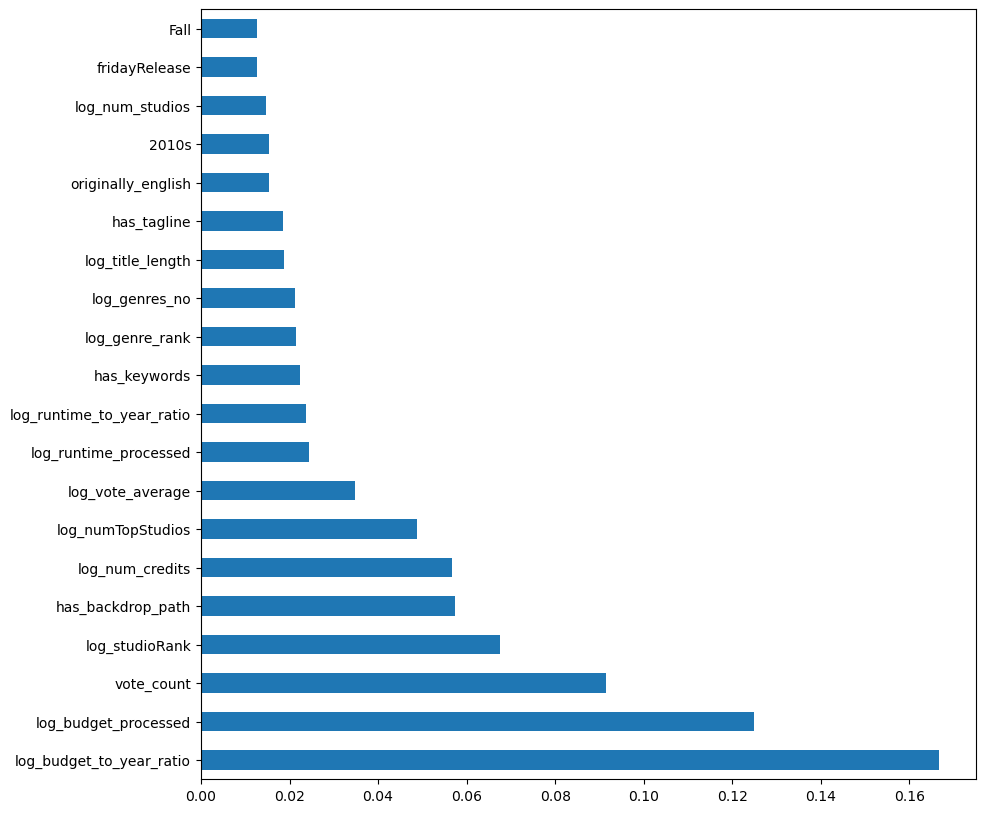

In [ ]:
feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=[10,10])

The most significant features in the model were similar, but with a few differences. One noteworthy change was the inclusion of Fall instead of Winter in the top 20 features. Now, let's proceed to examine the SHAP values to gain further insights.

In [ ]:
# explainer = shap.TreeExplainer(et_best_model)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values, X_train)

The SHAP values exhibit a similar pattern and can be interpreted in a similar manner. The budget features stands out as highly influential, indicating that when a higher budget is involved in a movie, it is predicted to have significantly higher revenue.

### XGBoost

The next model we will experiment with is XGBoost. XGBoost is specifically developed to optimize performance and is particularly well-suited for handling extensive datasets. It excels in terms of both speed and precision, making it an ideal choice for working with substantial amounts of data. XGBoost incorporates algorithms within the gradient boosting framework and offers parallel tree boosting techniques to effectively address various problem domains.

#### Baseline

In [ ]:
print(X_train.columns.tolist())

def are_items_unique(lst):
    return len(lst) == len(set(lst))

print(are_items_unique(X_train.columns.tolist()))

def print_duplicates(lst):
    seen = set()
    duplicates = set()

    for item in lst:
        if item in seen:
            duplicates.add(item)
        else:
            seen.add(item)

    if duplicates:
        print("Duplicates:", ", ".join(map(str, duplicates)))
    else:
        print("No duplicates found.")

print_duplicates(X_train.columns.tolist())

['originally_english', 'topStudio', '1910s', '1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s', 'mondayRelease', 'tuesdayRelease', 'wednesdayRelease', 'thursdayRelease', 'fridayRelease', 'saturdayRelease', 'sundayRelease', 'Winter', 'Fall', 'Spring', 'Summer', 'has_tagline', 'vote_count', 'topLeadActor', 'has_keywords', 'has_poster_path', 'has_backdrop_path', 'log_title_length', 'log_genre_rank', 'log_genres_no', 'log_numTopStudios', 'log_num_studios', 'log_studioRank', 'log_budget_processed', 'log_runtime_processed', 'log_vote_average', 'log_num_credits', 'log_numTopActors', 'log_budget_to_year_ratio', 'log_runtime_to_year_ratio']
True
No duplicates found.


In [ ]:
xgb_base_model = xgb.XGBRegressor(random_state = 42)
xgb_base_model.fit(X_train, y_train.values.ravel())

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_base_model.predict(X_test)

In [ ]:
print('XGBoost Baseline Model Metrics:')
metrics(y_pred, y_test.values)

XGBoost Baseline Model Metrics:
Mean Squared Error:  4.2131
Root Mean Squared Error:  2.0526
Mean Absolute Error:  1.3885
Test Set Accuracy (from Mean Absolute Percentage Error):84.944%


#### Grid Search Hyperparameter Tuning

In [ ]:
xgb_model = xgb.XGBRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'colsample_bytree': [0.9, 1.0, 1.1],
    'max_depth': [2, 5, 10],
    'reg_alpha': [1.0, 1.1, 1.2],
    'reg_lambda': [ 1.2, 1.3, 1.4],
    'subsample': [0.9, 1.0]
}

xgb_model, pred = algorithm_pipeline(X_train, X_test, y_train.values.ravel(), y_test.values, xgb_model,
                                 param_grid, cv=5)

print(np.sqrt(-xgb_model.best_score_))
print(xgb_model.best_params_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
810 fits failed out of a total of 2430.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
810 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\sklearn.py", line 1247, in fit
    self._Booster = train(
                    ^^^^^^
  File "C:

1.4397872603437523
{'colsample_bytree': 0.9, 'max_depth': 5, 'n_estimators': 50, 'reg_alpha': 1.2, 'reg_lambda': 1.3, 'subsample': 1.0}


In [ ]:
print('Base Model:')
base_accuracy = evaluate(xgb_base_model, X_test, y_test.values)

Base Model:
Average Error: 1.3885
Accuracy = 84.944%


In [ ]:
print('Model after Tuning:')
xgb_best_model = xgb_model.best_estimator_
best_accuracy = evaluate(xgb_best_model, X_test, y_test.values)

print('Improvement of {:0.3f}%.'.format( 100 * (best_accuracy - base_accuracy) / base_accuracy))

Model after Tuning:
Average Error: 1.3785
Accuracy = 84.890%
Improvement of -0.063%.


In [ ]:
y_pred = xgb_base_model.predict(X_test)
print('XGBoost Model Best Metrics:')
metrics(y_pred, y_test.values)

XGBoost Model Best Metrics:
Mean Squared Error:  4.2131
Root Mean Squared Error:  2.0526
Mean Absolute Error:  1.3885
Test Set Accuracy (from Mean Absolute Percentage Error):84.944%


The features that are most important seem to be similar again, however the top of the list is quite surprising. The number of directors of photography turned out to be at the top, which is not at all expected. Looking at the SHAP values may be a better indicator of how the model made its predictions.

#### Feature Importances

In [ ]:
feature_importances = xgb_best_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

for f in range(len(indices)):
    print("%d. %s (%f)" % (f + 1, X_train.columns[indices[f]], feature_importances[indices[f]]))

Feature ranking:
1. log_budget_to_year_ratio (0.297590)
2. vote_count (0.136315)
3. has_backdrop_path (0.049649)
4. log_studioRank (0.040995)
5. log_numTopStudios (0.039250)
6. has_keywords (0.035940)
7. log_runtime_to_year_ratio (0.027188)
8. 2010s (0.022209)
9. 2020s (0.021470)
10. log_num_credits (0.021389)
11. log_genre_rank (0.017324)
12. log_budget_processed (0.016413)
13. 1930s (0.015917)
14. Fall (0.015325)
15. 1980s (0.014984)
16. log_runtime_processed (0.014814)
17. originally_english (0.014246)
18. saturdayRelease (0.013155)
19. has_tagline (0.012272)
20. has_poster_path (0.012253)
21. log_vote_average (0.011329)
22. log_title_length (0.011062)
23. log_num_studios (0.010729)
24. log_genres_no (0.010492)
25. Spring (0.010368)
26. tuesdayRelease (0.009909)
27. Winter (0.009394)
28. 1950s (0.009148)
29. mondayRelease (0.008880)
30. 1970s (0.008666)
31. Summer (0.008253)
32. 1920s (0.007217)
33. thursdayRelease (0.007055)
34. 1960s (0.007000)
35. log_numTopActors (0.006776)
36. 

<Axes: >

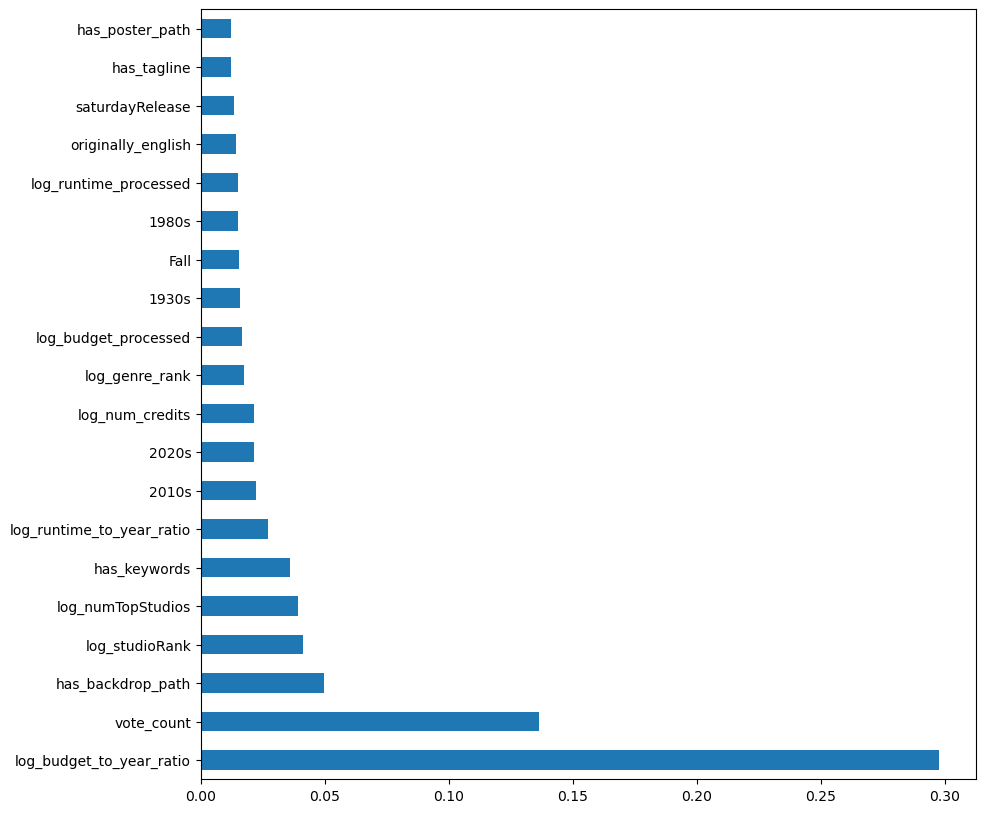

In [ ]:
feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=[10,10])

The most important features in this model are again quite similar, with the notable difference being the absence of any seasons in the top 20 features. Instead, certain day of the week releases have emerged as influential factors. Considering the SHAP values may provide a better understanding of how the model made its predictions, as they offer insights into the individual contributions of features.

In [ ]:
mybooster = xgb_best_model.get_booster()
model_bytearray = mybooster.save_raw()[4:]

def myfun(*args, **kwargs):  # Accept any arguments, ignore them
    return model_bytearray

mybooster.save_raw = myfun  # Overwrite save_raw with the dummy function


In [ ]:
#!pip install shap==0.41.0


In [ ]:
# booster = xgb_best_model.get_booster()  # Extract native booster from sklearn wrapper
# explainer = shap.TreeExplainer(booster)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values, X_train)

Upon examining the SHAP values, we observe similarities with the previous models. Once again, the budget to year feature prove to be a strong predictor, highlighting their significance in determining revenue.

### LightGBM

Next, we will proceed with the implementation of LightGBM. LightGBM is a gradient boosting framework that is similar to XGBoost, but it aims to provide superior speed and efficiency. It is designed to be lightweight, consume less memory, and perform well on large-scale datasets. Now, let's evaluate its performance on our data.

#### Baseline

In [ ]:
lgbm_base_model = LGBMRegressor(random_state=42)
lgbm_base_model.fit(X_train, y_train.values.ravel())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2112
[LightGBM] [Info] Number of data points in the train set: 12823, number of used features: 43
[LightGBM] [Info] Start training from score 15.083432


LGBMRegressor(random_state=42)

In [ ]:
y_pred = lgbm_base_model.predict(X_test)

#### Grid Search Hyperparameter Tuning

In [ ]:
print('LightGBM Baseline Model Metrics:')
metrics(y_pred, y_test.values)

LightGBM Baseline Model Metrics:
Mean Squared Error:  3.9689
Root Mean Squared Error:  1.9922
Mean Absolute Error:  1.3648
Test Set Accuracy (from Mean Absolute Percentage Error):84.942%


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'colsample_bytree': [0.8, 1.0, 1.2],
    'max_depth': [-1, 5, 10],
    'reg_alpha': [0.4, 0.5, 0.6],
    'reg_lambda': [0.2, 0.3, 0.4],
    'subsample': [0.8, 0.9, 1],
    'num_leaves': [30,31,32]
}

lgbm = LGBMRegressor(random_state=42)
lgbm, pred = algorithm_pipeline(X_train, X_test, y_train.values.ravel(), y_test.values, lgbm,
                                 param_grid, cv=5)

print(np.sqrt(-lgbm.best_score_))
print(lgbm.best_params_)

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
3645 fits failed out of a total of 10935.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3645 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\lightgbm\sklearn.py", line 1398, in fit
    super().fit(
  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\lightgbm\sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "C:\Users\DELL\AppData\Roaming\Py

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000593 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2112
[LightGBM] [Info] Number of data points in the train set: 12823, number of used features: 43
[LightGBM] [Info] Start training from score 15.083432
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [ ]:
lgbm_base_model = LGBMRegressor()
lgbm_base_model.fit(X_train, y_train.values.ravel())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2112
[LightGBM] [Info] Number of data points in the train set: 12823, number of used features: 43
[LightGBM] [Info] Start training from score 15.083432


LGBMRegressor()

In [ ]:
base_accuracy = evaluate(lgbm_base_model, X_test, y_test.values)

Average Error: 1.3648
Accuracy = 84.942%


In [ ]:
lgbm_best_model = lgbm.best_estimator_
best_accuracy = evaluate(lgbm_best_model, X_test, y_test.values)

print('Improvement of {:0.2f}%.'.format( 100 * (best_accuracy - base_accuracy) / base_accuracy))

Average Error: 1.3662
Accuracy = 84.892%
Improvement of -0.06%.


In [ ]:
y_pred = lgbm_best_model.predict(X_test)
print('LightGBM Model Best Metrics:')
metrics(y_pred, y_test.values)

LightGBM Model Best Metrics:
Mean Squared Error:  3.9233
Root Mean Squared Error:  1.9807
Mean Absolute Error:  1.3662
Test Set Accuracy (from Mean Absolute Percentage Error):84.892%


The results of this model were remarkably similar. Despite attempting tuning, the accuracy did not improve. However, let's proceed with comparing the feature importances across the models to gain further insights.

#### Feature Importances

In [ ]:
feature_importances = lgbm_best_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

for f in range(len(indices)):
    print("%d. %s (%f)" % (f + 1, X_train.columns[indices[f]], feature_importances[indices[f]]))

Feature ranking:
1. vote_count (246.000000)
2. log_budget_to_year_ratio (209.000000)
3. log_genre_rank (205.000000)
4. log_runtime_processed (199.000000)
5. log_vote_average (183.000000)
6. log_runtime_to_year_ratio (173.000000)
7. log_num_credits (165.000000)
8. log_title_length (152.000000)
9. log_genres_no (129.000000)
10. log_budget_processed (127.000000)
11. originally_english (73.000000)
12. log_studioRank (67.000000)
13. log_num_studios (67.000000)
14. has_keywords (42.000000)
15. 2010s (41.000000)
16. log_numTopStudios (39.000000)
17. 2020s (37.000000)
18. Fall (30.000000)
19. has_tagline (23.000000)
20. 1970s (21.000000)
21. Winter (19.000000)
22. has_backdrop_path (17.000000)
23. saturdayRelease (17.000000)
24. has_poster_path (16.000000)
25. 2000s (15.000000)
26. fridayRelease (15.000000)
27. mondayRelease (13.000000)
28. 1980s (12.000000)
29. wednesdayRelease (11.000000)
30. Summer (10.000000)
31. sundayRelease (8.000000)
32. Spring (8.000000)
33. log_numTopActors (6.000000

<Axes: >

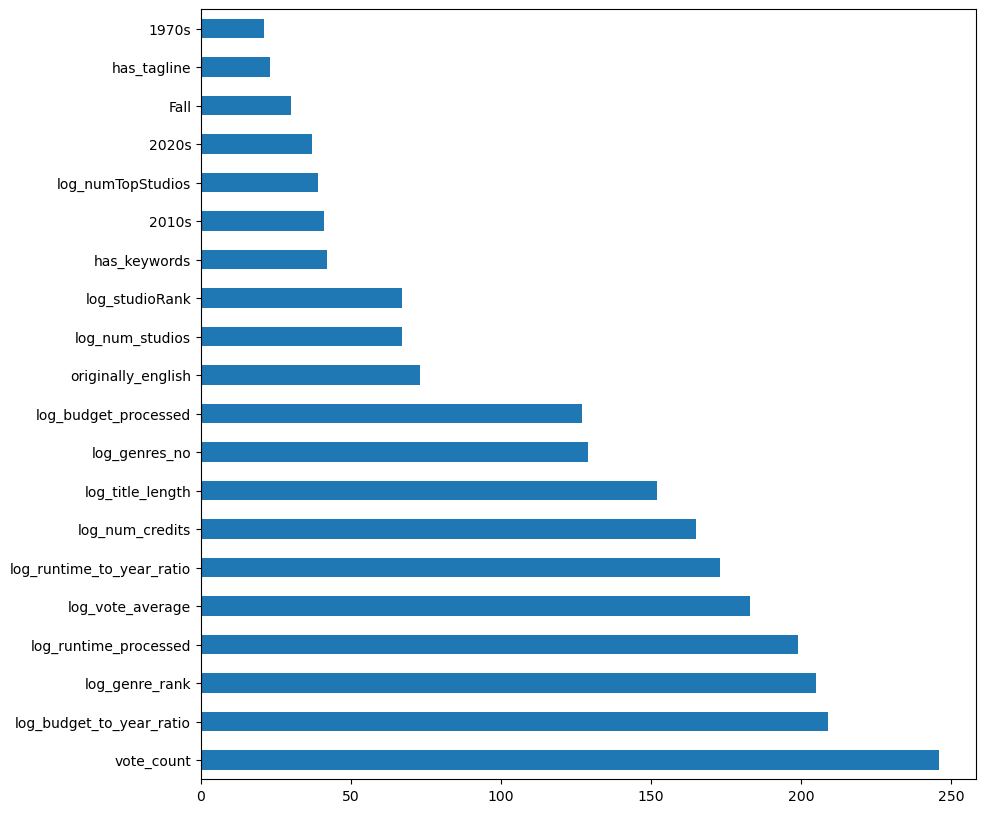

In [ ]:
feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=[10,10])

Interestingly, there was a noticeable shift in the feature importances, which is intriguing to observe. While the budget features still hold prominent positions, there are now several new features ranking higher as well. Notably, the runtime, vote count, genre rank, runtime to year, and average votes from first to fifth positions have all gained higher importance. Surprisingly, the budget to year ratio, which was previously more significant, now takes the sixth place in the rankings.

In [ ]:
# explainer = shap.TreeExplainer(lgbm_best_model)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values, X_train)

The SHAP values reveal a notable contrast from the feature importance rankings. In this case, the vote count now exerts the most significant impact among all features, still surpassing even the budget features in its influence on the predictions.

### CatBoost

We will now use the CatBoost model, which is a powerful algorithm for boosting and handling categorical features. It works well with big datasets that have different types of features, making it perfect for our analysis. CatBoost can handle categorical variables, missing values, and feature interactions automatically. It is also scalable and performs very well, allowing us to gain useful information from large and complicated datasets.

#### Baseline

In [ ]:
cb_base_model = CatBoostRegressor(random_state = 42)
cb_base_model.fit(X_train, y_train.values.ravel())

Learning rate set to 0.061269
0:	learn: 3.0280524	total: 148ms	remaining: 2m 27s
1:	learn: 2.9464680	total: 152ms	remaining: 1m 15s
2:	learn: 2.8717021	total: 155ms	remaining: 51.5s
3:	learn: 2.8053364	total: 159ms	remaining: 39.5s
4:	learn: 2.7422554	total: 163ms	remaining: 32.5s
5:	learn: 2.6857367	total: 167ms	remaining: 27.7s
6:	learn: 2.6349312	total: 172ms	remaining: 24.4s
7:	learn: 2.5870656	total: 177ms	remaining: 21.9s
8:	learn: 2.5438243	total: 181ms	remaining: 19.9s
9:	learn: 2.5059005	total: 185ms	remaining: 18.3s
10:	learn: 2.4701537	total: 191ms	remaining: 17.2s
11:	learn: 2.4382936	total: 196ms	remaining: 16.1s
12:	learn: 2.4090891	total: 201ms	remaining: 15.3s
13:	learn: 2.3831392	total: 207ms	remaining: 14.6s
14:	learn: 2.3579169	total: 213ms	remaining: 14s
15:	learn: 2.3355715	total: 218ms	remaining: 13.4s
16:	learn: 2.3147176	total: 224ms	remaining: 12.9s
17:	learn: 2.2970817	total: 229ms	remaining: 12.5s
18:	learn: 2.2802257	total: 237ms	remaining: 12.2s
19:	learn: 

In [ ]:
y_pred = cb_base_model.predict(X_test)

In [ ]:
print('CatBoost Baseline Model Metrics:')
metrics(y_pred, y_test.values)

CatBoost Baseline Model Metrics:
Mean Squared Error:  3.9358
Root Mean Squared Error:  1.9839
Mean Absolute Error:  1.3445
Test Set Accuracy (from Mean Absolute Percentage Error):84.996%


#### Grid Search Hyperparameter Tuning

In [ ]:
cb_model = CatBoostRegressor(random_state = 42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'colsample_bylevel': [0.7, 0.8, 0.9],
    'max_depth': [3, 5, 7],
    'l2_leaf_reg': [0.1, 0.5, 1.0],
    'subsample': [0.7, 0.8, 0.9]
}

cb_model, pred = algorithm_pipeline(X_train, X_test, y_train.values.ravel(), y_test.values, cb_model,
                                 param_grid, cv=5)

print(np.sqrt(-cb_model.best_score_))
print(cb_model.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
0:	learn: 3.0667422	total: 6.41ms	remaining: 954ms
1:	learn: 3.0237639	total: 12.3ms	remaining: 910ms
2:	learn: 2.9830776	total: 19.6ms	remaining: 958ms
3:	learn: 2.9442884	total: 25.8ms	remaining: 940ms
4:	learn: 2.9078589	total: 33.6ms	remaining: 975ms
5:	learn: 2.8723858	total: 40.2ms	remaining: 964ms
6:	learn: 2.8406283	total: 48.4ms	remaining: 988ms
7:	learn: 2.8072183	total: 56.4ms	remaining: 1s
8:	learn: 2.7754653	total: 63.3ms	remaining: 992ms
9:	learn: 2.7466815	total: 72ms	remaining: 1.01s
10:	learn: 2.7181730	total: 80.3ms	remaining: 1.01s
11:	learn: 2.6904096	total: 87.4ms	remaining: 1s
12:	learn: 2.6641823	total: 96.4ms	remaining: 1.02s
13:	learn: 2.6392723	total: 103ms	remaining: 1s
14:	learn: 2.6154787	total: 113ms	remaining: 1.01s
15:	learn: 2.5920219	total: 120ms	remaining: 1s
16:	learn: 2.5694643	total: 130ms	remaining: 1.02s
17:	learn: 2.5482468	total: 138ms	remaining: 1.01s
18:	learn: 2.5277187	total: 1

In [ ]:
print('Base Model:')
base_accuracy = evaluate(cb_base_model, X_test, y_test.values)

print('Improvement of {:0.3f}%.'.format( 100 * (best_accuracy - base_accuracy) / base_accuracy))

Base Model:
Average Error: 1.3445
Accuracy = 84.996%
Improvement of -0.123%.


In [ ]:
print('Model after Tuning:')
cb_best_model = cb_model.best_estimator_
best_accuracy = evaluate(cb_best_model, X_test, y_test.values)

Model after Tuning:
Average Error: 1.4251
Accuracy = 84.191%


In [ ]:
y_pred = cb_base_model.predict(X_test)
print('CatBoost Model Best Metrics:')
metrics(y_pred, y_test.values)

CatBoost Model Best Metrics:
Mean Squared Error:  3.9358
Root Mean Squared Error:  1.9839
Mean Absolute Error:  1.3445
Test Set Accuracy (from Mean Absolute Percentage Error):84.996%


The outcomes of this model were quite similar to previous ones. Interestingly, tuning this particular model resulted in the most significant decrease in accuracy compared to the others so far. Nonetheless, let's move forward and compare the feature importances among the models to gain deeper insights.

#### Feature Importances

In [ ]:
feature_importances = cb_best_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

for f in range(len(indices)):
    print("%d. %s (%f)" % (f + 1, X_train.columns[indices[f]], feature_importances[indices[f]]))

Feature ranking:
1. vote_count (27.534336)
2. log_budget_to_year_ratio (11.036595)
3. log_budget_processed (10.451887)
4. log_num_credits (8.655709)
5. log_genre_rank (4.631254)
6. log_runtime_to_year_ratio (4.584716)
7. log_runtime_processed (3.388604)
8. log_numTopStudios (3.288134)
9. log_vote_average (3.206180)
10. has_backdrop_path (2.818924)
11. originally_english (2.615848)
12. has_keywords (2.544445)
13. log_studioRank (2.359179)
14. log_num_studios (1.895639)
15. 2010s (1.664394)
16. log_genres_no (1.634935)
17. Fall (1.513069)
18. 2020s (1.050051)
19. log_title_length (1.008852)
20. saturdayRelease (0.598772)
21. has_poster_path (0.485730)
22. mondayRelease (0.456688)
23. Winter (0.355702)
24. Summer (0.339590)
25. 1980s (0.280889)
26. Spring (0.273645)
27. 1970s (0.272615)
28. thursdayRelease (0.156956)
29. has_tagline (0.154796)
30. sundayRelease (0.154206)
31. 2000s (0.126761)
32. tuesdayRelease (0.091284)
33. fridayRelease (0.083362)
34. wednesdayRelease (0.059641)
35. to

<Axes: >

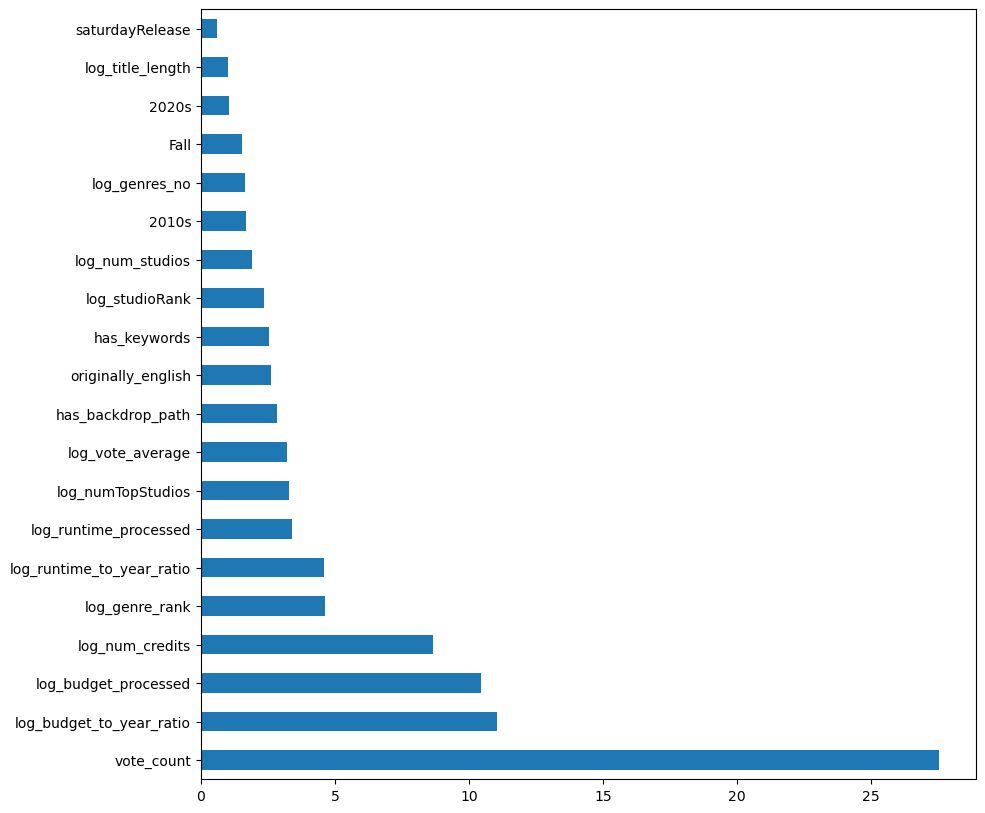

In [ ]:
feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=[10,10])

Once again, the names of the features that hold the most importance appear to be similar across the models. However, the top position in the list is rather surprising as the vote count unexpectedly ranked at the top. Considering the SHAP values might offer better insights into how the model arrived at its predictions.

In [ ]:
# explainer = shap.TreeExplainer(cb_best_model)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values, X_train)

The SHAP values show similarities with LightGBM, and the rankings are consistent with our feature_importances, with the vote count being the most influential feature in predicting revenue.

### GradientBoosting

Next, we will implement the GradientBoosting model. The Gradient Boosting model is a powerful algorithm for boosting that excels in handling complex datasets with different types of features. It automatically handles missing values, feature interactions, and categorical variables, making it well-suited for large and diverse datasets, such as this one. With its scalability and strong performance, Gradient Boosting allows us to extract valuable insights and patterns.

#### Baseline

In [ ]:
gb_base_model = GradientBoostingRegressor(random_state = 42)
gb_base_model.fit(X_train, y_train.values.ravel())

GradientBoostingRegressor(random_state=42)

In [ ]:
y_pred = gb_base_model.predict(X_test)

In [ ]:
print('GradientBoosting Baseline Model Metrics:')
metrics(y_pred, y_test.values)

GradientBoosting Baseline Model Metrics:
Mean Squared Error:  4.0621
Root Mean Squared Error:  2.0155
Mean Absolute Error:  1.4085
Test Set Accuracy (from Mean Absolute Percentage Error):84.505%


#### Grid Search Hyperparameter Tuning

In [ ]:
gb_model = GradientBoostingRegressor(random_state = 42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': [0.9, 1.0, 1.1],
    'max_depth': [2, 5, 10],
    'alpha': [.4, .6, .8, 1],
    'subsample': [0.9, 1.0]
}

gb_model, pred = algorithm_pipeline(X_train, X_test, y_train.values.ravel(), y_test.values, gb_model,
                                 param_grid, cv=5)

print(np.sqrt(-gb_model.best_score_))
print(gb_model.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
102 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Anaconda\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "d:\Anaconda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "d:\Anaconda\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_par

1.43443468350607
{'alpha': 0.4, 'max_depth': 5, 'max_features': 0.9, 'n_estimators': 100, 'subsample': 1.0}


In [ ]:
print('Base Model:')
base_accuracy = evaluate(gb_base_model, X_test, y_test.values)

Base Model:
Average Error: 1.4085
Accuracy = 84.505%


In [ ]:
print('Model after Tuning:')
gb_best_model = gb_model.best_estimator_
best_accuracy = evaluate(gb_best_model, X_test, y_test.values)

print('Improvement of {:0.3f}%.'.format( 100 * (best_accuracy - base_accuracy) / base_accuracy))

Model after Tuning:
Average Error: 1.3742
Accuracy = 84.861%
Improvement of 0.420%.


In [ ]:
y_pred = gb_best_model.predict(X_test)
print('GradientBoosting Model Best Metrics:')
metrics(y_pred, y_test.values)

GradientBoosting Model Best Metrics:
Mean Squared Error:  3.9729
Root Mean Squared Error:  1.9932
Mean Absolute Error:  1.3742
Test Set Accuracy (from Mean Absolute Percentage Error):84.861%


This model initially had the poorest baseline performance, and despite the most significant improvements through tuning so far, its accuracy still lags behind the previous models. Now, let's assess how the feature importances compare in this context.

#### Feature Importances

In [ ]:
feature_importances = gb_best_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

print("Feature ranking:")

for f in range(len(indices)):
    print("%d. %s (%f)" % (f + 1, X_train.columns[indices[f]], feature_importances[indices[f]]))

Feature ranking:
1. log_budget_to_year_ratio (0.464604)
2. vote_count (0.248405)
3. log_num_credits (0.042826)
4. log_runtime_to_year_ratio (0.040459)
5. log_genre_rank (0.026419)
6. log_runtime_processed (0.024562)
7. log_vote_average (0.014995)
8. log_studioRank (0.014685)
9. log_budget_processed (0.014378)
10. log_numTopStudios (0.014122)
11. log_genres_no (0.013789)
12. log_title_length (0.012777)
13. has_backdrop_path (0.010125)
14. has_keywords (0.009030)
15. originally_english (0.006456)
16. 2010s (0.005364)
17. log_num_studios (0.005265)
18. 2020s (0.004012)
19. Fall (0.003759)
20. has_poster_path (0.002587)
21. mondayRelease (0.002568)
22. 1970s (0.002200)
23. saturdayRelease (0.002186)
24. 1980s (0.001982)
25. tuesdayRelease (0.001544)
26. has_tagline (0.001137)
27. thursdayRelease (0.000963)
28. 2000s (0.000948)
29. Summer (0.000939)
30. 1930s (0.000910)
31. wednesdayRelease (0.000905)
32. Spring (0.000786)
33. log_numTopActors (0.000730)
34. 1990s (0.000704)
35. fridayRelea

<Axes: >

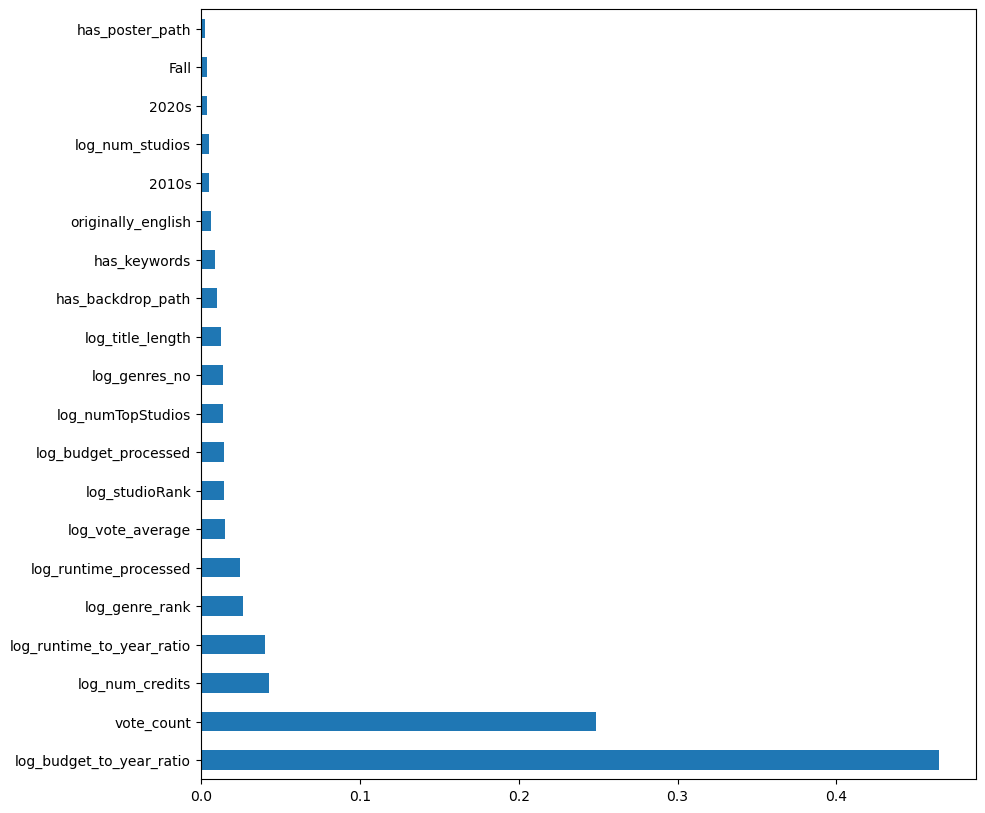

In [ ]:
feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=[10,10])

Once more, the most important features appear to be similar, with the budget to year ratio once again ranking at the top. Let's examine the SHAP values as they might provide a better indication of how the model generated its predictions.

In [ ]:
# explainer = shap.TreeExplainer(gb_best_model)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values, X_train)

Examining the SHAP values, we find consistency with the previous models, reaffirming the significance of the budget-to-year ratio as one of the strongest predictors, emphasizing its impact on the revenue predictions.

## Conclusion

### Results

Our best model ended up being the Extra Trees model, with metrics below.

In [ ]:
y_pred = et_base_model.predict(X_test)
print('Extra Trees Model Best Metrics:')
metrics(y_pred, y_test.values)

NameError: name 'et_base_model' is not defined

An accuracy greater than 81% was achieved by all of our models, and these results were highly pleasing. However, the average error will now be examined, despite of how high a percentage is seemingly attained.

In [ ]:
print('Average error of Extra Trees: ${:.2f}'.format(np.mean(abs(np.expm1(et_base_model.predict(X_test)) - np.expm1(y_test.values)))))

Average error of Extra Trees: $23987830.39


Despite our best efforts, significant discrepancies in revenue prediction were still observed in our top model when converting back from log-transformed values. Deviations of tens of millions of dollars, such as the average error obtained from the best model, are acceptable for blockbuster hits grossing over USD 600 million, but smaller movies earning USD 50 million or less will suffer greatly from our predictions. This highlights the challenge of accurately predicting success in the movie industry, where skewed data by the biggest hits makes precision difficult for smaller productions.

Nonetheless, the results are considered satisfactory, taking into account the complexities and unquantifiable factors at play, such as hype, marketing, and their effectiveness. Given the limitations of the dataset, it is believed that the performance was quite exceptional, and the outcomes are deemed satisfactory.

### Saving Mode

After training a machine learning model, saving it allows you to:

- **Reuse the model** without having to retrain it every time.
- **Deploy the model** in production environments (e.g., web applications, APIs).
- **Share the model** with teammates or across systems.
- **Version and archive models** for reproducibility and auditing.


In [ ]:
import os
import pickle

# Train the model
et_base_model.fit(X_train, y_train.values.ravel())
folder_name = 'prediction_model'
os.makedirs(folder_name, exist_ok=True)
filename = os.path.join(folder_name, 'et_best_model.pkl')
with open(filename, 'wb') as file:
    pickle.dump(et_best_model, file)

print(f"Model saved to: {filename}")


NameError: name 'et_base_model' is not defined

### Limitations

In working with the available data, several limitations were encountered. The training set used for modeling purposes was downloaded and cut off until July 10, 2023, since cutting off in a later date will change the result due to the dataset being updated daily. However, a notable challenge was the presence of numerous missing values across various variables. These gaps in information undermined the completeness of the dataset and introduced uncertainties into the analysis.

Among the most conspicuous deficiencies were observed in the budget and revenue variables. Both columns exhibited a considerable number of inconsistencies, particularly with an abundance of values recorded as zero or unrealistically low. This issue, although identified, likely extended beyond these variables, suggesting the possibility of additional undetected gaps and inconsistencies in the dataset. Consequently, the accuracy and reliability of the machine learning models' predictions were inherently limited by the quality of the input data. Enhancing the available data would have resulted in improved predictions, as the model's performance is inherently tied to the quality of its input.

Moreover, it should be acknowledged that the approach taken in modeling and fine-tuning the models may not have been optimal. Admittedly, with limited experience in the field, there may have been superior options and alternative methodologies for analysis. While diligent research was conducted to make informed decisions, it is plausible that more effective techniques and strategies exist, which could have yielded superior results given the specific characteristics of the data.

### Potential Improvements

In the realm of film revenue prediction and analysis, there are several areas offer opportunities for improvement and further exploration.

Firstly, refining the methodology for estimating missing budget values could enhance the accuracy of revenue predictions. While utilizing the average revenue of films produced by the same studios has shown promise, incorporating a regression model may yield more consistent results. By training a model on available data, it could better predict missing budget values and subsequently improve revenue estimations.

Secondly, underutilized columns such as title, overview, keywords, and poster path present avenues for deeper analysis. By examining popular keywords or sentiment analysis based on textual data, one could potentially identify correlations between revenue and certain aspects of a film's presentation. Extracting insights from these columns could provide valuable information for revenue prediction and audience engagement.

Although analyzing movie posters through neural networks is an intriguing prospect, it may be a labor-intensive endeavor outside the scope of the current project. However, exploring the potential of neural networks for revenue prediction in its entirety could be a worthwhile pursuit. While regression models have been employed due to data limitations and outliers, developing neural networks that are resilient to outliers and can handle the messy nature of the data might unlock more accurate revenue predictions.

Furthermore, although not investigated in this study, an interesting avenue for future inquiry could relate to the temporal dimension to trends in genre. It is possible that different genres attract varying interest among moviegoers through historical film epochs.

Additionally, understanding the algorithm behind the recommendation column could yield valuable insights. By exploring the relationship between the number of recommendations and revenue, one could uncover patterns that influence audience engagement and ultimately affect financial success. Analyzing the recommendation algorithm itself would provide a more comprehensive understanding of the factors influencing revenue beyond just the number of recommendations.